# Land Cover Classification from Sentinel-2 Imagery
## Random Forest versus Multi-Layer Perceptron

**Complete numbered workflow — run Step 1 through Step 27 in order.**

The workflow now includes Sentinel-2 download and interactive training-polygon creation before the original classification pipeline.


## Step 1 — User Settings
Set the data mode, Sentinel-2 tile/date/cloud criteria, workspace, and whether new training polygons will be created.


In [1]:
# ============================================================
# STEP 1 — PROJECT CONFIGURATION
# ============================================================

from pathlib import Path
import re


# ============================================================
# PROJECT DIRECTORIES
# ============================================================

PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
DOWNLOAD_DIR = PROJECT_DIR / "downloads"
EXTRACT_DIR = PROJECT_DIR / "extracted"
RESULTS_DIR = PROJECT_DIR / "Results"

for folder in [
    DATA_DIR,
    DOWNLOAD_DIR,
    EXTRACT_DIR,
    RESULTS_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# DATA SOURCE MODE
# ============================================================

DATA_SOURCE_MODE = "download"


# ============================================================
# INTERACTIVE LOCATION SELECTION
# ============================================================

while True:

    print("\n" + "=" * 65)
    print("SENTINEL-2 LOCATION SELECTION")
    print("=" * 65)

    print("\nHow would you like to search for Sentinel-2 data?")
    print("1 - Search by MGRS tile")
    print("2 - Search by area name")

    location_choice = input(
        "\nEnter your choice (1 or 2): "
    ).strip()


    # ========================================================
    # OPTION 1 — SEARCH BY MGRS TILE
    # ========================================================

    if location_choice == "1":

        entered_tile = input(
            "\nEnter MGRS tile "
            "(example: T32TNR): "
        ).strip().upper()


        # Expected notebook format:
        # T + 2 digits + 3 letters
        #
        # Example:
        # T32TNR

        tile_pattern = r"^T\d{2}[A-Z]{3}$"


        if re.fullmatch(
            tile_pattern,
            entered_tile
        ):

            LOCATION_MODE = "tile"

            MGRS_TILE = entered_tile

            AREA_NAME = None


            print(
                "\nSearch mode: MGRS tile"
            )

            print(
                "Selected tile:",
                MGRS_TILE
            )

            break


        else:

            print("\n" + "!" * 65)

            print(
                "INVALID MGRS TILE"
            )

            print(
                "Example of a valid tile: T32TNR"
            )

            print(
                "\nReturning to location selection..."
            )

            print("!" * 65)

            continue


    # ========================================================
    # OPTION 2 — SEARCH BY AREA NAME
    # ========================================================

    elif location_choice == "2":

        entered_area = input(
            "\nEnter area name "
            "(example: Milan, Italy): "
        ).strip()


        if len(entered_area) >= 2:

            LOCATION_MODE = "area"

            AREA_NAME = entered_area

            # Will be selected later in STEP 3
            MGRS_TILE = None


            print(
                "\nSearch mode: Area name"
            )

            print(
                "Selected area:",
                AREA_NAME
            )

            break


        else:

            print("\n" + "!" * 65)

            print(
                "INVALID AREA NAME"
            )

            print(
                "Please enter a valid area name."
            )

            print(
                "\nReturning to location selection..."
            )

            print("!" * 65)

            continue


    # ========================================================
    # INVALID LOCATION OPTION
    # ========================================================

    else:

        print("\n" + "!" * 65)

        print(
            "INVALID SEARCH OPTION"
        )

        print(
            "Please choose again."
        )

        print(
            "1 - Search by MGRS tile"
        )

        print(
            "2 - Search by area name"
        )

        print("!" * 65)

        continue


# ============================================================
# SENTINEL-2 DATE SETTINGS
# ============================================================

START_DATE = "2026-07-01"
END_DATE   = "2026-07-15"


# ============================================================
# INTERACTIVE CLOUD-COVER SELECTION
# ============================================================

print("\n" + "=" * 65)
print("SENTINEL-2 CLOUD-COVER SELECTION")
print("=" * 65)

print(
    "\nChoose the maximum acceptable cloud cover."
)

print(
    "For land-cover classification, "
    "a low value is recommended."
)

print(
    "Recommended range: 0-10%"
)


while True:

    cloud_input = input(
        "\nEnter maximum cloud cover percentage (0-100): "
    ).strip()


    try:

        MAX_CLOUD = float(
            cloud_input
        )


        if 0 <= MAX_CLOUD <= 100:

            print(
                "\nMaximum cloud cover selected:",
                MAX_CLOUD,
                "%"
            )

            break


        else:

            print("\n" + "!" * 65)

            print(
                "INVALID CLOUD-COVER VALUE"
            )

            print(
                "Please enter a value "
                "between 0 and 100."
            )

            print("!" * 65)


    except ValueError:

        print("\n" + "!" * 65)

        print(
            "INVALID CLOUD-COVER VALUE"
        )

        print(
            "Please enter a numerical value "
            "between 0 and 100."
        )

        print("!" * 65)


# ============================================================
# PRODUCT SELECTION
# ============================================================

# STEP 4 will display the available products
# and let the user select the required scene.

PRODUCT_INDEX = 0


# ============================================================
# TRAINING POLYGON MODE
# ============================================================

# True:
# create a new training dataset interactively.
#
# False:
# reuse an existing training_polygons.gpkg.

CREATE_NEW_TRAINING_POLYGONS = True


TRAINING_PATH = (
    PROJECT_DIR /
    "training_polygons.gpkg"
)


# ============================================================
# LAND-COVER CLASSES
# ============================================================

CLASS_MAP = {
    1: "Urban",
    2: "Vegetation",
    3: "Water",
    4: "Bare Soil",
}


# ============================================================
# REPRODUCIBILITY
# ============================================================

RANDOM_STATE = 42


# ============================================================
# FINAL CONFIGURATION SUMMARY
# ============================================================

print("\n" + "=" * 65)

print(
    "STEP 1 — PROJECT CONFIGURATION SUMMARY"
)

print(
    "=" * 65
)


print(
    "\nLocation mode:",
    LOCATION_MODE
)


if LOCATION_MODE == "tile":

    print(
        "MGRS tile:",
        MGRS_TILE
    )


else:

    print(
        "Area name:",
        AREA_NAME
    )

    print(
        "MGRS tile:",
        "To be selected interactively in STEP 3"
    )


print(
    "\nSentinel-2 date range:",
    START_DATE,
    "to",
    END_DATE
)


print(
    "Maximum cloud cover:",
    MAX_CLOUD,
    "%"
)


print(
    "\nData source mode:",
    DATA_SOURCE_MODE
)


print(
    "Create new training polygons:",
    CREATE_NEW_TRAINING_POLYGONS
)


print(
    "Training polygon file:",
    TRAINING_PATH
)


print(
    "Project directory:",
    PROJECT_DIR
)


print(
    "\nSTEP 1 completed successfully."
)


SENTINEL-2 LOCATION SELECTION

How would you like to search for Sentinel-2 data?
1 - Search by MGRS tile
2 - Search by area name



Enter your choice (1 or 2):  2

Enter area name (example: Milan, Italy):  Milan, Italy



Search mode: Area name
Selected area: Milan, Italy

SENTINEL-2 CLOUD-COVER SELECTION

Choose the maximum acceptable cloud cover.
For land-cover classification, a low value is recommended.
Recommended range: 0-10%



Enter maximum cloud cover percentage (0-100):  3



Maximum cloud cover selected: 3.0 %

STEP 1 — PROJECT CONFIGURATION SUMMARY

Location mode: area
Area name: Milan, Italy
MGRS tile: To be selected interactively in STEP 3

Sentinel-2 date range: 2026-07-01 to 2026-07-15
Maximum cloud cover: 3.0 %

Data source mode: download
Create new training polygons: True
Training polygon file: C:\Users\Hp\Desktop\submissiongeo_final\training_polygons.gpkg
Project directory: C:\Users\Hp\Desktop\submissiongeo_final

STEP 1 completed successfully.


## Step 2 — Sentinel-2 Acquisition Utilities
Load the functions used to search Copernicus Data Space, authenticate, download products, extract files, discover bands, and resample the required inputs.


In [2]:
# ============================================================
# STEP 2 — SENTINEL-2 ACQUISITION UTILITIES
# Correct cloud-cover filtering
# ============================================================

import os
import re
import time
import json
import zipfile
import shutil
import requests
import pandas as pd
import numpy as np
import rasterio

from pathlib import Path

from rasterio.warp import reproject
from rasterio.enums import Resampling


# ============================================================
# COPERNICUS DATA SPACE SETTINGS
# ============================================================

CDSE_CATALOG_URL = (
    "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
)

CDSE_TOKEN_URL = (
    "https://identity.dataspace.copernicus.eu/"
    "auth/realms/CDSE/protocol/openid-connect/token"
)

CDSE_DOWNLOAD_URL = (
    "https://download.dataspace.copernicus.eu/odata/v1/Products"
)


# ============================================================
# NORMALIZE MGRS TILE
# ============================================================

def normalize_tile_for_search(tile):

    tile = str(tile).strip().upper()

    if (
        len(tile) == 6
        and tile.startswith("T")
    ):

        tile = tile[1:]

    return tile


# ============================================================
# SEARCH SENTINEL-2 LEVEL-2A
# ============================================================

def search_sentinel2_l2a(
    tile,
    start_date,
    end_date,
    max_cloud,
    top=100
):

    """
    Search Sentinel-2 Level-2A products.

    Cloud cover is filtered directly in the Copernicus
    OData query using the cloudCover product attribute.
    """

    tile_clean = normalize_tile_for_search(
        tile
    )

    max_cloud = float(
        max_cloud
    )


    print(
        "Searching tile:",
        tile_clean
    )

    print(
        "Date range:",
        start_date,
        "to",
        end_date
    )

    print(
        "Maximum cloud cover:",
        max_cloud,
        "%"
    )


    # ========================================================
    # ODATA FILTER
    # ========================================================

    filter_query = (

        "Collection/Name eq 'SENTINEL-2'"

        " and "

        "contains(Name,'MSIL2A')"

        " and "

        f"contains(Name,'T{tile_clean}')"

        " and "

        f"ContentDate/Start ge "
        f"{start_date}T00:00:00.000Z"

        " and "

        f"ContentDate/Start le "
        f"{end_date}T23:59:59.999Z"

        " and "

        "Attributes/"
        "OData.CSC.DoubleAttribute/any("
        "att: "
        "att/Name eq 'cloudCover' "
        "and "
        f"att/OData.CSC.DoubleAttribute/Value le {max_cloud}"
        ")"
    )


    params = {

        "$filter":
            filter_query,

        "$top":
            top,

        "$orderby":
            "ContentDate/Start asc",

        # Request attributes so cloudCover can also
        # be displayed in the product table.
        "$expand":
            "Attributes",
    }


    # ========================================================
    # SEND SEARCH REQUEST
    # ========================================================

    response = requests.get(

        CDSE_CATALOG_URL,

        params=params,

        timeout=60
    )


    try:

        response.raise_for_status()

    except requests.HTTPError:

        print(
            "\nCopernicus search request failed."
        )

        print(
            "HTTP status:",
            response.status_code
        )

        print(
            "Response:"
        )

        print(
            response.text[:1000]
        )

        raise


    products = (
        response
        .json()
        .get(
            "value",
            []
        )
    )


    # ========================================================
    # NO PRODUCTS FOUND
    # ========================================================

    if not products:

        return pd.DataFrame(
            columns=[
                "Id",
                "Name",
                "Acquisition",
                "CloudCover",
            ]
        )


    # ========================================================
    # BUILD RESULT TABLE
    # ========================================================

    records = []


    for product in products:

        product_id = product.get(
            "Id"
        )

        product_name = product.get(
            "Name"
        )

        acquisition = (
            product
            .get(
                "ContentDate",
                {}
            )
            .get(
                "Start"
            )
        )


        cloud_cover = np.nan


        attributes = product.get(
            "Attributes",
            []
        )


        # ====================================================
        # EXTRACT CLOUD COVER ATTRIBUTE
        # ====================================================

        for attribute in attributes:

            attribute_name = str(
                attribute.get(
                    "Name",
                    ""
                )
            ).strip()


            if (
                attribute_name.lower()
                ==
                "cloudcover"
            ):

                # Copernicus attributes can expose the
                # numerical value in slightly different
                # structures depending on the response.

                candidate_values = [

                    attribute.get(
                        "Value"
                    ),

                    attribute.get(
                        "value"
                    ),

                ]


                for candidate in candidate_values:

                    if candidate is None:
                        continue


                    try:

                        cloud_cover = float(
                            candidate
                        )

                        break

                    except (
                        TypeError,
                        ValueError
                    ):

                        pass


                break


        records.append(
            {

                "Id":
                    product_id,

                "Name":
                    product_name,

                "Acquisition":
                    acquisition,

                "CloudCover":
                    cloud_cover,

            }
        )


    result = pd.DataFrame(
        records
    )


    # ========================================================
    # SAFETY FILTER
    # ========================================================

    # The OData query already filtered cloud cover.
    # This second filter is only a verification layer.

    if (
        "CloudCover" in result.columns
        and
        result[
            "CloudCover"
        ].notna().any()
    ):

        result = result[
            result[
                "CloudCover"
            ]
            <= max_cloud
        ].copy()


    # ========================================================
    # EMPTY AFTER VERIFICATION
    # ========================================================

    if len(result) == 0:

        return pd.DataFrame(
            columns=[
                "Id",
                "Name",
                "Acquisition",
                "CloudCover",
            ]
        )


    # ========================================================
    # SORT LOWEST CLOUD FIRST
    # ========================================================

    if result[
        "CloudCover"
    ].notna().any():

        result = (

            result

            .sort_values(

                by=[
                    "CloudCover",
                    "Acquisition"
                ],

                ascending=[
                    True,
                    True
                ]
            )

            .reset_index(
                drop=True
            )

        )


    else:

        # This should normally not happen anymore,
        # but keep a safe fallback.

        result = (

            result

            .sort_values(
                by="Acquisition"
            )

            .reset_index(
                drop=True
            )

        )


    return result


# ============================================================
# GET COPERNICUS ACCESS TOKEN
# ============================================================

def get_cdse_token(
    username,
    password
):

    data = {

        "client_id":
            "cdse-public",

        "username":
            username,

        "password":
            password,

        "grant_type":
            "password",
    }


    response = requests.post(

        CDSE_TOKEN_URL,

        data=data,

        timeout=60
    )


    if response.status_code != 200:

        raise RuntimeError(
            "CDSE authentication failed. "
            "Check username/email and password."
        )


    token = (
        response
        .json()
        .get(
            "access_token"
        )
    )


    if not token:

        raise RuntimeError(
            "CDSE did not return an access token."
        )


    return token


# ============================================================
# DOWNLOAD SENTINEL-2 PRODUCT
# ============================================================

def download_cdse_product(
    product_id,
    product_name,
    token,
    download_dir
):

    download_dir = Path(
        download_dir
    )

    download_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    safe_name = str(
        product_name
    ).replace(
        ".SAFE",
        ""
    )


    output_zip = (
        download_dir
        /
        f"{safe_name}.zip"
    )


    # ========================================================
    # REUSE EXISTING DOWNLOAD
    # ========================================================

    if (
        output_zip.exists()
        and
        output_zip.stat().st_size > 0
    ):

        print(
            "\nExisting product download found."
        )

        print(
            "Using:",
            output_zip
        )

        return output_zip


    url = (
        f"{CDSE_DOWNLOAD_URL}"
        f"({product_id})/$value"
    )


    headers = {

        "Authorization":
            f"Bearer {token}"
    }


    print(
        "\nDownloading:"
    )

    print(
        product_name
    )


    with requests.get(

        url,

        headers=headers,

        stream=True,

        timeout=120

    ) as response:


        response.raise_for_status()


        total_size = int(
            response.headers.get(
                "content-length",
                0
            )
        )


        downloaded = 0


        with open(
            output_zip,
            "wb"
        ) as file_out:


            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):

                if not chunk:
                    continue


                file_out.write(
                    chunk
                )


                downloaded += len(
                    chunk
                )


                if total_size > 0:

                    percent = (

                        downloaded
                        /
                        total_size
                        *
                        100

                    )


                    print(

                        f"\rDownloading: "
                        f"{percent:5.1f}%",

                        end=""
                    )


    print(
        "\nDownload completed:"
    )

    print(
        output_zip
    )


    return output_zip


# ============================================================
# EXTRACT SENTINEL-2 PRODUCT
# ============================================================

def extract_product(
    product_zip,
    extract_dir
):

    product_zip = Path(
        product_zip
    )

    extract_dir = Path(
        extract_dir
    )


    extract_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    expected_safe = (

        product_zip.stem
        +
        ".SAFE"

    )


    existing = list(
        extract_dir.rglob(
            expected_safe
        )
    )


    if existing:

        print(
            "\nExisting extracted product found."
        )

        print(
            existing[0]
        )

        return existing[0]


    print(
        "\nExtracting product..."
    )


    with zipfile.ZipFile(
        product_zip,
        "r"
    ) as archive:

        archive.extractall(
            extract_dir
        )


    safe_dirs = list(
        extract_dir.rglob(
            "*.SAFE"
        )
    )


    if not safe_dirs:

        raise RuntimeError(
            "Extraction completed, but no .SAFE directory "
            "was found."
        )


    safe_root = max(

        safe_dirs,

        key=lambda p:
            p.stat().st_mtime

    )


    print(
        "Extracted product:"
    )

    print(
        safe_root
    )


    return safe_root


# ============================================================
# FIND SENTINEL-2 BAND
# ============================================================

def find_band_file(
    safe_root,
    band,
    resolution
):

    safe_root = Path(
        safe_root
    )


    patterns = [

        f"*_{band}_{resolution}.jp2",

        f"*_{band}_{resolution}.tif",

    ]


    for pattern in patterns:

        matches = list(
            safe_root.rglob(
                pattern
            )
        )


        if matches:

            return matches[0]


    raise FileNotFoundError(

        f"Could not find {band} at "
        f"{resolution} inside:\n"
        f"{safe_root}"
    )


# ============================================================
# COPY RASTER TO GEOTIFF
# ============================================================

def copy_raster_to_tif(
    src_path,
    out_path
):

    out_path = Path(
        out_path
    )


    if out_path.exists():

        print(
            "Existing prepared band:",
            out_path.name
        )

        return out_path


    with rasterio.open(
        src_path
    ) as src:

        profile = (
            src.profile.copy()
        )


        profile.update(

            driver="GTiff",

            compress="lzw"
        )


        data = src.read(
            1
        )


        with rasterio.open(

            out_path,

            "w",

            **profile

        ) as dst:

            dst.write(
                data,
                1
            )


    return out_path


# ============================================================
# RESAMPLE BAND TO 10-M REFERENCE
# ============================================================

def resample_to_reference(
    src_path,
    ref_path,
    out_path
):

    out_path = Path(
        out_path
    )


    if out_path.exists():

        print(
            "Existing resampled band:",
            out_path.name
        )

        return out_path


    with rasterio.open(
        src_path
    ) as src, rasterio.open(
        ref_path
    ) as ref:


        profile = (
            ref.profile.copy()
        )


        profile.update(

            driver="GTiff",

            dtype="float32",

            count=1,

            compress="lzw"
        )


        destination = np.empty(

            (
                ref.height,
                ref.width
            ),

            dtype=np.float32
        )


        reproject(

            source=rasterio.band(
                src,
                1
            ),

            destination=destination,

            src_transform=src.transform,

            src_crs=src.crs,

            dst_transform=ref.transform,

            dst_crs=ref.crs,

            resampling=Resampling.bilinear,

        )


        with rasterio.open(

            out_path,

            "w",

            **profile

        ) as dst:

            dst.write(
                destination,
                1
            )


    return out_path


# ============================================================
# PREPARE REQUIRED SENTINEL-2 BANDS
# ============================================================

def prepare_required_bands(
    safe_root,
    data_dir
):

    data_dir = Path(
        data_dir
    )


    data_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    print(
        "\nLocating Sentinel-2 bands..."
    )


    # ========================================================
    # 10-M BANDS
    # ========================================================

    b02_src = find_band_file(
        safe_root,
        "B02",
        "10m"
    )

    b03_src = find_band_file(
        safe_root,
        "B03",
        "10m"
    )

    b04_src = find_band_file(
        safe_root,
        "B04",
        "10m"
    )

    b08_src = find_band_file(
        safe_root,
        "B08",
        "10m"
    )


    # ========================================================
    # 20-M BANDS
    # ========================================================

    b11_src = find_band_file(
        safe_root,
        "B11",
        "20m"
    )

    b12_src = find_band_file(
        safe_root,
        "B12",
        "20m"
    )


    # ========================================================
    # OUTPUT PATHS
    # ========================================================

    b02_out = (
        data_dir /
        "B02_10m.tif"
    )

    b03_out = (
        data_dir /
        "B03_10m.tif"
    )

    b04_out = (
        data_dir /
        "B04_10m.tif"
    )

    b08_out = (
        data_dir /
        "B08_10m.tif"
    )

    b11_out = (
        data_dir /
        "B11_10m.tif"
    )

    b12_out = (
        data_dir /
        "B12_10m.tif"
    )


    # ========================================================
    # COPY 10-M BANDS
    # ========================================================

    copy_raster_to_tif(
        b02_src,
        b02_out
    )

    copy_raster_to_tif(
        b03_src,
        b03_out
    )

    copy_raster_to_tif(
        b04_src,
        b04_out
    )

    copy_raster_to_tif(
        b08_src,
        b08_out
    )


    # ========================================================
    # RESAMPLE SWIR BANDS TO 10 M
    # ========================================================

    print(
        "\nPreparing B11 at 10 m..."
    )


    resample_to_reference(
        b11_src,
        b02_out,
        b11_out
    )


    print(
        "Preparing B12 at 10 m..."
    )


    resample_to_reference(
        b12_src,
        b02_out,
        b12_out
    )


    prepared = {

        "B02":
            b02_out,

        "B03":
            b03_out,

        "B04":
            b04_out,

        "B08":
            b08_out,

        "B11":
            b11_out,

        "B12":
            b12_out,

    }


    print(
        "\nRequired Sentinel-2 bands prepared successfully."
    )


    return prepared


# ============================================================
# DISCOVER PREPARED BANDS
# ============================================================

def discover_prepared_bands(
    data_dir
):

    data_dir = Path(
        data_dir
    )


    expected = {

        "B02":
            data_dir /
            "B02_10m.tif",

        "B03":
            data_dir /
            "B03_10m.tif",

        "B04":
            data_dir /
            "B04_10m.tif",

        "B08":
            data_dir /
            "B08_10m.tif",

        "B11":
            data_dir /
            "B11_10m.tif",

        "B12":
            data_dir /
            "B12_10m.tif",

    }


    missing = [

        str(path)

        for path
        in expected.values()

        if not path.exists()

    ]


    if missing:

        raise FileNotFoundError(

            "Prepared Sentinel-2 bands are missing:\n"

            +

            "\n".join(
                missing
            )
        )


    return expected


# ============================================================
# STEP 2 COMPLETE
# ============================================================

print(
    "STEP 2 — Sentinel-2 acquisition utilities "
    "loaded successfully."
)

STEP 2 — Sentinel-2 acquisition utilities loaded successfully.


## Step 3 — Area / Sentinel-2 Tile Selection
Choose the MGRS tile directly or search by area name before starting the Sentinel-2 product search.


In [3]:
# ============================================================
# STEP 3 — AREA / SENTINEL-2 TILE SELECTION
# ============================================================

import sys
import subprocess
import importlib.util
import numpy as np


# ============================================================
# INSTALL REQUIRED PACKAGES IF MISSING
# ============================================================

required_packages = {
    "geopy": "geopy",
    "mgrs": "mgrs",
    "ipyleaflet": "ipyleaflet",
    "ipywidgets": "ipywidgets",
    "shapely": "shapely",
}


for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:

        print(
            f"Installing missing package: {package_name}"
        )

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                package_name
            ]
        )


# ============================================================
# IMPORTS
# ============================================================

from geopy.geocoders import Nominatim
from geopy.exc import (
    GeocoderTimedOut,
    GeocoderServiceError
)

import mgrs

from shapely.geometry import MultiPoint

import ipywidgets as widgets

from ipyleaflet import (
    Map,
    Polygon,
    Marker,
    WidgetControl,
    LayersControl,
    basemaps,
    basemap_to_tiles,
)

from IPython.display import display


# ============================================================
# MGRS CONVERTER
# ============================================================

mgrs_converter = mgrs.MGRS()


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_mgrs_tile(tile):
    """
    Convert notebook tile name to standard MGRS tile.

    T32TNR -> 32TNR
    32TNR  -> 32TNR
    """

    tile = str(tile).strip().upper()

    if (
        len(tile) == 6
        and tile.startswith("T")
    ):
        tile = tile[1:]

    return tile


def notebook_tile_name(tile):
    """
    Convert standard MGRS tile to notebook format.

    32TNR -> T32TNR
    """

    return "T" + normalize_mgrs_tile(tile)


def tile_from_latlon(lat, lon):
    """
    Return the 100-km MGRS grid tile containing a point.
    """

    tile = mgrs_converter.toMGRS(
        lat,
        lon,
        MGRSPrecision=0
    )

    if isinstance(tile, bytes):
        tile = tile.decode("utf-8")

    return str(tile).upper()


# ============================================================
# CASE 1 — DIRECT TILE MODE
# ============================================================

if LOCATION_MODE == "tile":

    MGRS_TILE = notebook_tile_name(
        MGRS_TILE
    )

    print("=" * 65)
    print("STEP 3 — DIRECT TILE MODE")
    print("=" * 65)

    print(
        "\nSelected Sentinel-2 tile:",
        MGRS_TILE
    )

    print(
        "\nArea map skipped because "
        "the user entered the MGRS tile directly."
    )

    print(
        "\nSTEP 3 completed successfully."
    )


# ============================================================
# CASE 2 — SEARCH BY AREA NAME
# ============================================================

elif LOCATION_MODE == "area":

    print("=" * 65)
    print("STEP 3 — AREA / SENTINEL-2 TILE SELECTION")
    print("=" * 65)

    print(
        "\nSearching for area:",
        AREA_NAME
    )


    # ========================================================
    # GEOCODE AREA
    # ========================================================

    geolocator = Nominatim(
        user_agent="tarig_landcover_project"
    )


    try:

        location = geolocator.geocode(
            AREA_NAME,
            exactly_one=True,
            timeout=15
        )

    except (
        GeocoderTimedOut,
        GeocoderServiceError
    ) as error:

        raise RuntimeError(
            "The location service could not be reached. "
            "Check the internet connection and run Step 3 again."
        ) from error


    if location is None:

        print(
            f"\nArea not found: {AREA_NAME}"
        )

        print(
            "Run Step 1 again and choose either:"
        )

        print(
            "1 - Search by MGRS tile"
        )

        print(
            "2 - Search by another area name"
        )

        raise ValueError(
            "Area-name search returned no location."
        )


    area_lat = float(
        location.latitude
    )

    area_lon = float(
        location.longitude
    )


    print(
        "\nArea found:"
    )

    print(
        location.address
    )

    print(
        "Latitude:",
        area_lat
    )

    print(
        "Longitude:",
        area_lon
    )


    # ========================================================
    # IDENTIFY CENTRAL TILE
    # ========================================================

    central_tile = tile_from_latlon(
        area_lat,
        area_lon
    )


    print(
        "\nTile containing the area centre:",
        notebook_tile_name(central_tile)
    )


    # ========================================================
    # SAMPLE SURROUNDING AREA
    #
    # We sample many geographic points around the requested
    # location. Each point is assigned to its real MGRS tile.
    #
    # The point groups are then used to approximate the
    # boundaries of the surrounding 100-km tiles.
    # ========================================================

    LAT_RADIUS = 1.15
    LON_RADIUS = 1.50

    GRID_SIZE = 61


    sampled_lats = np.linspace(
        area_lat - LAT_RADIUS,
        area_lat + LAT_RADIUS,
        GRID_SIZE
    )

    sampled_lons = np.linspace(
        area_lon - LON_RADIUS,
        area_lon + LON_RADIUS,
        GRID_SIZE
    )


    tile_points = {}


    print(
        "\nIdentifying surrounding Sentinel-2 tiles..."
    )


    for lat in sampled_lats:

        for lon in sampled_lons:

            try:

                tile = tile_from_latlon(
                    float(lat),
                    float(lon)
                )

                if tile not in tile_points:

                    tile_points[tile] = []

                tile_points[tile].append(
                    (
                        float(lon),
                        float(lat)
                    )
                )

            except Exception:

                pass


    # Ensure centre tile exists
    if central_tile not in tile_points:

        tile_points[
            central_tile
        ] = [
            (
                area_lon,
                area_lat
            )
        ]


    # ========================================================
    # CREATE APPROXIMATE TILE POLYGONS
    # ========================================================

    tile_boundaries = {}


    for tile, points in tile_points.items():

        if len(points) < 3:

            continue


        hull = MultiPoint(
            points
        ).convex_hull


        if hull.geom_type != "Polygon":

            continue


        coordinates = [

            [lat, lon]

            for lon, lat
            in hull.exterior.coords

        ]


        tile_boundaries[
            tile
        ] = coordinates


    candidate_tiles = sorted(
        tile_boundaries.keys()
    )


    # ========================================================
    # KEEP CENTRAL AND NEARBY TILES
    # ========================================================

    # Find tiles whose sampled polygons are reasonably close
    # to the selected location.

    selected_candidates = []


    for tile in candidate_tiles:

        coords = tile_boundaries[
            tile
        ]

        lats = [
            point[0]
            for point in coords
        ]

        lons = [
            point[1]
            for point in coords
        ]


        tile_center_lat = (
            min(lats) +
            max(lats)
        ) / 2


        tile_center_lon = (
            min(lons) +
            max(lons)
        ) / 2


        distance_score = (
            abs(
                tile_center_lat -
                area_lat
            )
            +
            abs(
                tile_center_lon -
                area_lon
            )
        )


        selected_candidates.append(
            (
                distance_score,
                tile
            )
        )


    selected_candidates.sort(
        key=lambda x: x[0]
    )


    # Show a manageable number around the area
    candidate_tiles = [

        tile

        for _, tile
        in selected_candidates[:9]

    ]


    # Always retain central tile
    if central_tile not in candidate_tiles:

        candidate_tiles.insert(
            0,
            central_tile
        )


    print(
        "\nCandidate Sentinel-2 tiles:"
    )


    for tile in candidate_tiles:

        marker = (
            "  <-- AREA CENTRE"
            if tile == central_tile
            else ""
        )

        print(
            notebook_tile_name(tile),
            marker
        )


    # ========================================================
    # CREATE OPENSTREETMAP
    # ========================================================

    tile_map = Map(
        center=(
            area_lat,
            area_lon
        ),
        zoom=8,
        scroll_wheel_zoom=True
    )


    osm_layer = basemap_to_tiles(
        basemaps.OpenStreetMap.Mapnik
    )

    osm_layer.name = (
        "OpenStreetMap"
    )

    tile_map.add(
        osm_layer
    )


    # ========================================================
    # AREA MARKER
    # ========================================================

    area_marker = Marker(
        location=(
            area_lat,
            area_lon
        ),
        draggable=False
    )


    area_marker.popup = widgets.HTML(
        value=(
            f"<b>{AREA_NAME}</b><br>"
            f"{location.address}"
        )
    )


    tile_map.add(
        area_marker
    )


    # ========================================================
    # DRAW TILE BOUNDARIES
    # ========================================================

    for tile in candidate_tiles:

        if tile not in tile_boundaries:

            continue


        is_central = (
            tile == central_tile
        )


        polygon = Polygon(

            locations=
                tile_boundaries[tile],

            weight=
                4 if is_central else 2,

            fill_opacity=
                0.08 if is_central else 0.03,

            name=
                notebook_tile_name(tile)
        )


        polygon.popup = widgets.HTML(

            value=(
                "<b>Sentinel-2 tile:</b> "
                f"{notebook_tile_name(tile)}"
            )

        )


        tile_map.add(
            polygon
        )


    # ========================================================
    # TILE SELECTION CONTROL
    # ========================================================

    tile_options = [

        notebook_tile_name(tile)

        for tile in candidate_tiles

    ]


    default_tile = (
        notebook_tile_name(
            central_tile
        )
    )


    tile_dropdown = widgets.Dropdown(

        options=tile_options,

        value=default_tile,

        description="Tile:",

        style={
            "description_width": "initial"
        }
    )


    select_button = widgets.Button(

        description=
            "Use selected tile",

        button_style=
            "success",

        icon=
            "check"
    )


    status = widgets.HTML(

        value=(
            "<b>Area centre tile: "
            f"{default_tile}</b><br>"
            "Inspect the map and select the tile "
            "you want to classify."
        )
    )


    # ========================================================
    # SAVE SELECTION
    # ========================================================

    def save_selected_tile(_):

        global MGRS_TILE

        MGRS_TILE = (
            tile_dropdown.value
        )


        status.value = (

            "<b style='color:green;'>"
            "Selected tile: "
            f"{MGRS_TILE}"
            "</b><br>"
            "Tile selection saved successfully."

        )


        print(
            "\nSelected Sentinel-2 tile:",
            MGRS_TILE
        )

        print(
            "STEP 3 completed successfully."
        )


    select_button.on_click(
        save_selected_tile
    )


    # ========================================================
    # MAP CONTROL BOX
    # ========================================================

    control_box = widgets.VBox(
        [

            widgets.HTML(
                value=(
                    "<b>Sentinel-2 Tile Selection</b>"
                )
            ),

            tile_dropdown,

            select_button,

            status,

        ]
    )


    tile_map.add(

        WidgetControl(
            widget=control_box,
            position="topright"
        )

    )


    tile_map.add(

        LayersControl(
            position="bottomright"
        )

    )


    # ========================================================
    # DISPLAY MAP
    # ========================================================

    print(
        "\nOpenStreetMap tile-selection map ready."
    )

    print(
        "1. Locate the area marker."
    )

    print(
        "2. Inspect the displayed Sentinel-2 tiles."
    )

    print(
        "3. Choose the required tile from the dropdown."
    )

    print(
        "4. Click 'Use selected tile'."
    )


    display(
        tile_map
    )


# ============================================================
# INVALID MODE
# ============================================================

else:

    raise ValueError(
        "LOCATION_MODE must be 'tile' or 'area'. "
        "Run Step 1 again."
    )

STEP 3 — AREA / SENTINEL-2 TILE SELECTION

Searching for area: Milan, Italy

Area found:
Milano, Rodano, Milano, Lombardia, Italia
Latitude: 45.4641943
Longitude: 9.1896346

Tile containing the area centre: T32TNR

Identifying surrounding Sentinel-2 tiles...

Candidate Sentinel-2 tiles:
T32TNR   <-- AREA CENTRE
T32TMR 
T32TNQ 
T32TNS 
T32TPR 
T32TMQ 
T32TMS 
T32TPQ 
T32TPS 

OpenStreetMap tile-selection map ready.
1. Locate the area marker.
2. Inspect the displayed Sentinel-2 tiles.
3. Choose the required tile from the dropdown.
4. Click 'Use selected tile'.


Map(center=[45.4641943, 9.1896346], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

## Step 4 — Search / Select / Download / Prepare Sentinel-2
Search Level-2A products using the selected cloud threshold, display cloud cover without the pandas index, select a product, authenticate to Copernicus with retry on incorrect credentials, and prepare the six required bands.


In [4]:
# ============================================================
# STEP 4 — SEARCH / SELECT / DOWNLOAD / PREPARE SENTINEL-2
# ============================================================

import getpass
import pandas as pd


# ============================================================
# CHECK DATA SOURCE MODE
# ============================================================

if DATA_SOURCE_MODE.lower() == "download":

    # ========================================================
    # CHECK THAT A TILE WAS SELECTED
    # ========================================================

    if MGRS_TILE is None:

        raise RuntimeError(
            "No Sentinel-2 tile has been selected.\n"
            "Run STEP 1 and STEP 3 before running STEP 4."
        )


    print("=" * 70)
    print("STEP 4 — SENTINEL-2 SEARCH / DOWNLOAD")
    print("=" * 70)

    print(
        "\nSelected MGRS tile:",
        MGRS_TILE
    )

    print(
        "Date range:",
        START_DATE,
        "to",
        END_DATE
    )

    print(
        "Maximum cloud cover:",
        MAX_CLOUD,
        "%"
    )


    # ========================================================
    # SEARCH LOOP
    # ========================================================

    current_max_cloud = float(
        MAX_CLOUD
    )


    while True:

        print(
            "\nSearching Sentinel-2 Level-2A products..."
        )

        print(
            f"Cloud-cover threshold: "
            f"{current_max_cloud:.1f}%"
        )


        search_results = search_sentinel2_l2a(

            tile=MGRS_TILE,

            start_date=START_DATE,

            end_date=END_DATE,

            max_cloud=current_max_cloud,

        )


        # ====================================================
        # PRODUCTS FOUND
        # ====================================================

        if len(search_results) > 0:

            print(
                f"\nFound {len(search_results)} "
                "Sentinel-2 product(s)."
            )

            break


        # ====================================================
        # NO PRODUCTS FOUND
        # ====================================================

        print("\n" + "!" * 70)

        print(
            "NO SENTINEL-2 PRODUCTS FOUND"
        )

        print("!" * 70)

        print(
            "\nNo Level-2A scenes were found for:"
        )

        print(
            "Tile:",
            MGRS_TILE
        )

        print(
            "Date range:",
            START_DATE,
            "to",
            END_DATE
        )

        print(
            "Maximum cloud cover:",
            current_max_cloud,
            "%"
        )


        print(
            "\nWhat would you like to do?"
        )

        print(
            "1 - Increase the cloud-cover threshold"
        )

        print(
            "2 - Return and choose another tile or area"
        )

        print(
            "3 - Stop the search"
        )


        no_result_choice = input(
            "\nEnter your choice (1, 2 or 3): "
        ).strip()


        # ====================================================
        # OPTION 1 — INCREASE CLOUD THRESHOLD
        # ====================================================

        if no_result_choice == "1":

            while True:

                new_cloud = input(
                    "\nEnter a new maximum cloud cover "
                    "(0-100): "
                ).strip()


                try:

                    new_cloud = float(
                        new_cloud
                    )


                    if 0 <= new_cloud <= 100:

                        current_max_cloud = (
                            new_cloud
                        )

                        MAX_CLOUD = (
                            new_cloud
                        )

                        print(
                            "\nCloud-cover threshold updated to:",
                            MAX_CLOUD,
                            "%"
                        )

                        break


                    else:

                        print(
                            "\nPlease enter a value "
                            "between 0 and 100."
                        )


                except ValueError:

                    print(
                        "\nInvalid value."
                    )

                    print(
                        "Please enter a numerical "
                        "cloud-cover percentage."
                    )


            continue


        # ====================================================
        # OPTION 2 — RETURN TO LOCATION SELECTION
        # ====================================================

        elif no_result_choice == "2":

            print("\n" + "=" * 70)

            print(
                "RETURN TO LOCATION SELECTION"
            )

            print("=" * 70)

            print(
                "\nRun STEP 1 again."
            )

            print(
                "Choose:"
            )

            print(
                "1 - Search by MGRS tile"
            )

            print(
                "2 - Search by area name"
            )

            print(
                "\nThen run STEP 3 and STEP 4 again."
            )

            raise RuntimeError(
                "Sentinel-2 search stopped so that "
                "a new tile or area can be selected."
            )


        # ====================================================
        # OPTION 3 — STOP
        # ====================================================

        elif no_result_choice == "3":

            raise RuntimeError(
                "Sentinel-2 search stopped by the user."
            )


        # ====================================================
        # INVALID OPTION
        # ====================================================

        else:

            print(
                "\nInvalid choice."
            )

            print(
                "Please enter 1, 2 or 3."
            )

            continue


    # ========================================================
    # IDENTIFY CLOUD-COVER COLUMN
    # ========================================================

    possible_cloud_columns = [

        "CloudCover",

        "Cloud_Cover",

        "Cloud Cover",

        "cloudCover",

        "cloud_cover",

        "CloudCoverPercentage",

    ]


    cloud_column = None


    for column in possible_cloud_columns:

        if column in search_results.columns:

            cloud_column = column

            break


    # ========================================================
    # SORT PRODUCTS
    # ========================================================

    if cloud_column is not None:

        search_results = (

            search_results

            .sort_values(

                by=[
                    cloud_column,
                    "Acquisition"
                ],

                ascending=[
                    True,
                    True
                ]

            )

            .reset_index(
                drop=True
            )

        )


    else:

        search_results = (

            search_results

            .sort_values(
                by="Acquisition"
            )

            .reset_index(
                drop=True
            )

        )


    # ========================================================
    # CREATE USER-FRIENDLY PRODUCT TABLE
    # ========================================================

    product_table = pd.DataFrame()


    product_table[
        "Selection"
    ] = range(
        1,
        len(search_results) + 1
    )


    product_table[
        "Acquisition"
    ] = search_results[
        "Acquisition"
    ]


    if cloud_column is not None:

        product_table["Cloud Cover (%)"] = search_results[cloud_column].round(2)


    product_table[
        "Product Name"
    ] = search_results[
        "Name"
    ]


    print("\n" + "=" * 70)

    print(
        "AVAILABLE SENTINEL-2 PRODUCTS"
    )

    print("=" * 70)


    display(product_table.style.hide(axis="index"))


    if cloud_column is not None:

        print(
            "\nProducts are ordered from "
            "LOWEST to HIGHEST cloud cover."
        )

        print(
            "The first product therefore has "
            "the lowest reported cloud cover."
        )


    else:

        print(
            "\nCloud-cover values were not returned "
            "as a separate column."
        )

        print(
            "Products are ordered by acquisition date."
        )


    # ========================================================
    # INTERACTIVE PRODUCT SELECTION + CONFIRMATION
    # ========================================================
    #
    # If the user answers "n", return to the product list
    # instead of raising a RuntimeError. This keeps the
    # notebook interactive and avoids a red traceback for a
    # normal user choice.
    # ========================================================

    while True:

        # ----------------------------------------------------
        # SELECT PRODUCT
        # ----------------------------------------------------

        while True:

            product_choice = input(
                f"\nSelect a Sentinel-2 product "
                f"(1-{len(search_results)}): "
            ).strip()

            try:

                product_choice = int(
                    product_choice
                )

                if (
                    1 <=
                    product_choice <=
                    len(search_results)
                ):

                    break

                print(
                    "\nInvalid product number."
                )

                print(
                    f"Please enter a number between "
                    f"1 and {len(search_results)}."
                )

            except ValueError:

                print(
                    "\nInvalid input."
                )

                print(
                    "Please enter the product number."
                )


        # Convert user-friendly number to Python index

        PRODUCT_INDEX = (
            product_choice - 1
        )


        selected = search_results.iloc[
            PRODUCT_INDEX
        ]


        # ----------------------------------------------------
        # DISPLAY SELECTED PRODUCT
        # ----------------------------------------------------

        print("\n" + "=" * 70)

        print(
            "SELECTED SENTINEL-2 PRODUCT"
        )

        print("=" * 70)


        print(
            "\nSelection number:",
            product_choice
        )

        print(
            "Name:",
            selected["Name"]
        )

        print(
            "Acquisition:",
            selected["Acquisition"]
        )


        if cloud_column is not None:

            print(
                "Cloud cover:",
                round(
                    float(
                        selected[
                            cloud_column
                        ]
                    ),
                    2
                ),
                "%"
            )


        # ----------------------------------------------------
        # CONFIRM PRODUCT
        # ----------------------------------------------------

        while True:

            confirmation = input(
                "\nDownload this product? (y/n): "
            ).strip().lower()

            if confirmation in [
                "y",
                "yes"
            ]:

                product_confirmed = True
                break

            elif confirmation in [
                "n",
                "no"
            ]:

                product_confirmed = False

                print(
                    "\nProduct not confirmed."
                )

                print(
                    "Returning to the Sentinel-2 "
                    "product list..."
                )

                break

            else:

                print(
                    "\nPlease enter y or n."
                )


        # Confirmed -> continue to CDSE login/download.
        if product_confirmed:

            break

        # Not confirmed -> outer loop asks for another product.
        print(
            "\nChoose another product from the "
            "available list."
        )


    # ========================================================
    # CDSE LOGIN — VALIDATE CREDENTIALS AND RETRY IF WRONG
    # ========================================================

    print("\n" + "=" * 70)

    print(
        "COPERNICUS DATA SPACE LOGIN"
    )

    print("=" * 70)


    while True:

        # ====================================================
        # USERNAME / EMAIL
        # ====================================================

        username = getpass.getpass(
            "\nCDSE username/email: "
        ).strip()


        if not username:

            print(
                "\nInvalid email."
            )

            print(
                "Please enter your CDSE email and password again."
            )

            continue


        # ====================================================
        # PASSWORD
        # ====================================================

        password = getpass.getpass(
            "CDSE password: "
        )


        if not password:

            print(
                "\nInvalid password."
            )

            print(
                "Please enter your CDSE email and password again."
            )

            continue


        # ====================================================
        # AUTHENTICATE
        # ====================================================

        print(
            "\nAuthenticating..."
        )


        try:

            token = get_cdse_token(
                username,
                password
            )


            print("\n" + "=" * 70)

            print(
                "AUTHENTICATION SUCCESSFUL"
            )

            print("=" * 70)

            print(
                "\nCDSE login completed successfully."
            )

            break


        except Exception:

            print("\n" + "!" * 70)

            print(
                "AUTHENTICATION FAILED"
            )

            print("!" * 70)

            print(
                "\nIncorrect CDSE email or password."
            )

            print(
                "Please check your email and password "
                "and try again."
            )

            print(
                "\nReturning to CDSE login..."
            )

            # Returns automatically to:
            # CDSE username/email
            continue


    # ========================================================
    # DOWNLOAD PRODUCT
    # ========================================================

    print(
        "\nDownloading selected Sentinel-2 product..."
    )


    product_zip = download_cdse_product(

        selected["Id"],

        selected["Name"],

        token,

        DOWNLOAD_DIR,

    )


    # ========================================================
    # EXTRACT PRODUCT
    # ========================================================

    print(
        "\nExtracting Sentinel-2 product..."
    )


    safe_root = extract_product(

        product_zip,

        EXTRACT_DIR

    )


    # ========================================================
    # PREPARE REQUIRED BANDS
    # ========================================================

    print(
        "\nPreparing required Sentinel-2 bands..."
    )


    prepared = prepare_required_bands(

        safe_root,

        DATA_DIR

    )


# ============================================================
# OFFLINE MODE
# ============================================================

elif DATA_SOURCE_MODE.lower() == "offline":

    print("=" * 70)

    print(
        "STEP 4 — OFFLINE MODE"
    )

    print("=" * 70)


    print(
        "\nSearching for prepared Sentinel-2 bands in:"
    )

    print(
        DATA_DIR
    )


    prepared = discover_prepared_bands(
        DATA_DIR
    )


# ============================================================
# INVALID DATA SOURCE MODE
# ============================================================

else:

    raise ValueError(
        "DATA_SOURCE_MODE must be "
        "'download' or 'offline'."
    )


# ============================================================
# CONNECT PREPARED BANDS TO THE REST OF THE WORKFLOW
# ============================================================

B2_PATH = str(
    prepared["B02"]
)

B3_PATH = str(
    prepared["B03"]
)

B4_PATH = str(
    prepared["B04"]
)

B8_PATH = str(
    prepared["B08"]
)

B11_PATH = str(
    prepared["B11"]
)

B12_PATH = str(
    prepared["B12"]
)


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 70)

print(
    "PREPARED SENTINEL-2 INPUTS"
)

print("=" * 70)


for key, value in prepared.items():

    print(
        f"{key}: {value}"
    )


print(
    "\nSTEP 4 completed successfully."
)

STEP 4 — SENTINEL-2 SEARCH / DOWNLOAD

Selected MGRS tile: T32TNR
Date range: 2026-07-01 to 2026-07-15
Maximum cloud cover: 3.0 %

Searching Sentinel-2 Level-2A products...
Cloud-cover threshold: 3.0%
Searching tile: 32TNR
Date range: 2026-07-01 to 2026-07-15
Maximum cloud cover: 3.0 %

Found 1 Sentinel-2 product(s).

AVAILABLE SENTINEL-2 PRODUCTS


Selection,Acquisition,Cloud Cover (%),Product Name
1,2026-07-09T10:16:01.025000Z,1.040000,S2C_MSIL2A_20260709T101601_N0512_R065_T32TNR_20260709T153312.SAFE



Products are ordered from LOWEST to HIGHEST cloud cover.
The first product therefore has the lowest reported cloud cover.



Select a Sentinel-2 product (1-1):  1



SELECTED SENTINEL-2 PRODUCT

Selection number: 1
Name: S2C_MSIL2A_20260709T101601_N0512_R065_T32TNR_20260709T153312.SAFE
Acquisition: 2026-07-09T10:16:01.025000Z
Cloud cover: 1.04 %


...


SELECTED SENTINEL-2 PRODUCT

Selection number: 1
Name: S2C_MSIL2A_20260709T101601_N0512_R065_T32TNR_20260709T153312.SAFE
Acquisition: 2026-07-09T10:16:01.025000Z
Cloud cover: 1.04 %



Download this product? (y/n):  y



COPERNICUS DATA SPACE LOGIN



CDSE username/email:  [hidden]
CDSE password:  ········



Authenticating...

AUTHENTICATION SUCCESSFUL

CDSE login completed successfully.


Existing product download found.
Using: C:\Users\Hp\Desktop\submissiongeo_final\downloads\S2C_MSIL2A_20260709T101601_N0512_R065_T32TNR_20260709T153312.zip

Extracting Sentinel-2 product...

Existing extracted product found.
C:\Users\Hp\Desktop\submissiongeo_final\extracted\S2C_MSIL2A_20260709T101601_N0512_R065_T32TNR_20260709T153312.SAFE

Preparing required Sentinel-2 bands...

Locating Sentinel-2 bands...
Existing prepared band: B02_10m.tif
Existing prepared band: B03_10m.tif
Existing prepared band: B04_10m.tif
Existing prepared band: B08_10m.tif

Preparing B11 at 10 m...
Existing resampled band: B11_10m.tif
Preparing B12 at 10 m...
Existing resampled band: B12_10m.tif

Required Sentinel-2 bands prepared successfully.

PREPARED SENTINEL-2 INPUTS
B02: C:\Users\Hp\Desktop\submissiongeo_final\data\B02_10m.tif
B03: C:\Users\Hp\Desktop\submissiongeo_final\data\B03_10m.tif
B04: C:\Users\Hp\Desktop\submission

## Step 5 — Create High-Resolution RGB Preview
Create a high-resolution RGB preview for accurate visual selection of training areas. This affects display only; the original Sentinel-2 spatial resolution remains unchanged.


CREATING HIGH-RESOLUTION SENTINEL-2 RGB PREVIEW

Original RGB raster size: (10980, 10980)
CRS: EPSG:32632
Original spatial resolution: 10 m

Applying RGB contrast stretch...

Original image dimensions: 10980 x 10980

Creating high-resolution preview:
5000 x 5000 pixels

HIGH-RESOLUTION RGB PREVIEW CREATED SUCCESSFULLY

Preview path:
C:\Users\Hp\Desktop\submissiongeo_final\sentinel2_rgb_preview.png

Preview dimensions: 5000 x 5000
Preview file size: 51.94 MB

Original Sentinel-2 spatial resolution: 10 m
Preview display size: 5000 pixels maximum


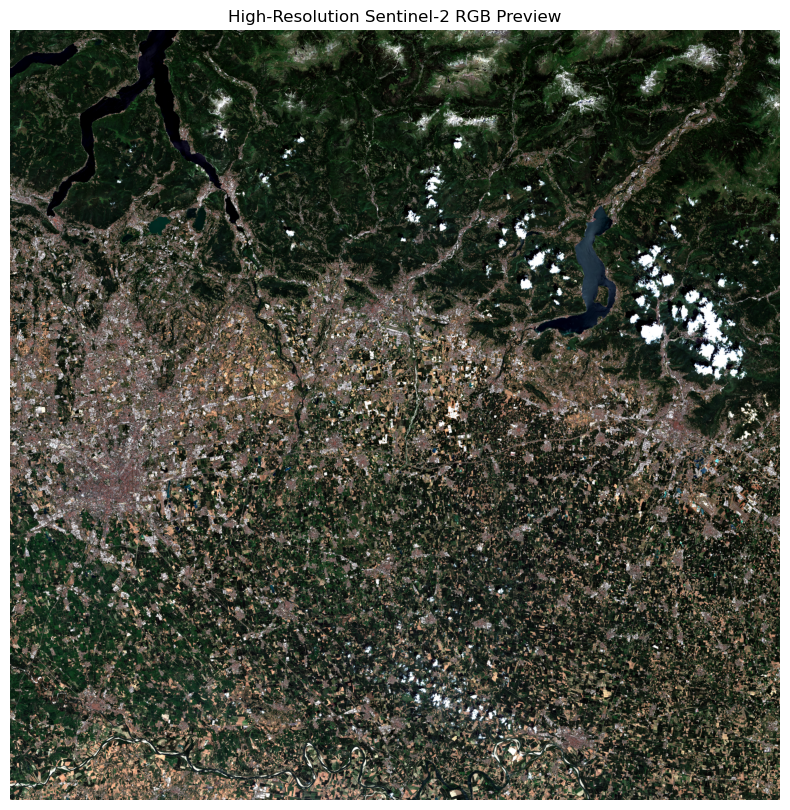

In [6]:
# ============================================================
# STEP — CREATE HIGH-RESOLUTION SENTINEL-2 RGB PREVIEW
# For interactive training-polygon drawing
# ============================================================

from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt

from PIL import Image


# ============================================================
# 1. CHECK REQUIRED BAND PATHS
# ============================================================

required_variables = [
    "PROJECT_DIR",
    "B2_PATH",
    "B3_PATH",
    "B4_PATH",
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        +
        "\n".join(missing_variables)
        +
        "\n\nRun the Sentinel-2 preparation cells first."
    )


# ============================================================
# 2. HIGH-RESOLUTION PREVIEW SETTINGS
# ============================================================

# Maximum width/height of the preview image.
#
# 5000 gives a large improvement over a normal notebook preview
# while remaining practical for ipyleaflet.
#
# If your computer handles it comfortably, you can later try
# 6000 or 7000.

RGB_PREVIEW_MAX_SIZE = 5000


# Percentile stretch.
#
# This improves contrast without modifying the original raster.

RGB_LOWER_PERCENTILE = 2
RGB_UPPER_PERCENTILE = 98


# JPEG quality:
# PNG is used below because it preserves detail without
# compression artefacts.

RGB_PREVIEW = (
    Path(PROJECT_DIR)
    /
    "sentinel2_rgb_preview.png"
)


# ============================================================
# 3. READ SENTINEL-2 RGB BANDS
# ============================================================

print("=" * 70)
print("CREATING HIGH-RESOLUTION SENTINEL-2 RGB PREVIEW")
print("=" * 70)


with rasterio.open(B4_PATH) as src:

    red = src.read(1).astype(
        np.float32
    )

    reference_shape = (
        src.height,
        src.width
    )

    reference_crs = src.crs

    reference_transform = src.transform


with rasterio.open(B3_PATH) as src:

    green = src.read(1).astype(
        np.float32
    )


with rasterio.open(B2_PATH) as src:

    blue = src.read(1).astype(
        np.float32
    )


# ============================================================
# 4. VERIFY BAND ALIGNMENT
# ============================================================

if (
    red.shape != green.shape
    or
    red.shape != blue.shape
):

    raise RuntimeError(
        "B02, B03 and B04 do not have identical dimensions."
    )


print(
    "\nOriginal RGB raster size:",
    red.shape
)

print(
    "CRS:",
    reference_crs
)

print(
    "Original spatial resolution: 10 m"
)


# ============================================================
# 5. VALID RGB MASK
# ============================================================

valid_rgb = (
    np.isfinite(red)
    &
    np.isfinite(green)
    &
    np.isfinite(blue)
    &
    (
        (red != 0)
        |
        (green != 0)
        |
        (blue != 0)
    )
)


if not np.any(valid_rgb):

    raise RuntimeError(
        "No valid RGB pixels were found."
    )


# ============================================================
# 6. CONTRAST-STRETCH FUNCTION
# ============================================================

def stretch_band(
    band,
    valid_mask,
    low_percentile,
    high_percentile
):

    valid_values = band[
        valid_mask
    ]


    low = np.percentile(
        valid_values,
        low_percentile
    )


    high = np.percentile(
        valid_values,
        high_percentile
    )


    if high <= low:

        high = low + 1.0


    stretched = (
        band - low
    ) / (
        high - low
    )


    stretched = np.clip(
        stretched,
        0.0,
        1.0
    )


    stretched[
        ~valid_mask
    ] = 0.0


    return stretched


# ============================================================
# 7. STRETCH EACH RGB CHANNEL
# ============================================================

print(
    "\nApplying RGB contrast stretch..."
)


red_display = stretch_band(
    red,
    valid_rgb,
    RGB_LOWER_PERCENTILE,
    RGB_UPPER_PERCENTILE
)


green_display = stretch_band(
    green,
    valid_rgb,
    RGB_LOWER_PERCENTILE,
    RGB_UPPER_PERCENTILE
)


blue_display = stretch_band(
    blue,
    valid_rgb,
    RGB_LOWER_PERCENTILE,
    RGB_UPPER_PERCENTILE
)


# ============================================================
# 8. BUILD TRUE-COLOR RGB IMAGE
# ============================================================

rgb = np.dstack(
    [
        red_display,
        green_display,
        blue_display
    ]
)


# Convert from 0–1 float to 8-bit RGB.

rgb_uint8 = (
    rgb * 255
).astype(
    np.uint8
)


# ============================================================
# 9. CONVERT TO PIL IMAGE
# ============================================================

rgb_image = Image.fromarray(
    rgb_uint8,
    mode="RGB"
)


original_width, original_height = (
    rgb_image.size
)


print(
    "\nOriginal image dimensions:",
    original_width,
    "x",
    original_height
)


# ============================================================
# 10. RESIZE FOR HIGH-RESOLUTION INTERACTIVE PREVIEW
# ============================================================

largest_dimension = max(
    original_width,
    original_height
)


if largest_dimension > RGB_PREVIEW_MAX_SIZE:

    scale_factor = (
        RGB_PREVIEW_MAX_SIZE
        /
        largest_dimension
    )


    preview_width = int(
        round(
            original_width
            *
            scale_factor
        )
    )


    preview_height = int(
        round(
            original_height
            *
            scale_factor
        )
    )


    print(
        "\nCreating high-resolution preview:"
    )

    print(
        preview_width,
        "x",
        preview_height,
        "pixels"
    )


    rgb_image = rgb_image.resize(

        (
            preview_width,
            preview_height
        ),

        resample=Image.Resampling.LANCZOS

    )


else:

    print(
        "\nOriginal image is already smaller than "
        "the requested preview size."
    )


# ============================================================
# 11. SAVE HIGH-RESOLUTION PNG
# ============================================================

RGB_PREVIEW.parent.mkdir(
    parents=True,
    exist_ok=True
)


rgb_image.save(
    RGB_PREVIEW,
    format="PNG",
    optimize=True
)


# ============================================================
# 12. VERIFY SAVED PREVIEW
# ============================================================

with Image.open(
    RGB_PREVIEW
) as check:

    saved_width, saved_height = (
        check.size
    )


file_size_mb = (
    RGB_PREVIEW.stat().st_size
    /
    (1024 ** 2)
)


print("\n" + "=" * 70)

print(
    "HIGH-RESOLUTION RGB PREVIEW CREATED SUCCESSFULLY"
)

print("=" * 70)

print(
    "\nPreview path:"
)

print(
    RGB_PREVIEW
)

print(
    "\nPreview dimensions:",
    saved_width,
    "x",
    saved_height
)

print(
    f"Preview file size: "
    f"{file_size_mb:.2f} MB"
)

print(
    "\nOriginal Sentinel-2 spatial resolution: 10 m"
)

print(
    "Preview display size:",
    RGB_PREVIEW_MAX_SIZE,
    "pixels maximum"
)


# ============================================================
# 13. OPTIONAL NOTEBOOK PREVIEW
# ============================================================

plt.figure(
    figsize=(10, 10)
)

plt.imshow(
    rgb_image
)

plt.title(
    "High-Resolution Sentinel-2 RGB Preview"
)

plt.axis(
    "off"
)

plt.show()

## Step 6 — Draw and Save Training Polygons
Draw representative training polygons and monitor live polygon counts, available pixels, and class balance before saving.


In [7]:
# ============================================================
# STEP 6 — INTERACTIVE TRAINING-POLYGON COLLECTION
#
# - Loads existing training_polygons.gpkg automatically
# - Displays ALL training polygons as clickable GeoJSON
# - Click any polygon to review/change its class
# - Supports Urban / Vegetation / Water / Bare Soil relabelling
# - Supports individual polygon deletion
# - Allows drawing new polygons
# - Saves the complete edited dataset
# - High-resolution satellite DEFAULT visual reference
# - Maximum-quality Sentinel-2 RGB optional switchable visual reference
# - Sentinel-2 tile boundary
# - Live polygons / unique Sentinel-2 pixels / balance
# - Minimum 20 polygons + 2,000 pixels per class
# - Spectral QC across ALL four classes using robust spectral distances
# - QC never changes labels automatically
# ============================================================

import os
import sys
import copy
import subprocess
import importlib.util
from pathlib import Path
from io import BytesIO
import base64

import numpy as np
import pandas as pd
import rasterio

from rasterio.features import geometry_mask
from rasterio.warp import (
    transform_bounds,
    calculate_default_transform,
    reproject,
)
from rasterio.enums import Resampling
from rasterio.windows import Window

from shapely.geometry import shape, box


# ============================================================
# 1. QUALITY SETTINGS
# ============================================================

MIN_POLYGONS_PER_CLASS = 20
TARGET_PIXELS_PER_CLASS = 2000
GOOD_BALANCE_RATIO = 0.70

MAX_MAP_ZOOM = 20


# ============================================================
# 1B. LABEL-QC SETTINGS
# ============================================================

# A polygon is flagged only when another class centroid is
# meaningfully closer than its assigned-class reference.
# 0.90 = alternative class must be at least 10% closer.
LABEL_QC_RATIO = 0.90

# Maximum number of suspects shown in the dropdown/table.
LABEL_QC_MAX_DISPLAY = 25

# Minimum number of polygons required in a class for robust
# leave-one-out comparison. Current project target is >=20.
LABEL_QC_MIN_CLASS_POLYGONS = 3


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "PROJECT_DIR",
    "TRAINING_PATH",
    "CREATE_NEW_TRAINING_POLYGONS",
    "CLASS_MAP",
    "B2_PATH",
    "B3_PATH",
    "B4_PATH",
    "B8_PATH",
    "B11_PATH",
    "B12_PATH",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        + "\n".join(missing_variables)
        + "\n\nRun the previous Sentinel-2 preparation cells first."
    )


# ============================================================
# 3. EXISTING-ONLY MODE
# ============================================================

if not CREATE_NEW_TRAINING_POLYGONS:

    print("=" * 70)
    print("STEP 6 — EXISTING TRAINING POLYGONS")
    print("=" * 70)

    print("\nInteractive polygon creation is disabled.")
    print("Using existing training polygons:")
    print(TRAINING_PATH)

    if not Path(TRAINING_PATH).exists():

        raise FileNotFoundError(
            "Training polygon file was not found.\n"
            "Set CREATE_NEW_TRAINING_POLYGONS = True "
            "to create or review a training dataset."
        )


# ============================================================
# 4. INTERACTIVE MODE
# ============================================================

else:

    # ========================================================
    # PACKAGE CHECK
    # ========================================================

    required_packages = {
        "ipyleaflet": "ipyleaflet",
        "ipywidgets": "ipywidgets",
        "geopandas": "geopandas",
        "PIL": "Pillow",
    }

    for module_name, package_name in required_packages.items():

        if importlib.util.find_spec(module_name) is None:

            print(
                f"Installing missing package: {package_name}"
            )

            subprocess.check_call(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "install",
                    package_name,
                ]
            )


    # ========================================================
    # IMPORTS
    # ========================================================

    import geopandas as gpd
    import ipywidgets as widgets

    from IPython.display import display

    from ipyleaflet import (
        Map,
        DrawControl,
        WidgetControl,
        LayersControl,
        TileLayer,
        ImageOverlay,
        Polygon,
        GeoJSON,
        Popup,
        basemaps,
        basemap_to_tiles,
    )

    from PIL import Image


    # ========================================================
    # 5. READ SENTINEL-2 REFERENCE
    # ========================================================

    with rasterio.open(B2_PATH) as ref:

        raster_crs = ref.crs
        raster_transform = ref.transform

        raster_width = ref.width
        raster_height = ref.height

        raster_bounds = ref.bounds
        raster_resolution = ref.res

        raster_profile = ref.profile.copy()


    if raster_crs is None:

        raise RuntimeError(
            "Reference Sentinel-2 raster has no CRS."
        )


    print("=" * 70)
    print("STEP 6 — INTERACTIVE TRAINING-POLYGON COLLECTION")
    print("=" * 70)

    print(
        "\nReference Sentinel-2 raster:",
        B2_PATH
    )

    print(
        "CRS:",
        raster_crs
    )

    print(
        "Raster size:",
        raster_width,
        "x",
        raster_height
    )

    print(
        "Spatial resolution:",
        raster_resolution
    )

    print("\nTraining criteria:")

    print(
        f"- Minimum polygons/class: "
        f"{MIN_POLYGONS_PER_CLASS}"
    )

    print(
        f"- Minimum Sentinel-2 pixels/class: "
        f"{TARGET_PIXELS_PER_CLASS:,}"
    )


    # ========================================================
    # 6. VERIFY QC BAND COMPATIBILITY
    # ========================================================

    qc_band_paths = {
        "B2": B2_PATH,
        "B3": B3_PATH,
        "B4": B4_PATH,
        "B8": B8_PATH,
        "B11": B11_PATH,
        "B12": B12_PATH,
    }


    for band_name, band_path in qc_band_paths.items():

        with rasterio.open(band_path) as src:

            if src.crs != raster_crs:

                raise RuntimeError(
                    f"{band_name} CRS does not match B2."
                )

            if (
                src.width != raster_width
                or
                src.height != raster_height
            ):

                raise RuntimeError(
                    f"{band_name} dimensions do not match B2."
                )

            if not src.transform.almost_equals(
                raster_transform
            ):

                raise RuntimeError(
                    f"{band_name} transform does not match B2."
                )


    print(
        "Six-band Sentinel-2 QC stack: VERIFIED"
    )


    # ========================================================
    # 7. FULL-RESOLUTION SENTINEL-2 RGB
    # ========================================================

    RGB_TILE_TIF = (
        Path(PROJECT_DIR)
        /
        "sentinel2_rgb_full_resolution.tif"
    )


    def percentile_stretch(
        band,
        valid_mask,
        low=2,
        high=98,
    ):

        values = band[
            valid_mask
        ]

        if values.size == 0:

            raise RuntimeError(
                "No valid pixels found for RGB stretch."
            )

        low_value = np.percentile(
            values,
            low
        )

        high_value = np.percentile(
            values,
            high
        )

        if high_value <= low_value:

            high_value = (
                low_value + 1
            )

        stretched = (
            band - low_value
        ) / (
            high_value - low_value
        )

        stretched = np.clip(
            stretched,
            0,
            1
        )

        stretched[
            ~valid_mask
        ] = 0

        return (
            stretched * 255
        ).astype(
            np.uint8
        )


    if not RGB_TILE_TIF.exists():

        print(
            "\nCreating full-resolution Sentinel-2 RGB..."
        )

        with rasterio.open(B4_PATH) as src:
            red = src.read(1).astype(
                np.float32
            )

        with rasterio.open(B3_PATH) as src:
            green = src.read(1).astype(
                np.float32
            )

        with rasterio.open(B2_PATH) as src:
            blue = src.read(1).astype(
                np.float32
            )


        if not (
            red.shape
            ==
            green.shape
            ==
            blue.shape
        ):

            raise RuntimeError(
                "B02, B03 and B04 dimensions do not match."
            )


        valid_rgb = (
            np.isfinite(red)
            &
            np.isfinite(green)
            &
            np.isfinite(blue)
            &
            (
                (red != 0)
                |
                (green != 0)
                |
                (blue != 0)
            )
        )


        if not np.any(
            valid_rgb
        ):

            raise RuntimeError(
                "No valid Sentinel-2 RGB pixels were found."
            )


        print(
            "Applying 2–98 percentile contrast stretch..."
        )


        red_8bit = percentile_stretch(
            red,
            valid_rgb
        )

        green_8bit = percentile_stretch(
            green,
            valid_rgb
        )

        blue_8bit = percentile_stretch(
            blue,
            valid_rgb
        )


        rgb_profile = raster_profile.copy()

        rgb_profile.update(
            driver="GTiff",
            dtype="uint8",
            count=3,
            nodata=0,
            compress="deflate",
            tiled=True,
            blockxsize=256,
            blockysize=256,
            photometric="RGB",
        )


        with rasterio.open(
            RGB_TILE_TIF,
            "w",
            **rgb_profile,
        ) as dst:

            dst.write(
                red_8bit,
                1
            )

            dst.write(
                green_8bit,
                2
            )

            dst.write(
                blue_8bit,
                3
            )


        del (
            red,
            green,
            blue,
            red_8bit,
            green_8bit,
            blue_8bit,
        )


        print(
            "Full-resolution Sentinel-2 RGB created."
        )

    else:

        print(
            "\nExisting full-resolution Sentinel-2 RGB found."
        )


    print(
        "RGB raster:",
        RGB_TILE_TIF
    )


    # ========================================================
    # 8. BUILD / VERIFY OVERVIEWS
    # ========================================================

    print(
        "\nChecking raster overviews..."
    )


    with rasterio.open(
        RGB_TILE_TIF,
        "r+",
    ) as src:

        existing_overviews = src.overviews(
            1
        )

        if not existing_overviews:

            print(
                "Building raster overviews..."
            )

            overview_levels = [
                2,
                4,
                8,
                16,
                32,
            ]

            src.build_overviews(
                overview_levels,
                Resampling.average,
            )

            src.update_tags(
                ns="rio_overview",
                resampling="average",
            )

            print(
                "Raster overviews created."
            )

        else:

            print(
                "Raster overviews already exist:",
                existing_overviews
            )


    # ========================================================
    # 9. TILE BOUNDS
    # ========================================================

    west, south, east, north = transform_bounds(
        raster_crs,
        "EPSG:4326",
        *raster_bounds,
        densify_pts=21,
    )

    center = (
        (south + north) / 2,
        (west + east) / 2,
    )

    tile_extent_wgs84 = box(
        west,
        south,
        east,
        north,
    )


    # ========================================================
    # 10. SENTINEL-2 RGB DISPLAY — TRUE WEB-MAP REPROJECTION
    #
    # IMPORTANT:
    # Leaflet/ipyleaflet renders its map in Web Mercator
    # (EPSG:3857). Therefore the Sentinel-2 RGB used ONLY for
    # visual display is reprojected from the native raster CRS
    # to EPSG:3857 before it is passed to ImageOverlay.
    #
    # The ImageOverlay still receives latitude/longitude bounds
    # because that is what Leaflet's API expects, but those
    # bounds are derived from the already-reprojected EPSG:3857
    # display raster.
    #
    # Training polygons, pixel counting, spectral QC and saving
    # continue to use the original Sentinel-2 raster CRS.
    # ========================================================

    SENTINEL_DISPLAY_CRS = "EPSG:3857"
    SENTINEL_DISPLAY_MAX_SIZE = 6000

    sentinel_layer = None


    print(
        "\nPreparing correctly reprojected "
        "Sentinel-2 RGB display layer..."
    )


    try:

        with rasterio.open(
            RGB_TILE_TIF
        ) as src:

            if src.crs is None:

                raise RuntimeError(
                    "Sentinel-2 RGB raster has no CRS."
                )


            print(
                "Original Sentinel-2 RGB size:",
                src.width,
                "x",
                src.height
            )

            print(
                "Original display-source CRS:",
                src.crs
            )


            # ------------------------------------------------
            # A. Calculate a true Web-Mercator output grid
            # ------------------------------------------------

            (
                full_display_transform,
                full_display_width,
                full_display_height,
            ) = calculate_default_transform(

                src.crs,
                SENTINEL_DISPLAY_CRS,

                src.width,
                src.height,

                *src.bounds,
            )


            largest_dimension = max(
                full_display_width,
                full_display_height,
            )


            if (
                largest_dimension
                >
                SENTINEL_DISPLAY_MAX_SIZE
            ):

                scale_factor = (
                    SENTINEL_DISPLAY_MAX_SIZE
                    /
                    largest_dimension
                )

            else:

                scale_factor = 1.0


            display_width = max(
                1,
                int(
                    round(
                        full_display_width
                        *
                        scale_factor
                    )
                )
            )


            display_height = max(
                1,
                int(
                    round(
                        full_display_height
                        *
                        scale_factor
                    )
                )
            )


            # Keep the geographic coverage of the full
            # reprojected raster while reducing only its
            # display resolution.
            display_transform = (
                full_display_transform
                *
                rasterio.Affine.scale(
                    full_display_width
                    /
                    display_width,

                    full_display_height
                    /
                    display_height,
                )
            )


            print(
                "Reprojected display CRS:",
                SENTINEL_DISPLAY_CRS
            )

            print(
                "Interactive display size:",
                display_width,
                "x",
                display_height
            )

            print(
                "Sentinel display quality: MAXIMUM-PRACTICAL "
                "(6000 px cap, Lanczos reprojection, JPEG 98 / 4:4:4)"
            )


            # ------------------------------------------------
            # B. Reproject every RGB pixel into Web Mercator
            # ------------------------------------------------

            display_rgb = np.zeros(

                (
                    3,
                    display_height,
                    display_width,
                ),

                dtype=np.uint8,
            )


            for band_index in (
                1,
                2,
                3,
            ):

                reproject(

                    source=rasterio.band(
                        src,
                        band_index
                    ),

                    destination=display_rgb[
                        band_index - 1
                    ],

                    src_transform=src.transform,

                    src_crs=src.crs,

                    src_nodata=0,

                    dst_transform=display_transform,

                    dst_crs=SENTINEL_DISPLAY_CRS,

                    dst_nodata=0,

                    resampling=Resampling.lanczos,
                )


        # ----------------------------------------------------
        # C. Get exact bounds of the reprojected display grid
        # ----------------------------------------------------

        (
            display_west_3857,
            display_south_3857,
            display_east_3857,
            display_north_3857,
        ) = rasterio.transform.array_bounds(

            display_height,
            display_width,
            display_transform,
        )


        (
            display_west,
            display_south,
            display_east,
            display_north,
        ) = transform_bounds(

            SENTINEL_DISPLAY_CRS,
            "EPSG:4326",

            display_west_3857,
            display_south_3857,
            display_east_3857,
            display_north_3857,

            densify_pts=21,
        )


        # ----------------------------------------------------
        # D. Encode the already-reprojected RGB for Leaflet
        # ----------------------------------------------------

        rgb_image_array = np.moveaxis(
            display_rgb,
            0,
            -1
        )


        rgb_image = Image.fromarray(
            rgb_image_array
        )


        buffer = BytesIO()

        rgb_image.save(
            buffer,
            format="JPEG",
            quality=98,
            subsampling=0,
            optimize=True,
            progressive=True,
        )


        encoded_bytes = (
            buffer.getvalue()
        )


        print(
            "Encoded display size:",
            round(
                len(encoded_bytes)
                /
                1024
                /
                1024,
                2
            ),
            "MB"
        )


        sentinel_data_url = (
            "data:image/jpeg;base64,"
            +
            base64.b64encode(
                encoded_bytes
            ).decode(
                "utf-8"
            )
        )


        sentinel_layer = ImageOverlay(

            url=sentinel_data_url,

            bounds=(
                (
                    display_south,
                    display_west
                ),

                (
                    display_north,
                    display_east
                ),
            ),

            name=(
                "Sentinel-2 RGB "
                "(correctly reprojected display)"
            ),

            visible=True,

            opacity=0.0,
        )


        print(
            "Sentinel-2 RGB display layer ready."
        )

        print(
            "Visual alignment method:"
        )

        print(
            f"{raster_crs} → "
            f"{SENTINEL_DISPLAY_CRS} "
            "true pixel reprojection → ImageOverlay"
        )

        print(
            "Default visual reference: "
            "High-Resolution Satellite"
        )


        del display_rgb
        del rgb_image_array
        del rgb_image
        del encoded_bytes

        buffer.close()


    except Exception as exc:

        sentinel_layer = None

        print(
            "\nWARNING: Sentinel-2 visual display "
            "could not be prepared."
        )

        print(
            "Reason:",
            exc
        )

        print(
            "Training polygons and Sentinel-2 pixel "
            "calculations are NOT affected."
        )


    # ========================================================
    # 11. HIGH-RESOLUTION SATELLITE
    # ========================================================

    satellite_reference = TileLayer(

        url=(
            "https://server.arcgisonline.com/"
            "ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/"
            "{z}/{y}/{x}"
        ),

        name=(
            "High-Resolution Satellite Reference"
        ),

        attribution=(
            "Esri, Maxar, Earthstar Geographics, "
            "and the GIS User Community"
        ),

        opacity=1.0,

        max_zoom=20,

        visible=True,
    )


    # ========================================================
    # 12. OPENSTREETMAP
    # ========================================================

    osm_layer = basemap_to_tiles(
        basemaps.OpenStreetMap.Mapnik
    )

    osm_layer.name = (
        "OpenStreetMap reference"
    )


    # ========================================================
    # 13. CREATE MAP
    # ========================================================

    m = Map(

        center=center,

        zoom=10,

        max_zoom=MAX_MAP_ZOOM,

        scroll_wheel_zoom=True,

        layout=widgets.Layout(
            width="100%",
            height="520px",
            min_height="520px",
        ),
    )


    m.add(
        osm_layer
    )


    if sentinel_layer is not None:

        m.add(
            sentinel_layer
        )


    m.add(
        satellite_reference
    )


    # ========================================================
    # 14. TILE BOUNDARY
    # ========================================================

    tile_boundary = Polygon(

        locations=[
            [south, west],
            [south, east],
            [north, east],
            [north, west],
            [south, west],
        ],

        color="yellow",

        weight=4,

        fill=False,

        name="Sentinel-2 Tile Boundary",
    )


    m.add(
        tile_boundary
    )


    m.add(
        LayersControl(
            position="topright"
        )
    )


    m.fit_bounds(
        [
            [south, west],
            [north, east],
        ]
    )


    # ========================================================
    # 15. FEATURE STORAGE
    # ========================================================

    drawn_features = []


    # ========================================================
    # 16. POLYGON ID HELPERS
    # ========================================================

    def ensure_polygon_ids():

        used_ids = set()


        for feature in drawn_features:

            props = feature.setdefault(
                "properties",
                {}
            )

            polygon_id = props.get(
                "polygon_id"
            )


            if polygon_id is not None:

                try:

                    polygon_id = int(
                        polygon_id
                    )

                    props[
                        "polygon_id"
                    ] = polygon_id

                    used_ids.add(
                        polygon_id
                    )

                except Exception:

                    props.pop(
                        "polygon_id",
                        None
                    )


        next_id = 1


        for feature in drawn_features:

            props = feature.setdefault(
                "properties",
                {}
            )


            if props.get(
                "polygon_id"
            ) is not None:

                continue


            while next_id in used_ids:

                next_id += 1


            props[
                "polygon_id"
            ] = next_id


            used_ids.add(
                next_id
            )


            next_id += 1


    def get_next_polygon_id():

        ensure_polygon_ids()


        existing_ids = [

            int(
                feature
                .get(
                    "properties",
                    {}
                )
                .get(
                    "polygon_id"
                )
            )

            for feature
            in drawn_features

            if (
                feature
                .get(
                    "properties",
                    {}
                )
                .get(
                    "polygon_id"
                )
                is not None
            )
        ]


        if not existing_ids:

            return 1


        return (
            max(
                existing_ids
            )
            +
            1
        )


    # ========================================================
    # 17. CLASS SELECTOR
    # ========================================================

    class_dropdown = widgets.Dropdown(

        options=[
            ("Urban", 1),
            ("Vegetation", 2),
            ("Water", 3),
            ("Bare Soil", 4),
        ],

        value=1,

        description="Class:",

        style={
            "description_width":
                "initial"
        },

        layout=widgets.Layout(
            width="245px"
        ),
    )


    # ========================================================
    # 18. SENTINEL-2 VISIBILITY SWITCH
    # ========================================================

    sentinel_toggle = widgets.Checkbox(

        value=False,

        description="Show Sentinel-2 RGB",

        indent=False,

        disabled=(
            sentinel_layer is None
        ),

        layout=widgets.Layout(
            width="245px"
        ),
    )


    def toggle_sentinel(
        change
    ):

        if sentinel_layer is None:

            return


        show_sentinel = bool(
            change[
                "new"
            ]
        )


        if show_sentinel:

            # Display Sentinel-2 clearly.
            sentinel_layer.opacity = 1.0

            # Temporarily hide high-resolution imagery.
            satellite_reference.opacity = 0.0


        else:

            # Hide Sentinel-2.
            sentinel_layer.opacity = 0.0

            # Restore high-resolution imagery.
            satellite_reference.opacity = 1.0


    sentinel_toggle.observe(
        toggle_sentinel,
        names="value"
    )


    # ========================================================
    # 19. BUTTONS
    # ========================================================

    save_button = widgets.Button(

        description="Save + Check",

        button_style="success",

        icon="check",

        layout=widgets.Layout(
            width="125px"
        ),
    )


    clear_button = widgets.Button(

        description="Clear ALL",

        button_style="danger",

        icon="trash",

        tooltip=(
            "Clear all training polygons "
            "from the current map session."
        ),

        layout=widgets.Layout(
            width="105px"
        ),
    )


    check_labels_button = widgets.Button(

        description="Check Labels",

        button_style="info",

        icon="search",

        tooltip=(
            "Check possible cross-class spectral "
            "training-label conflicts."
        ),

        layout=widgets.Layout(
            width="235px"
        ),
    )


    button_row = widgets.HBox(

        [
            save_button,
            clear_button,
        ],

        layout=widgets.Layout(
            width="240px"
        ),
    )


    # ========================================================
    # 20. CONTROL PANEL
    # ========================================================

    controls = widgets.VBox(

        [

            widgets.HTML(
                value=(
                    "<b style='font-size:13px;'>"
                    "Training Polygons"
                    "</b>"
                )
            ),

            class_dropdown,

            sentinel_toggle,

            check_labels_button,

            widgets.HTML(
                value=(
                    "<span style='font-size:11px;'>"
                    f"Target: ≥{MIN_POLYGONS_PER_CLASS} polygons, "
                    f"≥{TARGET_PIXELS_PER_CLASS:,} pixels/class"
                    "</span>"
                )
            ),

            button_row,
        ],

        layout=widgets.Layout(
            width="275px",
            padding="5px",
        ),
    )


    m.add(
        WidgetControl(
            widget=controls,
            position="topleft",
        )
    )


    # ========================================================
    # 21. LIVE STATUS
    # ========================================================

    status = widgets.HTML(

        value=(
            "<h4>LIVE TRAINING BALANCE</h4>"
            "Checking existing training dataset..."
        ),

        layout=widgets.Layout(
            width="100%",
            border="1px solid #dddddd",
            padding="10px",
        ),
    )


    # ========================================================
    # 22. DRAW CONTROL
    # Only used to CREATE new polygons.
    # ========================================================

    draw = DrawControl()


    draw.polygon = {

        "shapeOptions": {

            "fillOpacity": 0.15,

            "weight": 2,
        }
    }


    draw.polyline = {}
    draw.circle = {}
    draw.circlemarker = {}
    draw.rectangle = {}
    draw.marker = {}


    m.add(
        draw
    )


    # ========================================================
    # 23. TRAINING POLYGON STYLE
    # ========================================================

    CLASS_COLORS = {
        1: "#ff7800",   # Urban
        2: "#2ca02c",   # Vegetation
        3: "#1f77b4",   # Water
        4: "#b8860b",   # Bare Soil
    }


    def training_style_callback(
        feature
    ):

        props = feature.get(
            "properties",
            {}
        )


        class_id = int(
            props.get(
                "class_id",
                0
            )
        )


        color = CLASS_COLORS.get(
            class_id,
            "#ffffff"
        )


        return {
            "color":
                color,

            "weight":
                2,

            "fillColor":
                color,

            "fillOpacity":
                0.18,
        }


    # ========================================================
    # 24. CLICKABLE TRAINING LAYER
    # ========================================================

    training_layer = GeoJSON(

        data={
            "type":
                "FeatureCollection",

            "features":
                [],
        },

        name="Training Polygons",

        style_callback=
            training_style_callback,

        hover_style={
            "weight": 5,
            "fillOpacity": 0.30,
        },
    )


    m.add(
        training_layer
    )


    # ========================================================
    # 25. QC HIGHLIGHT LAYER
    # ========================================================

    qc_layer = GeoJSON(

        data={
            "type":
                "FeatureCollection",

            "features":
                [],
        },

        name="Suspected Label Errors",

        style={
            "color":
                "#ff00ff",

            "weight":
                5,

            "fillColor":
                "#ff00ff",

            "fillOpacity":
                0.28,
        },
    )


    m.add(
        qc_layer
    )


    # ========================================================
    # 26. REFRESH TRAINING DISPLAY
    # ========================================================

    def refresh_training_display():

        ensure_polygon_ids()


        training_layer.data = {

            "type":
                "FeatureCollection",

            "features":
                copy.deepcopy(
                    drawn_features
                ),
        }


    # ========================================================
    # 27. FEATURES → RASTER CRS
    # ========================================================

    def features_to_raster_gdf():

        if not drawn_features:

            return None


        gdf = (
            gpd.GeoDataFrame
            .from_features(
                drawn_features,
                crs="EPSG:4326",
            )
        )


        return gdf.to_crs(
            raster_crs
        )


    # ========================================================
    # 28. UNIQUE SENTINEL-2 PIXEL COUNTER
    # ========================================================

    def count_unique_pixels(
        input_gdf
    ):

        if (
            input_gdf is None
            or
            len(input_gdf) == 0
        ):

            return 0


        geometries = [

            geom

            for geom
            in input_gdf.geometry

            if (
                geom is not None
                and
                not geom.is_empty
            )
        ]


        if not geometries:

            return 0


        minx, miny, maxx, maxy = (
            input_gdf.total_bounds
        )


        inverse_transform = (
            ~raster_transform
        )


        col1, row1 = (
            inverse_transform
            *
            (
                minx,
                maxy,
            )
        )


        col2, row2 = (
            inverse_transform
            *
            (
                maxx,
                miny,
            )
        )


        row_start = max(
            0,
            int(
                np.floor(
                    min(
                        row1,
                        row2,
                    )
                )
            ),
        )


        row_stop = min(
            raster_height,
            int(
                np.ceil(
                    max(
                        row1,
                        row2,
                    )
                )
            )
            + 1,
        )


        col_start = max(
            0,
            int(
                np.floor(
                    min(
                        col1,
                        col2,
                    )
                )
            ),
        )


        col_stop = min(
            raster_width,
            int(
                np.ceil(
                    max(
                        col1,
                        col2,
                    )
                )
            )
            + 1,
        )


        if (
            row_stop <= row_start
            or
            col_stop <= col_start
        ):

            return 0


        local_transform = (
            raster_transform
            *
            rasterio.Affine.translation(
                col_start,
                row_start,
            )
        )


        local_height = (
            row_stop
            -
            row_start
        )


        local_width = (
            col_stop
            -
            col_start
        )


        local_mask = geometry_mask(

            geometries,

            transform=local_transform,

            invert=True,

            out_shape=(
                local_height,
                local_width,
            ),

            all_touched=False,
        )


        return int(
            np.count_nonzero(
                local_mask
            )
        )


    # ========================================================
    # 29. TRAINING QUALITY
    # ========================================================

    def calculate_training_quality():

        gdf = (
            features_to_raster_gdf()
        )


        quality_rows = []


        for class_id in sorted(
            CLASS_MAP
        ):

            class_name = CLASS_MAP[
                class_id
            ]


            if gdf is None:

                polygon_count = 0
                available_pixels = 0

            else:

                class_gdf = gdf[
                    gdf[
                        "class_id"
                    ]
                    ==
                    class_id
                ]


                polygon_count = len(
                    class_gdf
                )


                available_pixels = (
                    count_unique_pixels(
                        class_gdf
                    )
                )


            polygon_ok = (
                polygon_count
                >=
                MIN_POLYGONS_PER_CLASS
            )


            pixel_ok = (
                available_pixels
                >=
                TARGET_PIXELS_PER_CLASS
            )


            if polygon_ok and pixel_ok:

                quality_status = (
                    "GOOD"
                )

            elif (
                not polygon_ok
                and
                not pixel_ok
            ):

                quality_status = (
                    "MORE POLYGONS + PIXELS"
                )

            elif not polygon_ok:

                quality_status = (
                    "MORE POLYGONS"
                )

            else:

                quality_status = (
                    "MORE PIXELS"
                )


            quality_rows.append(
                {
                    "Class ID":
                        class_id,

                    "Class":
                        class_name,

                    "Polygons":
                        polygon_count,

                    "Sentinel-2 Pixels":
                        available_pixels,

                    "Status":
                        quality_status,
                }
            )


        quality_df = pd.DataFrame(
            quality_rows
        )


        total_polygons = int(
            quality_df[
                "Polygons"
            ].sum()
        )


        if gdf is None:

            total_unique_pixels = 0

        else:

            total_unique_pixels = (
                count_unique_pixels(
                    gdf
                )
            )


        polygon_counts = (
            quality_df[
                "Polygons"
            ].to_numpy(
                dtype=float
            )
        )


        pixel_counts = (
            quality_df[
                "Sentinel-2 Pixels"
            ].to_numpy(
                dtype=float
            )
        )


        if polygon_counts.max() > 0:

            polygon_balance = (
                polygon_counts.min()
                /
                polygon_counts.max()
            )

        else:

            polygon_balance = 0.0


        if pixel_counts.max() > 0:

            pixel_balance = (
                pixel_counts.min()
                /
                pixel_counts.max()
            )

        else:

            pixel_balance = 0.0


        return (
            quality_df,
            polygon_balance,
            pixel_balance,
            total_polygons,
            total_unique_pixels,
            gdf,
        )


    # ========================================================
    # 30. LIVE STATUS UPDATE
    # ========================================================

    def update_live_status(
        message=None
    ):

        (
            quality_df,
            polygon_balance,
            pixel_balance,
            total_polygons,
            total_unique_pixels,
            _
        ) = calculate_training_quality()


        html = []


        if message:

            html.append(
                f"{message}<br>"
            )


        html.append(
            "<h4 style='margin-bottom:8px;'>"
            "LIVE TRAINING BALANCE"
            "</h4>"
        )


        html.append(
            "<table style='"
            "border-collapse:collapse;"
            "width:100%;"
            "max-width:900px;'>"
        )


        html.append(
            "<tr>"
            "<th style='text-align:left;padding:5px;'>Class</th>"
            "<th style='padding:5px;'>Polygons</th>"
            "<th style='padding:5px;'>Sentinel-2 Pixels</th>"
            "<th style='padding:5px;'>Status</th>"
            "</tr>"
        )


        for _, row in quality_df.iterrows():

            status_color = (
                "green"
                if row["Status"] == "GOOD"
                else
                "darkorange"
            )


            html.append(

                "<tr>"

                f"<td style='padding:5px;'>"
                f"{row['Class']}"
                "</td>"

                f"<td style='padding:5px;"
                "text-align:center;'>"
                f"{int(row['Polygons'])}"
                "</td>"

                f"<td style='padding:5px;"
                "text-align:center;'>"
                f"{int(row['Sentinel-2 Pixels']):,}"
                "</td>"

                f"<td style='padding:5px;"
                f"text-align:center;"
                f"color:{status_color};'>"
                f"{row['Status']}"
                "</td>"

                "</tr>"
            )


        html.append(
            "</table>"
        )


        html.append(
            "<hr>"
        )


        html.append(
            "<b>Total polygons:</b> "
            f"{total_polygons:,}<br>"
        )


        html.append(
            "<b>Total unique Sentinel-2 pixels:</b> "
            f"{total_unique_pixels:,}<br><br>"
        )


        html.append(
            "<b>Polygon balance:</b> "
            f"{polygon_balance:.0%}<br>"
        )


        html.append(
            "<b>Pixel balance:</b> "
            f"{pixel_balance:.0%}<br>"
        )


        if (
            pixel_balance
            >=
            GOOD_BALANCE_RATIO
        ):

            html.append(
                "<b style='color:green;'>"
                "Pixel balance: GOOD"
                "</b>"
            )

        else:

            html.append(
                "<b style='color:darkorange;'>"
                "Pixel balance: NEEDS IMPROVEMENT"
                "</b>"
            )


        status.value = "".join(
            html
        )


    # ========================================================
    # 31. DRAW NEW POLYGON
    # ========================================================

    def handle_draw(
        target,
        action,
        geo_json,
    ):

        if action != "created":

            return


        geometry_json = geo_json.get(
            "geometry"
        )


        if not geometry_json:

            return


        new_geometry = shape(
            geometry_json
        )


        if not new_geometry.is_valid:

            update_live_status(
                message=(
                    "<b style='color:red;'>"
                    "Invalid polygon geometry. "
                    "Polygon was not recorded."
                    "</b>"
                )
            )

            return


        if not new_geometry.within(
            tile_extent_wgs84
        ):

            update_live_status(
                message=(
                    "<b style='color:red;'>"
                    "Polygon lies partly or fully outside "
                    "the selected Sentinel-2 tile and "
                    "was not recorded."
                    "</b>"
                )
            )

            try:
                draw.clear()
            except Exception:
                pass

            return


        class_id = int(
            class_dropdown.value
        )


        class_name = CLASS_MAP[
            class_id
        ]


        polygon_id = (
            get_next_polygon_id()
        )


        drawn_features.append(
            {
                "type":
                    "Feature",

                "properties":
                    {
                        "polygon_id":
                            polygon_id,

                        "class_id":
                            class_id,

                        "class_name":
                            class_name,
                    },

                "geometry":
                    copy.deepcopy(
                        geometry_json
                    ),
            }
        )


        # Remove Leaflet drawing object after recording it.
        # The polygon remains visible through training_layer
        # and is therefore clickable/editable via Popup.
        try:

            draw.clear()

        except Exception:

            pass


        refresh_training_display()


        update_live_status(
            message=(
                "<b style='color:green;'>"
                f"Added Polygon ID {polygon_id} "
                f"to {class_name}. "
                "Click the polygon to review or edit its class."
                "</b>"
            )
        )


    draw.on_draw(
        handle_draw
    )


    # ========================================================
    # 32. LOAD EXISTING TRAINING DATASET
    # ========================================================

    training_path = Path(
        TRAINING_PATH
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        "TRAINING DATASET CHECK"
    )

    print(
        "=" * 70
    )


    if training_path.exists():

        print(
            "\nExisting training dataset found."
        )

        print(
            "Loading saved training polygons..."
        )


        try:

            existing_gdf = gpd.read_file(
                training_path,
                layer="training_polygons",
            )


            if existing_gdf.crs is None:

                raise RuntimeError(
                    "Saved training polygons have no CRS."
                )


            existing_wgs84 = (
                existing_gdf.to_crs(
                    "EPSG:4326"
                )
            )


            restored_features = []


            for feature in (
                existing_wgs84
                .__geo_interface__
                .get(
                    "features",
                    []
                )
            ):

                properties = dict(
                    feature.get(
                        "properties",
                        {}
                    )
                )


                if "class_id" not in properties:

                    continue


                class_id = int(
                    properties[
                        "class_id"
                    ]
                )


                if class_id not in CLASS_MAP:

                    continue


                geometry_json = feature.get(
                    "geometry"
                )


                if geometry_json is None:

                    continue


                restored_features.append(
                    {
                        "type":
                            "Feature",

                        "properties":
                            {
                                **properties,

                                "class_id":
                                    class_id,

                                "class_name":
                                    CLASS_MAP[
                                        class_id
                                    ],
                            },

                        "geometry":
                            copy.deepcopy(
                                geometry_json
                            ),
                    }
                )


            drawn_features.extend(
                restored_features
            )


            ensure_polygon_ids()


            refresh_training_display()


            print(
                f"\nRestored "
                f"{len(restored_features)} "
                "training polygon(s) successfully."
            )


            print(
                "Click any polygon on the map "
                "to review or change its class."
            )


        except Exception as exc:

            print(
                "\nWARNING: Existing training dataset "
                "could not be loaded."
            )

            print(
                "Reason:",
                exc
            )


    else:

        print(
            "\nNo existing training dataset found."
        )

        print(
            "Starting a new training-polygon collection."
        )


    # ========================================================
    # 33. CLICK-TO-EDIT POPUP
    # ========================================================

    current_popup = None


    def find_feature_by_id(
        polygon_id
    ):

        for feature in drawn_features:

            props = feature.get(
                "properties",
                {}
            )


            try:

                current_id = int(
                    props.get(
                        "polygon_id",
                        -1
                    )
                )

            except Exception:

                continue


            if current_id == int(
                polygon_id
            ):

                return feature


        return None


    def remove_current_popup():

        global current_popup


        if current_popup is None:

            return


        try:

            m.remove(
                current_popup
            )

        except Exception:

            pass


        current_popup = None


    def open_polygon_editor(
        polygon_id
    ):

        global current_popup


        feature = find_feature_by_id(
            polygon_id
        )


        if feature is None:

            return


        remove_current_popup()


        props = feature.get(
            "properties",
            {}
        )


        current_class_id = int(
            props.get(
                "class_id"
            )
        )


        geom = shape(
            feature[
                "geometry"
            ]
        )


        centroid = geom.centroid


        popup_class_dropdown = widgets.Dropdown(

            options=[
                ("Urban", 1),
                ("Vegetation", 2),
                ("Water", 3),
                ("Bare Soil", 4),
            ],

            value=current_class_id,

            description="Class:",

            style={
                "description_width":
                    "initial"
            },

            layout=widgets.Layout(
                width="220px"
            ),
        )


        popup_info = widgets.HTML(

            value=(
                f"<b>Polygon ID:</b> "
                f"{polygon_id}<br>"
                f"<b>Current class:</b> "
                f"{CLASS_MAP[current_class_id]}"
            )
        )


        apply_button = widgets.Button(

            description="Apply Class",

            button_style="success",

            icon="check",

            layout=widgets.Layout(
                width="120px"
            ),
        )


        delete_button = widgets.Button(

            description="Delete Polygon",

            button_style="danger",

            icon="trash",

            layout=widgets.Layout(
                width="130px"
            ),
        )


        close_button = widgets.Button(

            description="Close",

            icon="times",

            layout=widgets.Layout(
                width="80px"
            ),
        )


        def apply_class_change(_):

            selected_class_id = int(
                popup_class_dropdown.value
            )


            selected_class_name = (
                CLASS_MAP[
                    selected_class_id
                ]
            )


            old_class_name = (
                feature[
                    "properties"
                ][
                    "class_name"
                ]
            )


            feature[
                "properties"
            ][
                "class_id"
            ] = selected_class_id


            feature[
                "properties"
            ][
                "class_name"
            ] = selected_class_name


            refresh_training_display()


            # Remove old QC highlights after manual edits.
            qc_layer.data = {
                "type":
                    "FeatureCollection",

                "features":
                    [],
            }


            update_live_status(
                message=(
                    "<b style='color:green;'>"
                    f"Polygon ID {polygon_id} changed "
                    f"from {old_class_name} "
                    f"to {selected_class_name}."
                    "</b><br>"
                    "<b>Click 'Save + Check' "
                    "to save the correction.</b>"
                )
            )


            remove_current_popup()


        def delete_selected_polygon(_):

            original_count = len(
                drawn_features
            )


            drawn_features[:] = [

                item

                for item
                in drawn_features

                if int(
                    item
                    .get(
                        "properties",
                        {}
                    )
                    .get(
                        "polygon_id",
                        -1
                    )
                )
                !=
                int(
                    polygon_id
                )
            ]


            deleted = (
                original_count
                -
                len(
                    drawn_features
                )
            )


            refresh_training_display()


            qc_layer.data = {
                "type":
                    "FeatureCollection",

                "features":
                    [],
            }


            update_live_status(
                message=(
                    "<b style='color:green;'>"
                    f"Deleted Polygon ID {polygon_id}."
                    "</b><br>"
                    "<b>Click 'Save + Check' "
                    "to save the deletion.</b>"
                )
                if deleted
                else
                (
                    "<b style='color:darkorange;'>"
                    "Polygon was not found."
                    "</b>"
                )
            )


            remove_current_popup()


        def close_editor(_):

            remove_current_popup()


        apply_button.on_click(
            apply_class_change
        )


        delete_button.on_click(
            delete_selected_polygon
        )


        close_button.on_click(
            close_editor
        )


        popup_widget = widgets.VBox(

            [
                popup_info,
                popup_class_dropdown,

                widgets.HBox(
                    [
                        apply_button,
                        delete_button,
                    ]
                ),

                close_button,
            ],

            layout=widgets.Layout(
                width="270px",
                padding="6px",
            ),
        )


        current_popup = Popup(

            location=(
                centroid.y,
                centroid.x
            ),

            child=popup_widget,

            close_button=True,

            auto_close=False,

            close_on_escape_key=True,

            max_width=320,

            min_width=280,
        )


        m.add(
            current_popup
        )


    def handle_training_polygon_click(
        **kwargs
    ):

        feature = kwargs.get(
            "feature"
        )


        properties = kwargs.get(
            "properties"
        )


        polygon_id = None


        if feature is not None:

            polygon_id = (
                feature
                .get(
                    "properties",
                    {}
                )
                .get(
                    "polygon_id"
                )
            )


        if (
            polygon_id is None
            and
            properties is not None
        ):

            polygon_id = properties.get(
                "polygon_id"
            )


        if polygon_id is None:

            return


        open_polygon_editor(
            int(
                polygon_id
            )
        )


    training_layer.on_click(
        handle_training_polygon_click
    )

    # The magenta QC layer sits above the normal training layer.
    # Register the SAME editor callback on it as well, so a user
    # can either:
    #   1) select a suspect from the dropdown + Zoom to suspect, or
    #   2) click the magenta polygon directly and edit it immediately.
    qc_layer.on_click(
        handle_training_polygon_click
    )


    # ========================================================
    # 34. LABEL-QC — POLYGON SPECTRAL SIGNATURE
    # ========================================================

    def polygon_signature(
        feature,
        datasets
    ):

        geometry_json = feature.get(
            "geometry"
        )


        if geometry_json is None:

            return None


        geom_wgs84 = shape(
            geometry_json
        )


        if (
            geom_wgs84.is_empty
            or
            not geom_wgs84.is_valid
        ):

            return None


        geom_raster = (
            gpd.GeoSeries(
                [geom_wgs84],
                crs="EPSG:4326"
            )
            .to_crs(
                raster_crs
            )
            .iloc[0]
        )


        minx, miny, maxx, maxy = (
            geom_raster.bounds
        )


        inverse_transform = (
            ~raster_transform
        )


        col1, row1 = (
            inverse_transform
            *
            (
                minx,
                maxy
            )
        )


        col2, row2 = (
            inverse_transform
            *
            (
                maxx,
                miny
            )
        )


        row_start = max(
            0,
            int(
                np.floor(
                    min(
                        row1,
                        row2
                    )
                )
            )
        )


        row_stop = min(
            raster_height,
            int(
                np.ceil(
                    max(
                        row1,
                        row2
                    )
                )
            )
            + 1
        )


        col_start = max(
            0,
            int(
                np.floor(
                    min(
                        col1,
                        col2
                    )
                )
            )
        )


        col_stop = min(
            raster_width,
            int(
                np.ceil(
                    max(
                        col1,
                        col2
                    )
                )
            )
            + 1
        )


        if (
            row_stop <= row_start
            or
            col_stop <= col_start
        ):

            return None


        local_height = (
            row_stop
            -
            row_start
        )


        local_width = (
            col_stop
            -
            col_start
        )


        local_transform = (
            raster_transform
            *
            rasterio.Affine.translation(
                col_start,
                row_start
            )
        )


        polygon_mask = geometry_mask(

            [geom_raster],

            transform=local_transform,

            invert=True,

            out_shape=(
                local_height,
                local_width
            ),

            all_touched=False,
        )


        if not np.any(
            polygon_mask
        ):

            return None


        arrays = {}
        valid_mask = polygon_mask.copy()


        for band_name, src in datasets.items():

            band_array = src.read(

                1,

                window=Window(
                    col_start,
                    row_start,
                    local_width,
                    local_height
                )

            ).astype(
                np.float32
            )


            arrays[
                band_name
            ] = band_array


            valid_mask &= (
                np.isfinite(
                    band_array
                )
                &
                (
                    band_array > 0
                )
            )


        valid_pixel_count = int(
            np.count_nonzero(
                valid_mask
            )
        )


        if valid_pixel_count == 0:

            return None


        medians = {

            band_name:
                float(
                    np.median(
                        band_array[
                            valid_mask
                        ]
                    )
                )

            for band_name, band_array
            in arrays.items()
        }


        b3 = medians[
            "B3"
        ]

        b8 = medians[
            "B8"
        ]

        b11 = medians[
            "B11"
        ]


        eps = 1e-12


        ndwi = (
            b3 - b8
        ) / (
            b3 + b8 + eps
        )


        mndwi = (
            b3 - b11
        ) / (
            b3 + b11 + eps
        )


        ndbi = (
            b11 - b8
        ) / (
            b11 + b8 + eps
        )


        return {
            **medians,

            "NDWI":
                float(
                    ndwi
                ),

            "MNDWI":
                float(
                    mndwi
                ),

            "NDBI":
                float(
                    ndbi
                ),

            "valid_pixels":
                valid_pixel_count,
        }


    # ========================================================
    # 35. LABEL-QC CALCULATION — ALL-CLASS CROSS-CHECK
    #
    # Each polygon is compared against:
    #   1) its assigned class using a leave-one-out centroid,
    #   2) the centroids of every OTHER class.
    #
    # A polygon is flagged only when another class is at least
    # (1 - LABEL_QC_RATIO) closer than its assigned class.
    #
    # QC is diagnostic only: labels are NEVER changed
    # automatically.
    # ========================================================

    def run_label_qc():

        ensure_polygon_ids()

        rows = []

        with (
            rasterio.open(B2_PATH) as b2,
            rasterio.open(B3_PATH) as b3,
            rasterio.open(B4_PATH) as b4,
            rasterio.open(B8_PATH) as b8,
            rasterio.open(B11_PATH) as b11,
            rasterio.open(B12_PATH) as b12
        ):

            datasets = {
                "B2": b2,
                "B3": b3,
                "B4": b4,
                "B8": b8,
                "B11": b11,
                "B12": b12,
            }

            for feature in drawn_features:

                props = feature.get(
                    "properties",
                    {}
                )

                signature = polygon_signature(
                    feature,
                    datasets
                )

                if signature is None:

                    continue

                class_id = int(
                    props[
                        "class_id"
                    ]
                )

                rows.append(
                    {
                        "polygon_id":
                            int(
                                props[
                                    "polygon_id"
                                ]
                            ),

                        "class_id":
                            class_id,

                        "class_name":
                            CLASS_MAP[
                                class_id
                            ],

                        "valid_pixels":
                            signature[
                                "valid_pixels"
                            ],

                        "B2":
                            signature["B2"],

                        "B3":
                            signature["B3"],

                        "B4":
                            signature["B4"],

                        "B8":
                            signature["B8"],

                        "B11":
                            signature["B11"],

                        "B12":
                            signature["B12"],

                        "NDWI":
                            signature["NDWI"],

                        "MNDWI":
                            signature["MNDWI"],

                        "NDBI":
                            signature["NDBI"],
                    }
                )

        qc_df = pd.DataFrame(
            rows
        )

        if qc_df.empty:

            raise RuntimeError(
                "No valid polygon spectral signatures "
                "could be calculated."
            )

        # ----------------------------------------------------
        # A. Verify that all classes have enough polygons
        # ----------------------------------------------------

        class_counts = (
            qc_df[
                "class_id"
            ]
            .value_counts()
            .to_dict()
        )

        insufficient = [

            class_id

            for class_id
            in sorted(CLASS_MAP)

            if class_counts.get(
                class_id,
                0
            )
            <
            LABEL_QC_MIN_CLASS_POLYGONS
        ]

        if insufficient:

            labels = ", ".join(
                CLASS_MAP[
                    class_id
                ]
                for class_id
                in insufficient
            )

            raise RuntimeError(
                "All-class spectral QC requires at least "
                f"{LABEL_QC_MIN_CLASS_POLYGONS} valid polygons "
                f"per class. Insufficient class(es): {labels}."
            )

        # ----------------------------------------------------
        # B. Robust feature scaling
        # ----------------------------------------------------

        feature_columns = [
            "B2",
            "B3",
            "B4",
            "B8",
            "B11",
            "B12",
            "NDWI",
            "MNDWI",
            "NDBI",
        ]

        X = qc_df[
            feature_columns
        ].to_numpy(
            dtype=np.float64
        )

        feature_median = np.median(
            X,
            axis=0
        )

        mad = np.median(
            np.abs(
                X
                -
                feature_median
            ),
            axis=0
        )

        robust_scale = (
            1.4826
            *
            mad
        )

        fallback_std = np.std(
            X,
            axis=0
        )

        robust_scale = np.where(
            robust_scale > 0,
            robust_scale,
            fallback_std
        )

        robust_scale = np.where(
            robust_scale > 0,
            robust_scale,
            1.0
        )

        X_scaled = (
            X
            -
            feature_median
        ) / robust_scale

        class_ids_array = (
            qc_df[
                "class_id"
            ]
            .to_numpy(
                dtype=int
            )
        )

        # ----------------------------------------------------
        # C. Full centroids for comparison with OTHER classes
        # ----------------------------------------------------

        class_centroids = {}

        for class_id in sorted(
            CLASS_MAP
        ):

            class_mask = (
                class_ids_array
                ==
                class_id
            )

            class_centroids[
                class_id
            ] = np.median(
                X_scaled[
                    class_mask
                ],
                axis=0
            )

        # ----------------------------------------------------
        # D. Polygon-by-polygon all-class comparison
        #
        # Assigned class uses leave-one-out centroid so the
        # polygon being tested cannot pull its own class
        # centroid toward itself.
        # ----------------------------------------------------

        assigned_distances = []
        nearest_alt_ids = []
        nearest_alt_names = []
        nearest_alt_distances = []
        qc_ratios = []
        qc_margins = []

        for position, (_, row) in enumerate(
            qc_df.iterrows()
        ):

            vector = X_scaled[
                position
            ]

            assigned_class = int(
                row[
                    "class_id"
                ]
            )

            assigned_positions = np.where(
                class_ids_array
                ==
                assigned_class
            )[0]

            leave_one_out_positions = (
                assigned_positions[
                    assigned_positions
                    !=
                    position
                ]
            )

            if (
                leave_one_out_positions.size
                >=
                1
            ):

                assigned_reference = np.median(
                    X_scaled[
                        leave_one_out_positions
                    ],
                    axis=0
                )

            else:

                # Safety fallback. With the project quality
                # targets this branch should not be needed.
                assigned_reference = (
                    class_centroids[
                        assigned_class
                    ]
                )

            assigned_distance = float(
                np.linalg.norm(
                    vector
                    -
                    assigned_reference
                )
            )

            alternative_distances = {

                class_id:
                    float(
                        np.linalg.norm(
                            vector
                            -
                            centroid
                        )
                    )

                for class_id, centroid
                in class_centroids.items()

                if class_id
                !=
                assigned_class
            }

            nearest_alt_class = min(
                alternative_distances,
                key=alternative_distances.get
            )

            nearest_alt_distance = (
                alternative_distances[
                    nearest_alt_class
                ]
            )

            qc_ratio = (
                nearest_alt_distance
                /
                (
                    assigned_distance
                    +
                    1e-12
                )
            )

            qc_margin = (
                assigned_distance
                -
                nearest_alt_distance
            )

            assigned_distances.append(
                assigned_distance
            )

            nearest_alt_ids.append(
                nearest_alt_class
            )

            nearest_alt_names.append(
                CLASS_MAP[
                    nearest_alt_class
                ]
            )

            nearest_alt_distances.append(
                nearest_alt_distance
            )

            qc_ratios.append(
                qc_ratio
            )

            qc_margins.append(
                qc_margin
            )

        qc_df[
            "assigned_distance"
        ] = assigned_distances

        qc_df[
            "nearest_alt_class_id"
        ] = nearest_alt_ids

        qc_df[
            "nearest_alt_class"
        ] = nearest_alt_names

        qc_df[
            "nearest_alt_distance"
        ] = nearest_alt_distances

        qc_df[
            "qc_ratio"
        ] = qc_ratios

        qc_df[
            "qc_margin"
        ] = qc_margins

        qc_df[
            "transition"
        ] = (

            qc_df[
                "class_name"
            ]
            +
            " → "
            +
            qc_df[
                "nearest_alt_class"
            ]
        )

        # ----------------------------------------------------
        # E. Flag only STRONG cross-class conflicts
        #
        # ratio < 0.90 means the alternative class centroid is
        # at least 10% closer than the assigned-class reference.
        # ----------------------------------------------------

        suspected = qc_df[

            qc_df[
                "qc_ratio"
            ]
            <
            LABEL_QC_RATIO

        ].copy()

        suspected = suspected.sort_values(

            [
                "qc_ratio",
                "qc_margin",
            ],

            ascending=[
                True,
                False,
            ]
        )

        return (
            qc_df,
            suspected
        )


    # ========================================================
    # 36. LABEL-QC UI
    # ========================================================

    suspect_dropdown = widgets.Dropdown(

        options=[],

        description="Suspect:",

        style={
            "description_width":
                "initial"
        },

        layout=widgets.Layout(
            width="430px"
        ),

        disabled=True,
    )


    zoom_suspect_button = widgets.Button(

        description="Zoom to suspect",

        icon="search-plus",

        layout=widgets.Layout(
            width="150px"
        ),

        disabled=True,
    )


    qc_status = widgets.HTML(

        value=(
            "<b>ALL-CLASS LABEL QC</b><br>"
            "Click 'Check Labels' to inspect possible "
            "spectral conflicts across Urban, Vegetation, "
            "Water and Bare Soil."
        ),

        layout=widgets.Layout(
            width="100%",
            border="1px solid #dddddd",
            padding="10px",
        ),
    )


    last_qc_df = None
    last_suspected_df = None


    # ========================================================
    # 37. CHECK LABELS — ALL FOUR CLASSES
    # ========================================================

    def handle_check_labels(_):

        global last_qc_df
        global last_suspected_df

        qc_status.value = (
            "<b>ALL-CLASS LABEL QC</b><br>"
            "Calculating polygon spectral signatures and "
            "cross-class distances..."
        )

        try:

            (
                last_qc_df,
                last_suspected_df
            ) = run_label_qc()

        except Exception as exc:

            qc_status.value = (
                "<b style='color:red;'>"
                "LABEL QC FAILED</b><br>"
                f"{exc}"
            )

            return

        suspect_ids = set(

            last_suspected_df[
                "polygon_id"
            ]
            .astype(
                int
            )
            .tolist()
        )

        suspect_features = [

            copy.deepcopy(
                feature
            )

            for feature
            in drawn_features

            if int(
                feature
                .get(
                    "properties",
                    {}
                )
                .get(
                    "polygon_id",
                    -1
                )
            )
            in
            suspect_ids
        ]

        qc_layer.data = {
            "type":
                "FeatureCollection",

            "features":
                suspect_features,
        }

        if last_suspected_df.empty:

            suspect_dropdown.options = []
            suspect_dropdown.disabled = True

            zoom_suspect_button.disabled = True

            qc_status.value = (
                "<b style='color:green;'>"
                "ALL-CLASS LABEL QC COMPLETE</b><br>"
                f"Checked {len(last_qc_df)} polygons across "
                "all four classes.<br>"
                "No strong cross-class spectral conflicts "
                "were detected."
            )

            return

        options = []

        for _, row in (
            last_suspected_df
            .head(
                LABEL_QC_MAX_DISPLAY
            )
            .iterrows()
        ):

            polygon_id = int(
                row[
                    "polygon_id"
                ]
            )

            label = (
                f"ID {polygon_id} | "
                f"{row['class_name']} → "
                f"{row['nearest_alt_class']} | "
                f"score {row['qc_ratio']:.2f}"
            )

            options.append(
                (
                    label,
                    polygon_id
                )
            )

        suspect_dropdown.options = (
            options
        )

        suspect_dropdown.disabled = False
        zoom_suspect_button.disabled = False

        display_df = (
            last_suspected_df[
                [
                    "polygon_id",
                    "class_name",
                    "nearest_alt_class",
                    "valid_pixels",
                    "NDWI",
                    "MNDWI",
                    "NDBI",
                    "assigned_distance",
                    "nearest_alt_distance",
                    "qc_ratio",
                ]
            ]
            .head(
                LABEL_QC_MAX_DISPLAY
            )
            .copy()
        )

        display_df = display_df.rename(
            columns={
                "polygon_id":
                    "Polygon ID",

                "class_name":
                    "Current",

                "nearest_alt_class":
                    "Spectrally closest",

                "valid_pixels":
                    "Pixels",

                "assigned_distance":
                    "Own dist.",

                "nearest_alt_distance":
                    "Alt. dist.",

                "qc_ratio":
                    "QC score",
            }
        )

        table_html = display_df.to_html(
            index=False,
            float_format=lambda x:
                f"{x:.3f}"
        )

        transition_counts = (
            last_suspected_df[
                "transition"
            ]
            .value_counts()
        )

        transition_lines = "".join(

            f"<li>{transition}: {int(count)}</li>"

            for transition, count
            in transition_counts.items()
        )

        threshold_percent = int(
            round(
                (
                    1.0
                    -
                    LABEL_QC_RATIO
                )
                *
                100
            )
        )

        qc_status.value = (

            "<b style='color:darkorange;'>"
            "ALL-CLASS LABEL QC COMPLETE</b><br>"

            f"Checked: {len(last_qc_df)} polygons<br>"

            f"Strong cross-class candidates: "
            f"{len(last_suspected_df)}<br><br>"

            "<b>Flagged transitions:</b>"
            f"<ul>{transition_lines}</ul>"

            "<b>Interpretation:</b> a polygon is flagged "
            f"only when another class is at least "
            f"{threshold_percent}% spectrally closer than "
            "its assigned class reference.<br>"

            "<b>Magenta polygons are review candidates only.</b><br>"
            "QC never changes labels automatically. "
            "Use the high-resolution reference and the "
            "Sentinel-2 RGB overlay for visual confirmation, "
            "then change the class through the polygon popup "
            "only if the label is genuinely wrong.<br><br>"

            +
            table_html
        )


    check_labels_button.on_click(
        handle_check_labels
    )


    # ========================================================
    # 38. ZOOM TO QC SUSPECT
    # ========================================================

    def handle_zoom_suspect(_):

        if suspect_dropdown.value is None:

            return


        polygon_id = int(
            suspect_dropdown.value
        )


        feature = find_feature_by_id(
            polygon_id
        )


        if feature is None:

            return


        geom = shape(
            feature[
                "geometry"
            ]
        )


        minx, miny, maxx, maxy = (
            geom.bounds
        )


        width = max(
            maxx - minx,
            0.0005
        )


        height = max(
            maxy - miny,
            0.0005
        )


        padding_x = max(
            width * 3,
            0.002
        )


        padding_y = max(
            height * 3,
            0.002
        )


        m.fit_bounds(
            [
                [
                    miny - padding_y,
                    minx - padding_x
                ],

                [
                    maxy + padding_y,
                    maxx + padding_x
                ],
            ]
        )


        # Open the same general class editor.
        open_polygon_editor(
            polygon_id
        )


    zoom_suspect_button.on_click(
        handle_zoom_suspect
    )


    # ========================================================
    # 39. SAVE TRAINING POLYGONS
    # ========================================================

    def save_polygons(_):

        if not drawn_features:

            status.value = (
                "<b style='color:red;'>"
                "No valid training polygons have been recorded."
                "</b>"
            )

            return


        ensure_polygon_ids()


        (
            quality_df,
            polygon_balance,
            pixel_balance,
            total_polygons,
            total_unique_pixels,
            gdf,
        ) = calculate_training_quality()


        print(
            "\n"
            +
            "=" * 75
        )

        print(
            "FINAL TRAINING DATA QUALITY CHECK"
        )

        print(
            "=" * 75
        )


        display(
            quality_df.style.hide(
                axis="index"
            )
        )


        print(
            "\nTotal polygons:",
            f"{total_polygons:,}"
        )

        print(
            "Total unique Sentinel-2 pixels:",
            f"{total_unique_pixels:,}"
        )

        print(
            "\nPolygon balance ratio:",
            f"{polygon_balance:.2f}"
        )

        print(
            "Pixel balance ratio:",
            f"{pixel_balance:.2f}"
        )


        training_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )


        if training_path.exists():

            try:

                training_path.unlink()

            except PermissionError:

                raise PermissionError(
                    "The training GeoPackage is open "
                    "in another program. Close it and try again."
                )


        gdf.to_file(
            training_path,
            layer="training_polygons",
            driver="GPKG",
        )


        quality_path = (
            Path(PROJECT_DIR)
            /
            "Results"
            /
            "training_polygon_quality.csv"
        )


        quality_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )


        quality_df.to_csv(
            quality_path,
            index=False,
        )


        all_classes_good = bool(

            (
                quality_df[
                    "Status"
                ]
                ==
                "GOOD"
            ).all()
        )


        pixel_balance_good = bool(
            pixel_balance
            >=
            GOOD_BALANCE_RATIO
        )


        if (
            all_classes_good
            and
            pixel_balance_good
        ):

            save_message = (
                "<b style='color:green;'>"
                "Training polygons saved successfully. "
                "Training quality: GOOD."
                "</b>"
            )

        elif all_classes_good:

            save_message = (
                "<b style='color:darkorange;'>"
                "Training polygons saved. "
                "All classes meet the minimum targets, "
                "but pixel balance is below 70%."
                "</b>"
            )

        else:

            save_message = (
                "<b style='color:darkorange;'>"
                "Training polygons saved, but one or more "
                "classes still need additional training data."
                "</b>"
            )


        update_live_status(
            message=save_message
        )


        print(
            "\nTraining polygons saved:"
        )

        print(
            training_path
        )


        print(
            "\nQuality report saved:"
        )

        print(
            quality_path
        )


    # ========================================================
    # 40. CLEAR ALL
    # ========================================================

    def clear_all(_):

        drawn_features.clear()


        training_layer.data = {
            "type":
                "FeatureCollection",

            "features":
                [],
        }


        qc_layer.data = {
            "type":
                "FeatureCollection",

            "features":
                [],
        }


        suspect_dropdown.options = []
        suspect_dropdown.disabled = True

        zoom_suspect_button.disabled = True


        try:

            draw.clear()

        except Exception:

            pass


        remove_current_popup()


        update_live_status(
            message=(
                "<b style='color:red;'>"
                "ALL training polygons were cleared "
                "from the current map session."
                "</b>"
            )
        )


    save_button.on_click(
        save_polygons
    )


    clear_button.on_click(
        clear_all
    )


    # ========================================================
    # 41. INITIAL STATUS
    # ========================================================

    if drawn_features:

        update_live_status(
            message=(
                "<b style='color:green;'>"
                f"Loaded {len(drawn_features)} saved "
                "training polygon(s). "
                "Click any polygon to review or edit its class."
                "</b>"
            )
        )

    else:

        update_live_status(
            message=(
                "Draw the first polygon to begin."
            )
        )


    # ========================================================
    # 42. DASHBOARD
    # ========================================================

    dashboard = widgets.VBox(

        [
            m,

            status,

            widgets.HTML(
                value=(
                    "<h4 style='margin-top:12px;'>"
                    "TRAINING LABEL QUALITY CONTROL"
                    "</h4>"
                )
            ),

            widgets.HBox(
                [
                    suspect_dropdown,
                    zoom_suspect_button,
                ]
            ),

            qc_status,
        ],

        layout=widgets.Layout(
            width="100%"
        ),
    )


    # ========================================================
    # 43. FINAL INSTRUCTIONS
    # ========================================================

    print(
        "\nInteractive training map ready."
    )


    print(
        "\nDefault visual reference:"
    )

    print(
        "High-Resolution Satellite Reference"
    )


    print(
        "\nSentinel-2 comparison:"
    )

    print(
        "- Use 'Show Sentinel-2 RGB' to switch "
        "between the high-resolution reference "
        "and Sentinel-2 RGB."
    )


    print(
        "\nPolygon editing:"
    )

    print(
        "- Click ANY training polygon directly."
    )

    print(
        "- A popup displays Polygon ID and current class."
    )

    print(
        "- Choose Urban, Vegetation, Water or Bare Soil."
    )

    print(
        "- Click 'Apply Class' to change the label."
    )

    print(
        "- Click 'Delete Polygon' to remove one polygon."
    )

    print(
        "- Changes remain in memory until "
        "'Save + Check' is clicked."
    )


    print(
        "\nLabel quality control:"
    )

    print(
        "- Click 'Check Labels' to run spectral QC "
        "across ALL four land-cover classes."
    )

    print(
        "- Any polygon that is meaningfully closer to "
        "another class is flagged in magenta."
    )

    print(
        "- QC never changes a class automatically."
    )

    print(
        "- Review visually before changing any label."
    )


    print(
        "\nImportant methodological note:"
    )

    print(
        "High-resolution satellite imagery is used "
        "ONLY as a visual reference."
    )

    print(
        "All training pixels and spectral QC values "
        "are derived from Sentinel-2 rasters."
    )


    print(
        "\nTraining recommendations:"
    )

    print(
        "1. Draw polygons inside homogeneous areas."
    )

    print(
        "2. Avoid edges, shadows and mixed land cover."
    )

    print(
        "3. Distribute samples spatially across the tile."
    )

    print(
        "4. Use Sentinel-2 RGB for comparison when needed."
    )

    print(
        f"5. Aim for ≥ {MIN_POLYGONS_PER_CLASS} "
        "polygons per class."
    )

    print(
        f"6. Aim for ≥ {TARGET_PIXELS_PER_CLASS:,} "
        "Sentinel-2 pixels per class."
    )

    print(
        "7. Keep pixel balance preferably ≥ 70%."
    )

    print(
        "8. Run Check Labels before finalising."
    )

    print(
        "9. Click Save + Check after all corrections."
    )


    display(
        dashboard
    )

STEP 6 — INTERACTIVE TRAINING-POLYGON COLLECTION

Reference Sentinel-2 raster: C:\Users\Hp\Desktop\submissiongeo_final\data\B02_10m.tif
CRS: EPSG:32632
Raster size: 10980 x 10980
Spatial resolution: (10.0, 10.0)

Training criteria:
- Minimum polygons/class: 20
- Minimum Sentinel-2 pixels/class: 2,000
Six-band Sentinel-2 QC stack: VERIFIED

Existing full-resolution Sentinel-2 RGB found.
RGB raster: C:\Users\Hp\Desktop\submissiongeo_final\sentinel2_rgb_full_resolution.tif

Checking raster overviews...
Raster overviews already exist: [2, 4, 8, 16, 32]

Preparing correctly reprojected Sentinel-2 RGB display layer...
Original Sentinel-2 RGB size: 10980 x 10980
Original display-source CRS: EPSG:32632
Reprojected display CRS: EPSG:3857
Interactive display size: 5981 x 6000
Sentinel display quality: MAXIMUM-PRACTICAL (6000 px cap, Lanczos reprojection, JPEG 98 / 4:4:4)
Encoded display size: 39.32 MB
Sentinel-2 RGB display layer ready.
Visual alignment method:
EPSG:32632 → EPSG:3857 true pixel 

## Step 7 — Connect Prepared Project Paths

Pass the prepared Sentinel-2 bands and the training polygons created or loaded in Step 6 into the classification pipeline.

In [8]:
# ============================================================
# PROJECT DATA PATH CHECK
# ============================================================

# Band paths are created automatically in the previous
# Sentinel-2 preparation steps.
#
# TRAINING_PATH may point to:
# 1. an existing training_polygons.gpkg supplied with
#    the project package, or
# 2. a new file that will be created interactively in STEP 6.

TRAINING_PATH = str(TRAINING_PATH)


# ============================================================
# 1. COLLECT PROJECT PATHS
# ============================================================

paths = {
    "B2": B2_PATH,
    "B3": B3_PATH,
    "B4": B4_PATH,
    "B8": B8_PATH,
    "B11": B11_PATH,
    "B12": B12_PATH,
    "Training polygons": TRAINING_PATH,
}


# ============================================================
# 2. CHECK FILE AVAILABILITY
# ============================================================

print("=" * 70)
print("PROJECT DATA PATH CHECK")
print("=" * 70)


for name, path in paths.items():

    exists = os.path.exists(path)

    print(f"\n{name}:")
    print(path)

    if exists:
        print("Status: FOUND")
    else:
        print("Status: NOT FOUND")

    print("-" * 50)


# ============================================================
# 3. TRAINING DATASET STATUS
# ============================================================

print("\n" + "=" * 70)
print("TRAINING DATASET STATUS")
print("=" * 70)


if os.path.exists(TRAINING_PATH):

    print(
        "\nExisting training dataset found."
    )

    print(
        "STEP 6 will automatically load the saved "
        "training polygons."
    )

    print(
        "The existing polygons can be reviewed and "
        "additional polygons can be added if required."
    )

    print(
        "\nTraining dataset:"
    )

    print(
        TRAINING_PATH
    )


else:

    print(
        "\nNo existing training dataset found."
    )

    print(
        "STEP 6 will start a new interactive "
        "training-polygon collection."
    )

    print(
        "The new training dataset will be saved to:"
    )

    print(
        TRAINING_PATH
    )


# ============================================================
# 4. FINAL STATUS
# ============================================================

required_band_paths = [
    B2_PATH,
    B3_PATH,
    B4_PATH,
    B8_PATH,
    B11_PATH,
    B12_PATH,
]


all_bands_available = all(
    os.path.exists(path)
    for path in required_band_paths
)


print("\n" + "=" * 70)


if all_bands_available:

    print(
        "Sentinel-2 input bands: READY"
    )

else:

    print(
        "Sentinel-2 input bands: INCOMPLETE"
    )

    print(
        "One or more required band files are missing."
    )


if os.path.exists(TRAINING_PATH):

    print(
        "Training polygons: READY — existing dataset"
    )

else:

    print(
        "Training polygons: TO BE CREATED IN STEP 6"
    )


print("=" * 70)

PROJECT DATA PATH CHECK

B2:
C:\Users\Hp\Desktop\submissiongeo_final\data\B02_10m.tif
Status: FOUND
--------------------------------------------------

B3:
C:\Users\Hp\Desktop\submissiongeo_final\data\B03_10m.tif
Status: FOUND
--------------------------------------------------

B4:
C:\Users\Hp\Desktop\submissiongeo_final\data\B04_10m.tif
Status: FOUND
--------------------------------------------------

B8:
C:\Users\Hp\Desktop\submissiongeo_final\data\B08_10m.tif
Status: FOUND
--------------------------------------------------

B11:
C:\Users\Hp\Desktop\submissiongeo_final\data\B11_10m.tif
Status: FOUND
--------------------------------------------------

B12:
C:\Users\Hp\Desktop\submissiongeo_final\data\B12_10m.tif
Status: FOUND
--------------------------------------------------

Training polygons:
C:\Users\Hp\Desktop\submissiongeo_final\training_polygons.gpkg
Status: FOUND
--------------------------------------------------

TRAINING DATASET STATUS

Existing training dataset found.
STEP 

## Step 8 — Check All Input Files

Verify that all required raster bands and the training polygon file exist before continuing.


In [9]:
# ============================================================
# STEP 8 — CHECK ALL INPUT FILES
# ============================================================

import os


# ============================================================
# 1. REQUIRED SENTINEL-2 INPUTS
# ============================================================

required_input_paths = {
    "B2": B2_PATH,
    "B3": B3_PATH,
    "B4": B4_PATH,
    "B8": B8_PATH,
    "B11": B11_PATH,
    "B12": B12_PATH,
}


# ============================================================
# 2. CHECK REQUIRED BAND FILES
# ============================================================

print("=" * 70)
print("STEP 8 — INPUT FILE CHECK")
print("=" * 70)


all_required_files_exist = True


for name, path in required_input_paths.items():

    exists = os.path.exists(path)

    status = (
        "FOUND"
        if exists
        else
        "MISSING"
    )


    print(
        f"{name:<20} : {status}"
    )

    print(
        f"Path: {path}"
    )

    print(
        "-" * 70
    )


    if not exists:

        all_required_files_exist = False


# ============================================================
# 3. TRAINING POLYGON STATUS
# ============================================================

print(
    "\nTRAINING POLYGON DATASET"
)

print(
    "-" * 70
)


training_exists = os.path.exists(
    TRAINING_PATH
)


if training_exists:

    print(
        "Training polygons     : FOUND"
    )

    print(
        f"Path: {TRAINING_PATH}"
    )

    print(
        "Status: Existing training dataset is available."
    )

    print(
        "STEP 6 can load and review the saved polygons automatically."
    )


else:

    print(
        "Training polygons     : NOT FOUND"
    )

    print(
        f"Expected path: {TRAINING_PATH}"
    )

    print(
        "Status: No existing training dataset is available."
    )

    print(
        "STEP 6 can create a new training-polygon dataset interactively."
    )


# ============================================================
# 4. FINAL INPUT STATUS
# ============================================================

print(
    "\n" + "=" * 70
)


if all_required_files_exist:

    print(
        "Required Sentinel-2 input files: READY"
    )

else:

    print(
        "Required Sentinel-2 input files: INCOMPLETE"
    )

    print(
        "One or more required band files are missing."
    )


if training_exists:

    print(
        "Training dataset: READY"
    )

else:

    print(
        "Training dataset: TO BE CREATED OR SUPPLIED"
    )


print(
    "=" * 70
)

STEP 8 — INPUT FILE CHECK
B2                   : FOUND
Path: C:\Users\Hp\Desktop\submissiongeo_final\data\B02_10m.tif
----------------------------------------------------------------------
B3                   : FOUND
Path: C:\Users\Hp\Desktop\submissiongeo_final\data\B03_10m.tif
----------------------------------------------------------------------
B4                   : FOUND
Path: C:\Users\Hp\Desktop\submissiongeo_final\data\B04_10m.tif
----------------------------------------------------------------------
B8                   : FOUND
Path: C:\Users\Hp\Desktop\submissiongeo_final\data\B08_10m.tif
----------------------------------------------------------------------
B11                  : FOUND
Path: C:\Users\Hp\Desktop\submissiongeo_final\data\B11_10m.tif
----------------------------------------------------------------------
B12                  : FOUND
Path: C:\Users\Hp\Desktop\submissiongeo_final\data\B12_10m.tif
-------------------------------------------------------------------

## Step 9 — Load Sentinel-2 Bands

Read B02, B03, B04, B08, B11, and B12 and retain the reference raster metadata.


In [10]:
# ============================================================
# STEP 9 — LOAD SENTINEL-2 BANDS
# ============================================================

import numpy as np
import rasterio


print("=" * 70)
print("STEP 9 — LOAD SENTINEL-2 BANDS")
print("=" * 70)


# ============================================================
# 1. LOAD REFERENCE BAND (B2)
# ============================================================

with rasterio.open(B2_PATH) as src:

    B2 = src.read(1)

    metadata = src.meta.copy()

    reference_shape = src.shape
    reference_crs = src.crs
    reference_transform = src.transform
    reference_resolution = src.res


# ============================================================
# 2. LOAD REMAINING BANDS
# ============================================================

with rasterio.open(B3_PATH) as src:
    B3 = src.read(1)


with rasterio.open(B4_PATH) as src:
    B4 = src.read(1)


with rasterio.open(B8_PATH) as src:
    B8 = src.read(1)


with rasterio.open(B11_PATH) as src:
    B11 = src.read(1)


with rasterio.open(B12_PATH) as src:
    B12 = src.read(1)


# ============================================================
# 3. CHECK BAND DIMENSIONS
# ============================================================

band_shapes = {
    "B2": B2.shape,
    "B3": B3.shape,
    "B4": B4.shape,
    "B8": B8.shape,
    "B11": B11.shape,
    "B12": B12.shape,
}


all_same_shape = all(
    shape == reference_shape
    for shape in band_shapes.values()
)


if not all_same_shape:

    print(
        "\nERROR: Sentinel-2 band dimensions do not match."
    )

    for band_name, band_shape in band_shapes.items():

        print(
            f"{band_name:<4}: {band_shape}"
        )

    raise RuntimeError(
        "All Sentinel-2 bands must have identical dimensions "
        "before continuing."
    )


# ============================================================
# 4. FINAL STATUS
# ============================================================

print(
    "\nAll Sentinel-2 bands loaded successfully."
)

print(
    "All band dimensions are consistent."
)


print(
    "\nRaster information:"
)

print(
    f"CRS        : {reference_crs}"
)

print(
    f"Resolution : {reference_resolution}"
)

print(
    f"Dimensions : {reference_shape}"
)


print(
    "\nBand dimensions:"
)

for band_name, band_shape in band_shapes.items():

    print(
        f"{band_name:<4} : {band_shape}"
    )


print(
    "\n" + "=" * 70
)

print(
    "Sentinel-2 bands: READY"
)

print(
    "=" * 70
)

STEP 9 — LOAD SENTINEL-2 BANDS

All Sentinel-2 bands loaded successfully.
All band dimensions are consistent.

Raster information:
CRS        : EPSG:32632
Resolution : (10.0, 10.0)
Dimensions : (10980, 10980)

Band dimensions:
B2   : (10980, 10980)
B3   : (10980, 10980)
B4   : (10980, 10980)
B8   : (10980, 10980)
B11  : (10980, 10980)
B12  : (10980, 10980)

Sentinel-2 bands: READY


## Step 10 — Stack the Sentinel-2 Bands

Confirm common dimensions and build the six-band raster stack.


In [13]:
# ============================================================
# STEP 10 — STACK SENTINEL-2 BANDS
# ============================================================

import numpy as np


print("=" * 70)
print("STEP 10 — STACK SENTINEL-2 BANDS")
print("=" * 70)


# ============================================================
# 1. DEFINE BAND ORDER
# ============================================================

band_names = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
]


# ============================================================
# 2. STACK THE SIX SENTINEL-2 BANDS
#
# Output structure:
# (rows, columns, spectral bands)
# ============================================================

bands_stack = np.stack(
    [
        B2,
        B3,
        B4,
        B8,
        B11,
        B12,
    ],
    axis=-1,
)


# ============================================================
# 3. VALIDATE STACK
# ============================================================

expected_shape = (
    B2.shape[0],
    B2.shape[1],
    len(band_names),
)


if bands_stack.shape != expected_shape:

    raise RuntimeError(
        "Unexpected Sentinel-2 stack dimensions.\n"
        f"Expected: {expected_shape}\n"
        f"Received: {bands_stack.shape}"
    )


if bands_stack.shape[-1] != 6:

    raise RuntimeError(
        "The Sentinel-2 stack must contain exactly six bands."
    )


# ============================================================
# 4. FINAL STATUS
# ============================================================

print(
    "\nThe six Sentinel-2 bands were stacked successfully."
)

print(
    "\nBand order:"
)

for index, band_name in enumerate(
    band_names,
    start=1,
):

    print(
        f"  {index}. {band_name}"
    )


print(
    "\nStack information:"
)

print(
    f"Shape     : {bands_stack.shape}"
)

print(
    f"Data type : {bands_stack.dtype}"
)

print(
    f"Rows      : {bands_stack.shape[0]:,}"
)

print(
    f"Columns   : {bands_stack.shape[1]:,}"
)

print(
    f"Bands     : {bands_stack.shape[2]}"
)


print(
    "\nStack structure:"
)

print(
    "(rows, columns, spectral bands)"
)


print(
    "\n" + "=" * 70
)

print(
    "Sentinel-2 spectral stack: READY"
)

print(
    "=" * 70
)

STEP 10 — STACK SENTINEL-2 BANDS

The six Sentinel-2 bands were stacked successfully.

Band order:
  1. B2
  2. B3
  3. B4
  4. B8
  5. B11
  6. B12

Stack information:
Shape     : (10980, 10980, 6)
Data type : float32
Rows      : 10,980
Columns   : 10,980
Bands     : 6

Stack structure:
(rows, columns, spectral bands)

Sentinel-2 spectral stack: READY


## Step 11 — Detect NoData and Build Valid-Pixel Mask

Remove invalid/non-finite pixels so only valid Sentinel-2 pixels are used.


In [14]:
# ============================================================
# STEP 11 — DETECT NODATA AND BUILD VALID-PIXEL MASK
# ============================================================

import numpy as np


print("=" * 70)
print("STEP 11 — VALID-PIXEL MASK")
print("=" * 70)


# ============================================================
# 1. IDENTIFY FINITE PIXELS
#
# A pixel is considered finite only when all six
# Sentinel-2 bands contain finite numerical values.
# ============================================================

finite_mask = np.all(
    np.isfinite(bands_stack),
    axis=-1,
)


# ============================================================
# 2. IDENTIFY NON-ZERO PIXELS
#
# Pixels containing zero in all six bands are treated
# as background / NoData.
# ============================================================

nonzero_mask = np.any(
    bands_stack != 0,
    axis=-1,
)


# ============================================================
# 3. BUILD FINAL VALID-PIXEL MASK
# ============================================================

valid_mask = (
    finite_mask
    &
    nonzero_mask
)


# ============================================================
# 4. CALCULATE MASK STATISTICS
# ============================================================

total_pixels = int(
    valid_mask.size
)

valid_pixels = int(
    np.count_nonzero(
        valid_mask
    )
)

invalid_pixels = (
    total_pixels
    -
    valid_pixels
)


valid_fraction = (
    valid_pixels
    /
    total_pixels
)


# ============================================================
# 5. VALIDATE RESULT
# ============================================================

if valid_pixels == 0:

    raise RuntimeError(
        "No valid Sentinel-2 pixels were detected. "
        "Check the input bands and NoData handling."
    )


if valid_mask.shape != bands_stack.shape[:2]:

    raise RuntimeError(
        "The valid-pixel mask dimensions do not match "
        "the Sentinel-2 raster dimensions."
    )


# ============================================================
# 6. REPORT RESULTS
# ============================================================

print(
    "\nNoData and invalid-pixel check completed successfully."
)


print(
    "\nPixel statistics:"
)

print(
    f"Total pixels   : {total_pixels:,}"
)

print(
    f"Valid pixels   : {valid_pixels:,}"
)

print(
    f"Invalid pixels : {invalid_pixels:,}"
)

print(
    f"Valid fraction : {valid_fraction:.2%}"
)


print(
    "\nMask information:"
)

print(
    f"Mask shape     : {valid_mask.shape}"
)

print(
    f"Mask data type : {valid_mask.dtype}"
)


print(
    "\nMask definition:"
)

print(
    "Valid = finite values in all six bands "
    "AND not zero in all six bands."
)


print(
    "\n" + "=" * 70
)

print(
    "Valid-pixel mask: READY"
)

print(
    "=" * 70
)

STEP 11 — VALID-PIXEL MASK

NoData and invalid-pixel check completed successfully.

Pixel statistics:
Total pixels   : 120,560,400
Valid pixels   : 120,560,400
Invalid pixels : 0
Valid fraction : 100.00%

Mask information:
Mask shape     : (10980, 10980)
Mask data type : bool

Mask definition:
Valid = finite values in all six bands AND not zero in all six bands.

Valid-pixel mask: READY


## Step 12 — Compute NDVI, NDWI, and NDBI

Calculate the required spectral indices and build the raw-band and raw-band-plus-index feature sets.


In [15]:
# ============================================================
# STEP 12 — COMPUTE SPECTRAL INDICES
# ============================================================

import numpy as np


print("=" * 70)
print("STEP 12 — COMPUTE SPECTRAL INDICES")
print("=" * 70)


# ============================================================
# 1. CONVERT REQUIRED BANDS TO FLOAT32
#
# Floating-point conversion is required before division
# when calculating normalized-difference indices.
# ============================================================

B3_float = B3.astype(
    np.float32
)

B4_float = B4.astype(
    np.float32
)

B8_float = B8.astype(
    np.float32
)

B11_float = B11.astype(
    np.float32
)


# ============================================================
# 2. SMALL CONSTANT FOR NUMERICAL STABILITY
# ============================================================

epsilon = 1e-10


# ============================================================
# 3. NORMALIZED DIFFERENCE VEGETATION INDEX (NDVI)
#
# NDVI = (NIR - Red) / (NIR + Red)
# Sentinel-2:
# NIR = B8
# Red = B4
# ============================================================

NDVI = (
    B8_float
    -
    B4_float
) / (
    B8_float
    +
    B4_float
    +
    epsilon
)


# ============================================================
# 4. NORMALIZED DIFFERENCE WATER INDEX (NDWI)
#
# NDWI = (Green - NIR) / (Green + NIR)
# Sentinel-2:
# Green = B3
# NIR   = B8
# ============================================================

NDWI = (
    B3_float
    -
    B8_float
) / (
    B3_float
    +
    B8_float
    +
    epsilon
)


# ============================================================
# 5. NORMALIZED DIFFERENCE BUILT-UP INDEX (NDBI)
#
# NDBI = (SWIR - NIR) / (SWIR + NIR)
# Sentinel-2:
# SWIR = B11
# NIR  = B8
# ============================================================

NDBI = (
    B11_float
    -
    B8_float
) / (
    B11_float
    +
    B8_float
    +
    epsilon
)


# ============================================================
# 6. APPLY VALID-PIXEL MASK
#
# Invalid / NoData pixels identified in STEP 11 are
# excluded from the spectral indices using NaN.
# ============================================================

NDVI[~valid_mask] = np.nan
NDWI[~valid_mask] = np.nan
NDBI[~valid_mask] = np.nan


# ============================================================
# 7. VALIDATE OUTPUT DIMENSIONS
# ============================================================

expected_shape = valid_mask.shape


for name, index_array in {
    "NDVI": NDVI,
    "NDWI": NDWI,
    "NDBI": NDBI,
}.items():

    if index_array.shape != expected_shape:

        raise RuntimeError(
            f"{name} dimensions do not match "
            "the Sentinel-2 raster dimensions."
        )


# ============================================================
# 8. CHECK THAT VALID INDEX VALUES EXIST
# ============================================================

indices = {
    "NDVI": NDVI,
    "NDWI": NDWI,
    "NDBI": NDBI,
}


for name, index_array in indices.items():

    if not np.any(
        np.isfinite(
            index_array
        )
    ):

        raise RuntimeError(
            f"No valid values were produced for {name}."
        )


# ============================================================
# 9. REPORT INDEX STATISTICS
# ============================================================

print(
    "\nSpectral indices computed successfully."
)


print(
    "\nIndex definitions:"
)

print(
    "NDVI = (B8 - B4) / (B8 + B4)"
)

print(
    "NDWI = (B3 - B8) / (B3 + B8)"
)

print(
    "NDBI = (B11 - B8) / (B11 + B8)"
)


print(
    "\nIndex statistics:"
)


for name, index_array in indices.items():

    valid_values = index_array[
        np.isfinite(
            index_array
        )
    ]


    print(
        f"{name:<5} : "
        f"min={valid_values.min():.3f} | "
        f"max={valid_values.max():.3f} | "
        f"mean={valid_values.mean():.3f}"
    )


# ============================================================
# 10. FINAL STATUS
# ============================================================

print(
    "\nInvalid / NoData pixels were retained as NaN."
)

print(
    "\n" + "=" * 70
)

print(
    "Spectral indices: READY"
)

print(
    "=" * 70
)

STEP 12 — COMPUTE SPECTRAL INDICES

Spectral indices computed successfully.

Index definitions:
NDVI = (B8 - B4) / (B8 + B4)
NDWI = (B3 - B8) / (B3 + B8)
NDBI = (B11 - B8) / (B11 + B8)

Index statistics:
NDVI  : min=-1.000 | max=1.000 | mean=0.427
NDWI  : min=-1.000 | max=1.000 | mean=-0.412
NDBI  : min=-0.726 | max=1.000 | mean=-0.143

Invalid / NoData pixels were retained as NaN.

Spectral indices: READY


## Step 13 — Load and Validate Training Polygons

Read the manually/interactively created GeoPackage and check its CRS, class IDs, class names, and geometries.


In [16]:
# ============================================================
# STEP 13 — LOAD AND VALIDATE TRAINING POLYGONS
# ============================================================

import os
import geopandas as gpd


print("=" * 70)
print("STEP 13 — LOAD AND VALIDATE TRAINING POLYGONS")
print("=" * 70)


# ============================================================
# 1. CHECK TRAINING FILE
# ============================================================

if not os.path.exists(TRAINING_PATH):

    raise FileNotFoundError(
        "Training polygon dataset was not found.\n"
        f"Expected path:\n{TRAINING_PATH}\n\n"
        "Run STEP 6 and save the training polygons first."
    )


# ============================================================
# 2. LOAD TRAINING POLYGONS
# ============================================================

try:

    training_gdf = gpd.read_file(
        TRAINING_PATH,
        layer="training_polygons"
    )

except Exception:

    # Fallback in case the GeoPackage contains only one layer
    training_gdf = gpd.read_file(
        TRAINING_PATH
    )


print(
    "\nTraining polygons loaded successfully."
)


# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print(
    "\nDataset information:"
)

print(
    f"Number of polygons : {len(training_gdf):,}"
)

print(
    f"Training CRS       : {training_gdf.crs}"
)

print(
    f"Raster CRS         : {metadata['crs']}"
)

print(
    "Available columns  :",
    training_gdf.columns.tolist()
)


# ============================================================
# 4. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = {
    "class_id",
    "class_name",
    "geometry",
}


missing_columns = (
    required_columns
    .difference(
        training_gdf.columns
    )
)


if missing_columns:

    raise ValueError(
        "Missing required columns in the training dataset:\n"
        + "\n".join(
            sorted(
                missing_columns
            )
        )
    )


# ============================================================
# 5. REMOVE INVALID RECORDS
# ============================================================

initial_count = len(
    training_gdf
)


training_gdf = training_gdf.dropna(
    subset=[
        "class_id",
        "class_name",
        "geometry",
    ]
).copy()


training_gdf = training_gdf[
    ~training_gdf.geometry.is_empty
].copy()


after_basic_cleaning = len(
    training_gdf
)


removed_basic = (
    initial_count
    -
    after_basic_cleaning
)


# ============================================================
# 6. FIX INVALID GEOMETRIES IF NEEDED
# ============================================================

invalid_geometry_count = int(
    (~training_gdf.geometry.is_valid).sum()
)


if invalid_geometry_count > 0:

    print(
        f"\nDetected {invalid_geometry_count} "
        "invalid geometry/geometries."
    )

    print(
        "Attempting geometry repair..."
    )

    training_gdf["geometry"] = (
        training_gdf.geometry.buffer(0)
    )


    # Remove anything still invalid or empty
    training_gdf = training_gdf[
        training_gdf.geometry.is_valid
        &
        ~training_gdf.geometry.is_empty
    ].copy()


# ============================================================
# 7. STANDARDIZE CLASS IDs
# ============================================================

training_gdf[
    "class_id"
] = training_gdf[
    "class_id"
].astype(
    int
)


# ============================================================
# 8. CHECK EXPECTED CLASS IDS
# ============================================================

expected_class_ids = set(
    CLASS_MAP.keys()
)


found_class_ids = set(
    training_gdf[
        "class_id"
    ].unique()
)


unexpected_class_ids = (
    found_class_ids
    -
    expected_class_ids
)


if unexpected_class_ids:

    raise ValueError(
        "Unexpected class IDs found in the training dataset:\n"
        + ", ".join(
            map(
                str,
                sorted(
                    unexpected_class_ids
                )
            )
        )
    )


# ============================================================
# 9. STANDARDIZE CLASS NAMES
#
# Ensures class_name remains consistent with CLASS_MAP.
# ============================================================

training_gdf[
    "class_name"
] = training_gdf[
    "class_id"
].map(
    CLASS_MAP
)


# ============================================================
# 10. CHECK / REPROJECT CRS
# ============================================================

if training_gdf.crs is None:

    raise RuntimeError(
        "Training polygons have no CRS."
    )


if training_gdf.crs != metadata[
    "crs"
]:

    print(
        "\nCRS mismatch detected."
    )

    print(
        "Reprojecting training polygons "
        "to the Sentinel-2 raster CRS..."
    )

    training_gdf = training_gdf.to_crs(
        metadata[
            "crs"
        ]
    )


# ============================================================
# 11. FINAL VALIDATION
# ============================================================

if len(training_gdf) == 0:

    raise RuntimeError(
        "No valid training polygons remain "
        "after validation."
    )


if not training_gdf.geometry.is_valid.all():

    raise RuntimeError(
        "One or more training polygon geometries "
        "remain invalid."
    )


# ============================================================
# 12. POLYGON COUNTS PER CLASS
# ============================================================

polygon_summary = (
    training_gdf
    .groupby(
        [
            "class_id",
            "class_name"
        ]
    )
    .size()
    .rename(
        "polygon_count"
    )
    .reset_index()
)


# ============================================================
# 13. FINAL REPORT
# ============================================================

print(
    "\nValidation completed successfully."
)


if removed_basic > 0:

    print(
        f"Removed incomplete/empty records: "
        f"{removed_basic}"
    )


print(
    f"Validated polygons: "
    f"{len(training_gdf):,}"
)


print(
    "\nPolygons per class:"
)


print(
    polygon_summary.to_string(
        index=False
    )
)


print(
    "\n" + "=" * 70
)

print(
    "Training polygons: READY"
)

print(
    "=" * 70
)

STEP 13 — LOAD AND VALIDATE TRAINING POLYGONS

Training polygons loaded successfully.

Dataset information:
Number of polygons : 160
Training CRS       : EPSG:32632
Raster CRS         : EPSG:32632
Available columns  : ['polygon_id', 'class_id', 'class_name', 'geometry']

Validation completed successfully.
Validated polygons: 160

Polygons per class:
 class_id class_name  polygon_count
        1      Urban             40
        2 Vegetation             40
        3      Water             40
        4  Bare Soil             40

Training polygons: READY


## Step 14 — Rasterize Labels and Extract Training Pixels

Convert polygon labels to the Sentinel-2 grid and extract labelled pixel features.


In [17]:
# ============================================================
# STEP 14 — RASTERIZE TRAINING LABELS
# AND EXTRACT TRAINING PIXELS
# ============================================================

import numpy as np

from rasterio.features import rasterize


print("=" * 70)
print("STEP 14 — RASTERIZE LABELS AND EXTRACT TRAINING PIXELS")
print("=" * 70)


# ============================================================
# 1. PREPARE TRAINING LABEL SHAPES
# ============================================================

label_shapes = [

    (
        geometry,
        int(class_id)
    )

    for geometry, class_id
    in zip(
        training_gdf.geometry,
        training_gdf["class_id"]
    )

    if (
        geometry is not None
        and
        not geometry.is_empty
    )
]


if not label_shapes:

    raise RuntimeError(
        "No valid training polygon geometries are available "
        "for rasterization."
    )


# ============================================================
# 2. RASTERIZE TRAINING POLYGONS
#
# Pixels outside the training polygons receive label 0.
# Training classes retain their integer class IDs.
# ============================================================

label_raster = rasterize(

    shapes=label_shapes,

    out_shape=(
        metadata["height"],
        metadata["width"]
    ),

    transform=metadata["transform"],

    fill=0,

    dtype=np.uint8,

    all_touched=False,
)


# ============================================================
# 3. VALIDATE LABEL RASTER
# ============================================================

if label_raster.shape != valid_mask.shape:

    raise RuntimeError(
        "The rasterized training-label dimensions do not "
        "match the Sentinel-2 raster dimensions."
    )


labelled_pixels_before_filtering = int(
    np.count_nonzero(
        label_raster > 0
    )
)


if labelled_pixels_before_filtering == 0:

    raise RuntimeError(
        "Rasterization produced no labelled training pixels."
    )


# ============================================================
# 4. BUILD TRAINING MASK
#
# A pixel is used for model training only if:
#
# 1. It lies inside a training polygon.
# 2. It is valid in all Sentinel-2 bands.
# 3. NDVI is finite.
# 4. NDWI is finite.
# 5. NDBI is finite.
# ============================================================

training_mask = (
    (label_raster > 0)
    &
    valid_mask
    &
    np.isfinite(NDVI)
    &
    np.isfinite(NDWI)
    &
    np.isfinite(NDBI)
)


training_pixel_count = int(
    np.count_nonzero(
        training_mask
    )
)


if training_pixel_count == 0:

    raise RuntimeError(
        "No valid training pixels remain after applying "
        "the Sentinel-2 validity and spectral-index masks."
    )


# ============================================================
# 5. EXTRACT RAW SPECTRAL FEATURES
# ============================================================

X_raw = bands_stack[
    training_mask
].astype(
    np.float32
)


raw_feature_names = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
]


# ============================================================
# 6. EXTRACT SPECTRAL INDICES
# ============================================================

X_indices = np.column_stack(
    [
        NDVI[
            training_mask
        ],

        NDWI[
            training_mask
        ],

        NDBI[
            training_mask
        ],
    ]
).astype(
    np.float32
)


index_feature_names = [
    "NDVI",
    "NDWI",
    "NDBI",
]


# ============================================================
# 7. COMBINE RAW BANDS + INDICES
# ============================================================

X_all = np.column_stack(
    [
        X_raw,
        X_indices,
    ]
).astype(
    np.float32
)


all_feature_names = (
    raw_feature_names
    +
    index_feature_names
)


# ============================================================
# 8. EXTRACT CLASS LABELS
# ============================================================

y = label_raster[
    training_mask
].astype(
    np.uint8
)


# ============================================================
# 9. VALIDATE FEATURE / LABEL DIMENSIONS
# ============================================================

if X_raw.shape[0] != y.shape[0]:

    raise RuntimeError(
        "The raw-band feature matrix and label vector "
        "contain different numbers of samples."
    )


if X_indices.shape[0] != y.shape[0]:

    raise RuntimeError(
        "The spectral-index matrix and label vector "
        "contain different numbers of samples."
    )


if X_all.shape[0] != y.shape[0]:

    raise RuntimeError(
        "The combined feature matrix and label vector "
        "contain different numbers of samples."
    )


if X_raw.shape[1] != len(
    raw_feature_names
):

    raise RuntimeError(
        "Unexpected number of raw spectral features."
    )


if X_all.shape[1] != len(
    all_feature_names
):

    raise RuntimeError(
        "Unexpected number of combined model features."
    )


# ============================================================
# 10. CHECK FOR NON-FINITE TRAINING FEATURES
# ============================================================

if not np.all(
    np.isfinite(
        X_all
    )
):

    raise RuntimeError(
        "Non-finite values were detected in the "
        "training feature matrix."
    )


# ============================================================
# 11. TRAINING PIXELS PER CLASS
# ============================================================

unique_classes, class_counts = np.unique(
    y,
    return_counts=True
)


class_pixel_counts = {
    int(class_id): int(count)
    for class_id, count
    in zip(
        unique_classes,
        class_counts
    )
}


# ============================================================
# 12. CHECK THAT ALL EXPECTED CLASSES ARE PRESENT
# ============================================================

expected_class_ids = set(
    CLASS_MAP.keys()
)


found_class_ids = set(
    class_pixel_counts.keys()
)


missing_classes = (
    expected_class_ids
    -
    found_class_ids
)


if missing_classes:

    missing_names = [

        CLASS_MAP[
            class_id
        ]

        for class_id
        in sorted(
            missing_classes
        )
    ]


    raise RuntimeError(
        "One or more expected land-cover classes contain "
        "no valid training pixels:\n"
        +
        "\n".join(
            missing_names
        )
    )


# ============================================================
# 13. FINAL REPORT
# ============================================================

print(
    "\nTraining pixels extracted successfully."
)


print(
    "\nRasterization statistics:"
)

print(
    f"Labelled pixels before validity filtering : "
    f"{labelled_pixels_before_filtering:,}"
)

print(
    f"Valid training pixels                    : "
    f"{training_pixel_count:,}"
)


print(
    "\nFeature matrices:"
)

print(
    f"Raw-band dataset  : {X_raw.shape}"
)

print(
    f"Index dataset     : {X_indices.shape}"
)

print(
    f"Combined dataset  : {X_all.shape}"
)

print(
    f"Label vector      : {y.shape}"
)


print(
    "\nFeature order:"
)

for index, feature_name in enumerate(
    all_feature_names,
    start=1
):

    print(
        f"  {index}. {feature_name}"
    )


print(
    "\nTraining pixels per class:"
)


for class_id in sorted(
    CLASS_MAP
):

    count = class_pixel_counts.get(
        class_id,
        0
    )


    print(
        f"{class_id} - "
        f"{CLASS_MAP[class_id]:<10}: "
        f"{count:,} pixels"
    )


# ============================================================
# 14. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "Training feature dataset: READY"
)

print(
    "=" * 70
)

STEP 14 — RASTERIZE LABELS AND EXTRACT TRAINING PIXELS

Training pixels extracted successfully.

Rasterization statistics:
Labelled pixels before validity filtering : 11,337
Valid training pixels                    : 11,337

Feature matrices:
Raw-band dataset  : (11337, 6)
Index dataset     : (11337, 3)
Combined dataset  : (11337, 9)
Label vector      : (11337,)

Feature order:
  1. B2
  2. B3
  3. B4
  4. B8
  5. B11
  6. B12
  7. NDVI
  8. NDWI
  9. NDBI

Training pixels per class:
1 - Urban     : 2,230 pixels
2 - Vegetation: 2,963 pixels
3 - Water     : 2,982 pixels
4 - Bare Soil : 3,162 pixels

Training feature dataset: READY


## Step 15 — Inspect Training-Sample Distribution

Display pixel and polygon counts by class before balancing.


In [18]:
# ============================================================
# STEP 15 — INSPECT TRAINING-SAMPLE DISTRIBUTION
# ============================================================

import pandas as pd
import numpy as np


print("=" * 70)
print("STEP 15 — TRAINING-SAMPLE DISTRIBUTION")
print("=" * 70)


# ============================================================
# 1. PIXEL COUNTS PER CLASS
# ============================================================

pixel_counts = (
    pd.Series(
        y,
        name="class_id"
    )
    .value_counts()
    .sort_index()
)


pixel_summary = pd.DataFrame(
    {
        "class_id":
            sorted(
                CLASS_MAP.keys()
            )
    }
)


pixel_summary[
    "class_name"
] = pixel_summary[
    "class_id"
].map(
    CLASS_MAP
)


pixel_summary[
    "pixel_count"
] = pixel_summary[
    "class_id"
].map(
    pixel_counts
).fillna(
    0
).astype(
    int
)


# ============================================================
# 2. POLYGON COUNTS PER CLASS
# ============================================================

polygon_counts = (
    training_gdf
    .groupby(
        "class_id"
    )
    .size()
)


pixel_summary[
    "polygon_count"
] = pixel_summary[
    "class_id"
].map(
    polygon_counts
).fillna(
    0
).astype(
    int
)


# ============================================================
# 3. PIXELS PER POLYGON
# ============================================================

pixel_summary[
    "pixels_per_polygon"
] = np.where(

    pixel_summary[
        "polygon_count"
    ] > 0,

    pixel_summary[
        "pixel_count"
    ]
    /
    pixel_summary[
        "polygon_count"
    ],

    np.nan
)


# ============================================================
# 4. PIXEL SHARE
# ============================================================

total_training_pixels = int(
    pixel_summary[
        "pixel_count"
    ].sum()
)


if total_training_pixels > 0:

    pixel_summary[
        "pixel_share_percent"
    ] = (
        pixel_summary[
            "pixel_count"
        ]
        /
        total_training_pixels
        *
        100
    )

else:

    pixel_summary[
        "pixel_share_percent"
    ] = 0.0


# ============================================================
# 5. REPORT DISTRIBUTION
# ============================================================

print(
    "\nTraining distribution before balancing:"
)


display(
    pixel_summary.style.format(
        {
            "pixel_count":
                "{:,}",

            "polygon_count":
                "{:,}",

            "pixels_per_polygon":
                "{:.1f}",

            "pixel_share_percent":
                "{:.1f}%",
        }
    ).hide(
        axis="index"
    )
)


# ============================================================
# 6. BALANCE STATISTICS
# ============================================================

nonzero_pixel_counts = pixel_summary.loc[
    pixel_summary[
        "pixel_count"
    ] > 0,
    "pixel_count"
]


if len(
    nonzero_pixel_counts
) > 0:

    pixel_balance_ratio = (
        nonzero_pixel_counts.min()
        /
        nonzero_pixel_counts.max()
    )

else:

    pixel_balance_ratio = 0.0


nonzero_polygon_counts = pixel_summary.loc[
    pixel_summary[
        "polygon_count"
    ] > 0,
    "polygon_count"
]


if len(
    nonzero_polygon_counts
) > 0:

    polygon_balance_ratio = (
        nonzero_polygon_counts.min()
        /
        nonzero_polygon_counts.max()
    )

else:

    polygon_balance_ratio = 0.0


# ============================================================
# 7. FINAL SUMMARY
# ============================================================

print(
    "\nSummary:"
)

print(
    f"Total training pixels : "
    f"{total_training_pixels:,}"
)

print(
    f"Pixel balance ratio   : "
    f"{pixel_balance_ratio:.2f}"
)

print(
    f"Polygon balance ratio : "
    f"{polygon_balance_ratio:.2f}"
)


print(
    "\nInterpretation:"
)

print(
    "Pixel counts show the number of model-training samples "
    "available for each land-cover class."
)

print(
    "Polygon counts show the spatial sampling effort "
    "used to represent each class."
)

print(
    "These distributions are inspected before class balancing."
)


print(
    "\n" + "=" * 70
)

print(
    "Training-sample distribution: INSPECTED"
)

print(
    "=" * 70
)

STEP 15 — TRAINING-SAMPLE DISTRIBUTION

Training distribution before balancing:


class_id,class_name,pixel_count,polygon_count,pixels_per_polygon,pixel_share_percent
1,Urban,"2,230",40,55.8,19.7%
2,Vegetation,"2,963",40,74.1,26.1%
3,Water,"2,982",40,74.5,26.3%
4,Bare Soil,"3,162",40,79.0,27.9%



Summary:
Total training pixels : 11,337
Pixel balance ratio   : 0.71
Polygon balance ratio : 1.00

Interpretation:
Pixel counts show the number of model-training samples available for each land-cover class.
Polygon counts show the spatial sampling effort used to represent each class.
These distributions are inspected before class balancing.

Training-sample distribution: INSPECTED


## Step 16 — Balance the Training Samples

Select an equal number of labelled pixels per class using the fixed random state.


In [19]:
# ============================================================
# STEP 16 — BALANCE THE TRAINING PIXELS
# ============================================================

import numpy as np


print("=" * 70)
print("STEP 16 — BALANCE THE TRAINING PIXELS")
print("=" * 70)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)


# ============================================================
# 2. CHECK AVAILABLE PIXELS PER CLASS
# ============================================================

class_ids = sorted(
    CLASS_MAP.keys()
)


available_counts = {}


print(
    "\nAvailable training pixels before balancing:"
)


for class_id in class_ids:

    class_indices = np.where(
        y == class_id
    )[0]


    available_counts[
        class_id
    ] = len(
        class_indices
    )


    print(
        f"{class_id} - "
        f"{CLASS_MAP[class_id]:<10}: "
        f"{len(class_indices):,} pixels"
    )


# ============================================================
# 3. CHECK THAT ALL CLASSES ARE PRESENT
# ============================================================

missing_classes = [

    class_id

    for class_id in class_ids

    if available_counts[
        class_id
    ] == 0
]


if missing_classes:

    raise RuntimeError(
        "One or more land-cover classes contain "
        "no training pixels:\n"
        +
        "\n".join(
            CLASS_MAP[
                class_id
            ]
            for class_id
            in missing_classes
        )
    )


# ============================================================
# 4. DETERMINE BALANCED SAMPLE SIZE
#
# Use the smallest available class so every class
# contributes exactly the same number of training pixels.
# ============================================================

samples_per_class = min(
    available_counts.values()
)


print(
    "\nBalanced sample size selected automatically:"
)

print(
    f"{samples_per_class:,} pixels per class"
)


# ============================================================
# 5. RANDOMLY SAMPLE THE SAME NUMBER FROM EACH CLASS
# ============================================================

selected_indices = []


for class_id in class_ids:

    class_indices = np.where(
        y == class_id
    )[0]


    chosen = rng.choice(
        class_indices,
        size=samples_per_class,
        replace=False
    )


    selected_indices.append(
        chosen
    )


# ============================================================
# 6. COMBINE AND SHUFFLE SELECTED INDICES
# ============================================================

selected_indices = np.concatenate(
    selected_indices
)


rng.shuffle(
    selected_indices
)


# ============================================================
# 7. CREATE BALANCED DATASETS
# ============================================================

X_raw_balanced = X_raw[
    selected_indices
]


X_all_balanced = X_all[
    selected_indices
]


y_balanced = y[
    selected_indices
]


# ============================================================
# 8. VALIDATE BALANCED DATASETS
# ============================================================

if not (
    X_raw_balanced.shape[0]
    ==
    X_all_balanced.shape[0]
    ==
    y_balanced.shape[0]
):

    raise RuntimeError(
        "Balanced feature matrices and labels "
        "contain different numbers of samples."
    )


balanced_classes, balanced_counts = np.unique(
    y_balanced,
    return_counts=True
)


if len(
    set(
        balanced_counts.tolist()
    )
) != 1:

    raise RuntimeError(
        "Class balancing failed. "
        "Balanced classes contain different sample counts."
    )


# ============================================================
# 9. REPORT RESULTS
# ============================================================

print(
    "\nBalanced datasets created successfully."
)


print(
    "\nBalanced dataset shapes:"
)

print(
    f"Raw-band dataset     : "
    f"{X_raw_balanced.shape}"
)

print(
    f"All-features dataset : "
    f"{X_all_balanced.shape}"
)

print(
    f"Label vector         : "
    f"{y_balanced.shape}"
)


print(
    "\nBalanced pixels per class:"
)


for class_id, count in zip(
    balanced_classes,
    balanced_counts
):

    print(
        f"{int(class_id)} - "
        f"{CLASS_MAP[int(class_id)]:<10}: "
        f"{int(count):,} pixels"
    )


print(
    f"\nSamples per class   : "
    f"{samples_per_class:,}"
)

print(
    f"Number of classes   : "
    f"{len(class_ids)}"
)

print(
    f"Total balanced pixels: "
    f"{len(y_balanced):,}"
)


# ============================================================
# 10. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "Balanced training dataset: READY"
)

print(
    "=" * 70
)

STEP 16 — BALANCE THE TRAINING PIXELS

Available training pixels before balancing:
1 - Urban     : 2,230 pixels
2 - Vegetation: 2,963 pixels
3 - Water     : 2,982 pixels
4 - Bare Soil : 3,162 pixels

Balanced sample size selected automatically:
2,230 pixels per class

Balanced datasets created successfully.

Balanced dataset shapes:
Raw-band dataset     : (8920, 6)
All-features dataset : (8920, 9)
Label vector         : (8920,)

Balanced pixels per class:
1 - Urban     : 2,230 pixels
2 - Vegetation: 2,230 pixels
3 - Water     : 2,230 pixels
4 - Bare Soil : 2,230 pixels

Samples per class   : 2,230
Number of classes   : 4
Total balanced pixels: 8,920

Balanced training dataset: READY


## Step 17 — Create Stratified Train/Test Split

Create the final 80/20 held-out split while keeping the raw and index-augmented experiments on identical samples.


In [20]:
# ============================================================
# STEP 17 — CREATE STRATIFIED TRAIN / TEST SPLIT
# ============================================================

import numpy as np

from sklearn.model_selection import train_test_split


print("=" * 70)
print("STEP 17 — STRATIFIED TRAIN / TEST SPLIT")
print("=" * 70)


# ============================================================
# 1. CREATE SHARED SAMPLE INDICES
#
# The same train/test samples are used for:
# 1. Raw spectral bands
# 2. Raw bands + spectral indices
#
# This guarantees a fair comparison between experiments.
# ============================================================

sample_indices = np.arange(
    len(y_balanced)
)


# ============================================================
# 2. CREATE STRATIFIED 80/20 SPLIT
# ============================================================

train_indices, test_indices = train_test_split(

    sample_indices,

    test_size=0.20,

    stratify=y_balanced,

    random_state=RANDOM_STATE,

    shuffle=True,
)


# ============================================================
# 3. RAW-BAND DATASET
# ============================================================

X_raw_train = X_raw_balanced[
    train_indices
]

X_raw_test = X_raw_balanced[
    test_indices
]


# ============================================================
# 4. RAW BANDS + SPECTRAL INDICES DATASET
# ============================================================

X_all_train = X_all_balanced[
    train_indices
]

X_all_test = X_all_balanced[
    test_indices
]


# ============================================================
# 5. SHARED CLASS LABELS
# ============================================================

y_train = y_balanced[
    train_indices
]

y_test = y_balanced[
    test_indices
]


# ============================================================
# 6. VALIDATE SAMPLE COUNTS
# ============================================================

if not (
    X_raw_train.shape[0]
    ==
    X_all_train.shape[0]
    ==
    y_train.shape[0]
):

    raise RuntimeError(
        "Training datasets contain different "
        "numbers of samples."
    )


if not (
    X_raw_test.shape[0]
    ==
    X_all_test.shape[0]
    ==
    y_test.shape[0]
):

    raise RuntimeError(
        "Test datasets contain different "
        "numbers of samples."
    )


if (
    len(train_indices)
    +
    len(test_indices)
    !=
    len(y_balanced)
):

    raise RuntimeError(
        "Train/test split does not account for "
        "all balanced samples."
    )


# ============================================================
# 7. CHECK CLASS REPRESENTATION
# ============================================================

expected_classes = set(
    CLASS_MAP.keys()
)


train_classes = set(
    np.unique(
        y_train
    ).tolist()
)


test_classes = set(
    np.unique(
        y_test
    ).tolist()
)


if train_classes != expected_classes:

    raise RuntimeError(
        "One or more classes are missing "
        "from the training split."
    )


if test_classes != expected_classes:

    raise RuntimeError(
        "One or more classes are missing "
        "from the test split."
    )


# ============================================================
# 8. REPORT DATASET SHAPES
# ============================================================

print(
    "\nStratified 80/20 split completed successfully."
)


print(
    "\nRaw-band experiment:"
)

print(
    f"Training shape : {X_raw_train.shape}"
)

print(
    f"Test shape     : {X_raw_test.shape}"
)


print(
    "\nAll-feature experiment:"
)

print(
    f"Training shape : {X_all_train.shape}"
)

print(
    f"Test shape     : {X_all_test.shape}"
)


print(
    "\nShared labels:"
)

print(
    f"Training labels : {y_train.shape}"
)

print(
    f"Test labels     : {y_test.shape}"
)


# ============================================================
# 9. TRAINING CLASS DISTRIBUTION
# ============================================================

print(
    "\nTraining samples per class:"
)


train_class_ids, train_counts = np.unique(
    y_train,
    return_counts=True
)


for class_id, count in zip(
    train_class_ids,
    train_counts
):

    class_id = int(
        class_id
    )

    print(
        f"{class_id} - "
        f"{CLASS_MAP[class_id]:<10}: "
        f"{int(count):,}"
    )


# ============================================================
# 10. TEST CLASS DISTRIBUTION
# ============================================================

print(
    "\nTest samples per class:"
)


test_class_ids, test_counts = np.unique(
    y_test,
    return_counts=True
)


for class_id, count in zip(
    test_class_ids,
    test_counts
):

    class_id = int(
        class_id
    )

    print(
        f"{class_id} - "
        f"{CLASS_MAP[class_id]:<10}: "
        f"{int(count):,}"
    )


# ============================================================
# 11. SPLIT SUMMARY
# ============================================================

total_samples = len(
    y_balanced
)

train_samples = len(
    y_train
)

test_samples = len(
    y_test
)


print(
    "\nSplit summary:"
)

print(
    f"Total balanced samples : {total_samples:,}"
)

print(
    f"Training samples       : {train_samples:,} "
    f"({train_samples / total_samples:.1%})"
)

print(
    f"Test samples           : {test_samples:,} "
    f"({test_samples / total_samples:.1%})"
)


print(
    "\nRandom state:"
)

print(
    RANDOM_STATE
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "Train / test datasets: READY"
)

print(
    "=" * 70
)

STEP 17 — STRATIFIED TRAIN / TEST SPLIT

Stratified 80/20 split completed successfully.

Raw-band experiment:
Training shape : (7136, 6)
Test shape     : (1784, 6)

All-feature experiment:
Training shape : (7136, 9)
Test shape     : (1784, 9)

Shared labels:
Training labels : (7136,)
Test labels     : (1784,)

Training samples per class:
1 - Urban     : 1,784
2 - Vegetation: 1,784
3 - Water     : 1,784
4 - Bare Soil : 1,784

Test samples per class:
1 - Urban     : 446
2 - Vegetation: 446
3 - Water     : 446
4 - Bare Soil : 446

Split summary:
Total balanced samples : 8,920
Training samples       : 7,136 (80.0%)
Test samples           : 1,784 (20.0%)

Random state:
42

Train / test datasets: READY


## Step 18 — Random Forest 5-Fold Cross-Validation

Evaluate the 200-tree Random Forest using stratified five-fold cross-validation for both feature sets.


In [21]:
# ============================================================
# STEP 18 — RANDOM FOREST 5-FOLD CROSS-VALIDATION
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)

from sklearn.ensemble import (
    RandomForestClassifier,
)


print("=" * 70)
print("STEP 18 — RANDOM FOREST 5-FOLD CROSS-VALIDATION")
print("=" * 70)


# ============================================================
# 1. STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# ============================================================
# 2. RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


# ============================================================
# 3. SCORING METRICS
# ============================================================

scoring_metrics = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}


# ============================================================
# 4. FEATURE-SET EXPERIMENTS
#
# Both experiments use exactly the same training labels
# and the same cross-validation folds.
# ============================================================

rf_experiments = {
    "Raw bands": X_raw_train,
    "Raw bands + indices": X_all_train,
}


# ============================================================
# 5. STORE RESULTS
# ============================================================

rf_cv_results = []


# ============================================================
# 6. RUN CROSS-VALIDATION
# ============================================================

for feature_set_name, X_train_current in rf_experiments.items():

    print(
        f"\nRunning Random Forest CV: "
        f"{feature_set_name}"
    )

    print(
        f"Samples : {X_train_current.shape[0]:,}"
    )

    print(
        f"Features: {X_train_current.shape[1]}"
    )


    start_time = time.perf_counter()


    cv_output = cross_validate(
        estimator=rf_model,
        X=X_train_current,
        y=y_train,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=False,
        n_jobs=-1,
    )


    elapsed_time = (
        time.perf_counter()
        -
        start_time
    )


    # --------------------------------------------------------
    # Calculate mean ± standard deviation
    # --------------------------------------------------------

    mean_accuracy = (
        cv_output[
            "test_accuracy"
        ].mean()
    )

    std_accuracy = (
        cv_output[
            "test_accuracy"
        ].std()
    )


    mean_precision = (
        cv_output[
            "test_precision_macro"
        ].mean()
    )

    std_precision = (
        cv_output[
            "test_precision_macro"
        ].std()
    )


    mean_recall = (
        cv_output[
            "test_recall_macro"
        ].mean()
    )

    std_recall = (
        cv_output[
            "test_recall_macro"
        ].std()
    )


    mean_f1 = (
        cv_output[
            "test_f1_macro"
        ].mean()
    )

    std_f1 = (
        cv_output[
            "test_f1_macro"
        ].std()
    )


    # --------------------------------------------------------
    # Store summary
    # --------------------------------------------------------

    rf_cv_results.append(
        {
            "Model":
                "Random Forest",

            "Feature Set":
                feature_set_name,

            "Mean CV Accuracy":
                mean_accuracy,

            "Std CV Accuracy":
                std_accuracy,

            "Mean CV Precision":
                mean_precision,

            "Std CV Precision":
                std_precision,

            "Mean CV Recall":
                mean_recall,

            "Std CV Recall":
                std_recall,

            "Mean CV F1":
                mean_f1,

            "Std CV F1":
                std_f1,

            "CV Time (s)":
                elapsed_time,
        }
    )


    # --------------------------------------------------------
    # Console report
    # --------------------------------------------------------

    print(
        f"\nAccuracy  : "
        f"{mean_accuracy:.4f} ± "
        f"{std_accuracy:.4f}"
    )

    print(
        f"Precision : "
        f"{mean_precision:.4f} ± "
        f"{std_precision:.4f}"
    )

    print(
        f"Recall    : "
        f"{mean_recall:.4f} ± "
        f"{std_recall:.4f}"
    )

    print(
        f"F1-score  : "
        f"{mean_f1:.4f} ± "
        f"{std_f1:.4f}"
    )

    print(
        f"Elapsed   : "
        f"{elapsed_time:.2f} seconds"
    )

    print(
        "-" * 60
    )


# ============================================================
# 7. CONVERT RESULTS TO DATAFRAME
# ============================================================

rf_results_df = pd.DataFrame(
    rf_cv_results
)


# ============================================================
# 8. VALIDATE RESULTS
# ============================================================

if len(rf_results_df) != len(
    rf_experiments
):

    raise RuntimeError(
        "Random Forest CV results are incomplete."
    )


if rf_results_df.isna().any().any():

    raise RuntimeError(
        "NaN values were detected in the "
        "Random Forest cross-validation results."
    )


# ============================================================
# 9. DISPLAY SUMMARY
# ============================================================

print(
    "\nRandom Forest cross-validation summary:"
)


display(
    rf_results_df.style.format(
        {
            "Mean CV Accuracy":
                "{:.4f}",

            "Std CV Accuracy":
                "{:.4f}",

            "Mean CV Precision":
                "{:.4f}",

            "Std CV Precision":
                "{:.4f}",

            "Mean CV Recall":
                "{:.4f}",

            "Std CV Recall":
                "{:.4f}",

            "Mean CV F1":
                "{:.4f}",

            "Std CV F1":
                "{:.4f}",

            "CV Time (s)":
                "{:.2f}",
        }
    ).hide(
        axis="index"
    )
)


# ============================================================
# 10. IDENTIFY BETTER FEATURE SET
# ============================================================

best_rf_row = (
    rf_results_df
    .sort_values(
        "Mean CV F1",
        ascending=False
    )
    .iloc[0]
)


print(
    "\nBest Random Forest feature set "
    "(based on mean macro F1):"
)

print(
    best_rf_row[
        "Feature Set"
    ]
)

print(
    f"Mean CV F1: "
    f"{best_rf_row['Mean CV F1']:.4f}"
)


# ============================================================
# 11. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "Random Forest cross-validation: COMPLETED"
)

print(
    "=" * 70
)

STEP 18 — RANDOM FOREST 5-FOLD CROSS-VALIDATION

Running Random Forest CV: Raw bands
Samples : 7,136
Features: 6

Accuracy  : 0.9969 ± 0.0007
Precision : 0.9969 ± 0.0007
Recall    : 0.9969 ± 0.0007
F1-score  : 0.9969 ± 0.0007
Elapsed   : 18.43 seconds
------------------------------------------------------------

Running Random Forest CV: Raw bands + indices
Samples : 7,136
Features: 9

Accuracy  : 0.9969 ± 0.0008
Precision : 0.9969 ± 0.0008
Recall    : 0.9969 ± 0.0008
F1-score  : 0.9969 ± 0.0008
Elapsed   : 20.53 seconds
------------------------------------------------------------

Random Forest cross-validation summary:


Model,Feature Set,Mean CV Accuracy,Std CV Accuracy,Mean CV Precision,Std CV Precision,Mean CV Recall,Std CV Recall,Mean CV F1,Std CV F1,CV Time (s)
Random Forest,Raw bands,0.9969,0.0007,0.9969,0.0007,0.9969,0.0007,0.9969,0.0007,18.43
Random Forest,Raw bands + indices,0.9969,0.0008,0.9969,0.0008,0.9969,0.0008,0.9969,0.0008,20.53



Best Random Forest feature set (based on mean macro F1):
Raw bands + indices
Mean CV F1: 0.9969

Random Forest cross-validation: COMPLETED


## Step 19 — MLP Hyperparameter Experiments

Evaluate the six required MLP configurations across the two feature sets using scaling inside the machine-learning pipeline.


In [22]:
# ============================================================
# STEP 19 — MLP HYPERPARAMETER EXPERIMENTS
# STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)


print("=" * 70)
print("STEP 19 — MLP HYPERPARAMETER EXPERIMENTS")
print("=" * 70)


# ============================================================
# 1. STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

mlp_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# ============================================================
# 2. MLP CONFIGURATIONS
# ============================================================

mlp_configurations = [

    {
        "Model": "MLP_1",
        "hidden_layer_sizes": (50,),
        "activation": "relu",
        "learning_rate_init": 0.001,
    },

    {
        "Model": "MLP_2",
        "hidden_layer_sizes": (100,),
        "activation": "relu",
        "learning_rate_init": 0.001,
    },

    {
        "Model": "MLP_3",
        "hidden_layer_sizes": (50, 25),
        "activation": "relu",
        "learning_rate_init": 0.001,
    },

    {
        "Model": "MLP_4",
        "hidden_layer_sizes": (100, 50),
        "activation": "relu",
        "learning_rate_init": 0.0005,
    },

    {
        "Model": "MLP_5",
        "hidden_layer_sizes": (50,),
        "activation": "tanh",
        "learning_rate_init": 0.001,
    },

    {
        "Model": "MLP_6",
        "hidden_layer_sizes": (100,),
        "activation": "tanh",
        "learning_rate_init": 0.0005,
    },
]


# ============================================================
# 3. FEATURE-SET EXPERIMENTS
# ============================================================

mlp_feature_sets = {

    "Raw bands":
        X_raw_train,

    "Raw bands + indices":
        X_all_train,
}


# ============================================================
# 4. SCORING METRICS
# ============================================================

scoring_metrics = {

    "accuracy":
        "accuracy",

    "precision_macro":
        "precision_macro",

    "recall_macro":
        "recall_macro",

    "f1_macro":
        "f1_macro",
}


# ============================================================
# 5. STORE RESULTS
# ============================================================

mlp_cv_results = []


# ============================================================
# 6. RUN MLP EXPERIMENTS
# ============================================================

for config in mlp_configurations:

    for feature_set_name, X_train_current in mlp_feature_sets.items():

        print(
            f"\nRunning {config['Model']} "
            f"with {feature_set_name}"
        )

        print(
            f"Samples : {X_train_current.shape[0]:,}"
        )

        print(
            f"Features: {X_train_current.shape[1]}"
        )


        # ----------------------------------------------------
        # StandardScaler is fitted inside each CV fold.
        # This prevents data leakage.
        # ----------------------------------------------------

        mlp_pipeline = Pipeline(
            [

                (
                    "scaler",
                    StandardScaler(),
                ),

                (
                    "mlp",
                    MLPClassifier(

                        hidden_layer_sizes=
                            config[
                                "hidden_layer_sizes"
                            ],

                        activation=
                            config[
                                "activation"
                            ],

                        learning_rate_init=
                            config[
                                "learning_rate_init"
                            ],

                        max_iter=300,

                        early_stopping=True,

                        validation_fraction=0.10,

                        n_iter_no_change=15,

                        random_state=
                            RANDOM_STATE,
                    ),
                ),
            ]
        )


        # ----------------------------------------------------
        # 5-Fold Cross-Validation
        # ----------------------------------------------------

        start_time = time.perf_counter()


        cv_output = cross_validate(

            estimator=
                mlp_pipeline,

            X=
                X_train_current,

            y=
                y_train,

            cv=
                mlp_cv,

            scoring=
                scoring_metrics,

            return_train_score=
                False,

            n_jobs=
                -1,
        )


        elapsed_time = (
            time.perf_counter()
            -
            start_time
        )


        # ----------------------------------------------------
        # Mean ± Standard Deviation
        # ----------------------------------------------------

        mean_accuracy = (
            cv_output[
                "test_accuracy"
            ].mean()
        )

        std_accuracy = (
            cv_output[
                "test_accuracy"
            ].std()
        )


        mean_precision = (
            cv_output[
                "test_precision_macro"
            ].mean()
        )

        std_precision = (
            cv_output[
                "test_precision_macro"
            ].std()
        )


        mean_recall = (
            cv_output[
                "test_recall_macro"
            ].mean()
        )

        std_recall = (
            cv_output[
                "test_recall_macro"
            ].std()
        )


        mean_f1 = (
            cv_output[
                "test_f1_macro"
            ].mean()
        )

        std_f1 = (
            cv_output[
                "test_f1_macro"
            ].std()
        )


        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------

        mlp_cv_results.append(
            {

                "Model":
                    config[
                        "Model"
                    ],

                "Feature Set":
                    feature_set_name,

                "Hidden Layers":
                    str(
                        config[
                            "hidden_layer_sizes"
                        ]
                    ),

                "Activation":
                    config[
                        "activation"
                    ],

                "Learning Rate":
                    config[
                        "learning_rate_init"
                    ],

                "Mean CV Accuracy":
                    mean_accuracy,

                "Std CV Accuracy":
                    std_accuracy,

                "Mean CV Precision":
                    mean_precision,

                "Std CV Precision":
                    std_precision,

                "Mean CV Recall":
                    mean_recall,

                "Std CV Recall":
                    std_recall,

                "Mean CV F1":
                    mean_f1,

                "Std CV F1":
                    std_f1,

                "CV Time (s)":
                    elapsed_time,
            }
        )


        # ----------------------------------------------------
        # Print result
        # ----------------------------------------------------

        print(
            f"Hidden layers : "
            f"{config['hidden_layer_sizes']}"
        )

        print(
            f"Activation    : "
            f"{config['activation']}"
        )

        print(
            f"Learning rate : "
            f"{config['learning_rate_init']}"
        )


        print(
            f"\nAccuracy  : "
            f"{mean_accuracy:.4f} ± "
            f"{std_accuracy:.4f}"
        )

        print(
            f"Precision : "
            f"{mean_precision:.4f} ± "
            f"{std_precision:.4f}"
        )

        print(
            f"Recall    : "
            f"{mean_recall:.4f} ± "
            f"{std_recall:.4f}"
        )

        print(
            f"F1-score  : "
            f"{mean_f1:.4f} ± "
            f"{std_f1:.4f}"
        )

        print(
            f"Elapsed   : "
            f"{elapsed_time:.2f} seconds"
        )

        print(
            "-" * 60
        )


# ============================================================
# 7. CONVERT RESULTS TO DATAFRAME
# ============================================================

mlp_results_df = pd.DataFrame(
    mlp_cv_results
)


# ============================================================
# 8. VALIDATE RESULTS
# ============================================================

expected_experiments = (
    len(
        mlp_configurations
    )
    *
    len(
        mlp_feature_sets
    )
)


if len(
    mlp_results_df
) != expected_experiments:

    raise RuntimeError(
        "MLP cross-validation results are incomplete."
    )


if mlp_results_df.isna().any().any():

    raise RuntimeError(
        "NaN values were detected in the "
        "MLP cross-validation results."
    )


# ============================================================
# 9. SORT BY MACRO F1
# ============================================================

mlp_results_df = (

    mlp_results_df
    .sort_values(
        by=[
            "Mean CV F1",
            "Mean CV Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 10. DISPLAY SUMMARY
# ============================================================

print(
    "\nMLP 5-fold cross-validation summary:"
)


display(
    mlp_results_df.style.format(
        {

            "Learning Rate":
                "{:.4f}",

            "Mean CV Accuracy":
                "{:.4f}",

            "Std CV Accuracy":
                "{:.4f}",

            "Mean CV Precision":
                "{:.4f}",

            "Std CV Precision":
                "{:.4f}",

            "Mean CV Recall":
                "{:.4f}",

            "Std CV Recall":
                "{:.4f}",

            "Mean CV F1":
                "{:.4f}",

            "Std CV F1":
                "{:.4f}",

            "CV Time (s)":
                "{:.2f}",
        }
    ).hide(
        axis="index"
    )
)


# ============================================================
# 11. BEST MLP CONFIGURATION
# ============================================================

best_mlp_row = (
    mlp_results_df.iloc[
        0
    ]
)


print(
    "\nBest MLP configuration "
    "(based on mean macro F1):"
)


print(
    f"Model         : "
    f"{best_mlp_row['Model']}"
)

print(
    f"Feature set   : "
    f"{best_mlp_row['Feature Set']}"
)

print(
    f"Hidden layers : "
    f"{best_mlp_row['Hidden Layers']}"
)

print(
    f"Activation    : "
    f"{best_mlp_row['Activation']}"
)

print(
    f"Learning rate : "
    f"{best_mlp_row['Learning Rate']}"
)

print(
    f"Mean CV F1    : "
    f"{best_mlp_row['Mean CV F1']:.4f}"
)

print(
    f"Mean accuracy : "
    f"{best_mlp_row['Mean CV Accuracy']:.4f}"
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "MLP 5-fold hyperparameter experiments: COMPLETED"
)

print(
    "=" * 70
)

STEP 19 — MLP HYPERPARAMETER EXPERIMENTS

Running MLP_1 with Raw bands
Samples : 7,136
Features: 6
Hidden layers : (50,)
Activation    : relu
Learning rate : 0.001

Accuracy  : 0.9868 ± 0.0014
Precision : 0.9868 ± 0.0014
Recall    : 0.9868 ± 0.0014
F1-score  : 0.9868 ± 0.0014
Elapsed   : 15.21 seconds
------------------------------------------------------------

Running MLP_1 with Raw bands + indices
Samples : 7,136
Features: 9
Hidden layers : (50,)
Activation    : relu
Learning rate : 0.001

Accuracy  : 0.9864 ± 0.0026
Precision : 0.9864 ± 0.0026
Recall    : 0.9864 ± 0.0026
F1-score  : 0.9864 ± 0.0026
Elapsed   : 5.17 seconds
------------------------------------------------------------

Running MLP_2 with Raw bands
Samples : 7,136
Features: 6
Hidden layers : (100,)
Activation    : relu
Learning rate : 0.001

Accuracy  : 0.9913 ± 0.0017
Precision : 0.9913 ± 0.0017
Recall    : 0.9913 ± 0.0017
F1-score  : 0.9913 ± 0.0017
Elapsed   : 9.47 seconds
------------------------------------------

Model,Feature Set,Hidden Layers,Activation,Learning Rate,Mean CV Accuracy,Std CV Accuracy,Mean CV Precision,Std CV Precision,Mean CV Recall,Std CV Recall,Mean CV F1,Std CV F1,CV Time (s)
MLP_4,Raw bands + indices,"(100, 50)",relu,0.0005,0.9950,0.0010,0.9950,0.0010,0.9950,0.0010,0.9950,0.0010,11.45
MLP_3,Raw bands + indices,"(50, 25)",relu,0.0010,0.9948,0.0015,0.9948,0.0015,0.9948,0.0015,0.9948,0.0015,7.12
MLP_3,Raw bands,"(50, 25)",relu,0.0010,0.9933,0.0029,0.9933,0.0029,0.9933,0.0029,0.9933,0.0029,6.39
MLP_2,Raw bands,"(100,)",relu,0.0010,0.9913,0.0017,0.9913,0.0017,0.9913,0.0017,0.9913,0.0017,9.47
MLP_4,Raw bands,"(100, 50)",relu,0.0005,0.9913,0.0025,0.9913,0.0025,0.9913,0.0025,0.9913,0.0025,9.29
MLP_2,Raw bands + indices,"(100,)",relu,0.0010,0.9877,0.0054,0.9877,0.0054,0.9877,0.0054,0.9877,0.0054,7.29
MLP_1,Raw bands,"(50,)",relu,0.0010,0.9868,0.0014,0.9868,0.0014,0.9868,0.0014,0.9868,0.0014,15.21
MLP_1,Raw bands + indices,"(50,)",relu,0.0010,0.9864,0.0026,0.9864,0.0026,0.9864,0.0026,0.9864,0.0026,5.17
MLP_5,Raw bands + indices,"(50,)",tanh,0.0010,0.9858,0.0054,0.9859,0.0054,0.9858,0.0054,0.9858,0.0054,6.50
MLP_5,Raw bands,"(50,)",tanh,0.0010,0.9829,0.0031,0.9829,0.0031,0.9829,0.0031,0.9829,0.0031,5.57



Best MLP configuration (based on mean macro F1):
Model         : MLP_4
Feature set   : Raw bands + indices
Hidden layers : (100, 50)
Activation    : relu
Learning rate : 0.0005
Mean CV F1    : 0.9950
Mean accuracy : 0.9950

MLP 5-fold hyperparameter experiments: COMPLETED


## Step 20 — Export Cross-Validation Results

Combine RF and MLP cross-validation results and save the complete comparison table.


In [23]:
# ============================================================
# STEP 20 — COMBINE AND EXPORT CROSS-VALIDATION RESULTS
# ============================================================

import os
import numpy as np
import pandas as pd


print("=" * 70)
print("STEP 20 — COMBINE AND EXPORT CROSS-VALIDATION RESULTS")
print("=" * 70)


# ============================================================
# 1. PREPARE RANDOM FOREST RESULTS
# ============================================================

rf_results_export = (
    rf_results_df.copy()
)


# Add configuration information
rf_results_export[
    "Configuration"
] = "RF_200_trees"


rf_results_export[
    "Hidden Layers"
] = "-"


rf_results_export[
    "Activation"
] = "-"


rf_results_export[
    "Learning Rate"
] = np.nan


# ============================================================
# 2. PREPARE MLP RESULTS
# ============================================================

mlp_results_export = (
    mlp_results_df.copy()
)


mlp_results_export[
    "Configuration"
] = (
    mlp_results_export[
        "Model"
    ]
)


# ============================================================
# 3. DEFINE COMMON COLUMN ORDER
# ============================================================

common_columns = [

    "Model",

    "Configuration",

    "Feature Set",

    "Hidden Layers",

    "Activation",

    "Learning Rate",

    "Mean CV Accuracy",

    "Std CV Accuracy",

    "Mean CV Precision",

    "Std CV Precision",

    "Mean CV Recall",

    "Std CV Recall",

    "Mean CV F1",

    "Std CV F1",

    "CV Time (s)",
]


# ============================================================
# 4. ALIGN RANDOM FOREST TABLE
# ============================================================

rf_results_export = (
    rf_results_export[
        common_columns
    ]
)


# ============================================================
# 5. ALIGN MLP TABLE
# ============================================================

mlp_results_export = (
    mlp_results_export[
        common_columns
    ]
)


# ============================================================
# 6. COMBINE RF + MLP RESULTS
# ============================================================

cv_summary_df = pd.concat(

    [
        rf_results_export,
        mlp_results_export,
    ],

    ignore_index=True,
)


# ============================================================
# 7. SORT BY MEAN MACRO F1
#
# Macro F1 is used as the primary ranking metric.
# Accuracy is used as a secondary tie-breaker.
# ============================================================

cv_summary_df = (

    cv_summary_df
    .sort_values(

        by=[
            "Mean CV F1",
            "Mean CV Accuracy",
        ],

        ascending=[
            False,
            False,
        ],
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 8. ADD OVERALL RANK
# ============================================================

cv_summary_df.insert(

    0,

    "Rank",

    np.arange(
        1,
        len(cv_summary_df) + 1
    ),
)


# ============================================================
# 9. VALIDATE COMBINED RESULTS
# ============================================================

if len(cv_summary_df) != (
    len(rf_results_df)
    +
    len(mlp_results_df)
):

    raise RuntimeError(
        "Combined cross-validation table "
        "contains an unexpected number of rows."
    )


required_metrics = [
    "Mean CV Accuracy",
    "Mean CV Precision",
    "Mean CV Recall",
    "Mean CV F1",
]


if cv_summary_df[
    required_metrics
].isna().any().any():

    raise RuntimeError(
        "Missing metric values were detected "
        "in the combined CV results."
    )


# ============================================================
# 10. EXPORT COMPLETE CV TABLE
# ============================================================

CV_RESULTS_PATH = os.path.join(

    PROJECT_DIR,

    "cross_validation_results.csv"
)


cv_summary_df.to_csv(

    CV_RESULTS_PATH,

    index=False,
)


# ============================================================
# 11. DISPLAY COMPLETE SUMMARY
# ============================================================

print(
    "\nCombined cross-validation results:"
)


display(

    cv_summary_df.style.format(
        {

            "Learning Rate":
                lambda x: (
                    "-"
                    if pd.isna(x)
                    else f"{x:.4f}"
                ),

            "Mean CV Accuracy":
                "{:.4f}",

            "Std CV Accuracy":
                "{:.4f}",

            "Mean CV Precision":
                "{:.4f}",

            "Std CV Precision":
                "{:.4f}",

            "Mean CV Recall":
                "{:.4f}",

            "Std CV Recall":
                "{:.4f}",

            "Mean CV F1":
                "{:.4f}",

            "Std CV F1":
                "{:.4f}",

            "CV Time (s)":
                "{:.2f}",
        }
    )

    .hide(
        axis="index"
    )
)


# ============================================================
# 12. IDENTIFY OVERALL BEST CONFIGURATION
# ============================================================

best_cv_row = (
    cv_summary_df.iloc[
        0
    ]
)


print(
    "\nOverall best cross-validation configuration:"
)


print(
    f"Rank          : "
    f"{int(best_cv_row['Rank'])}"
)

print(
    f"Model         : "
    f"{best_cv_row['Model']}"
)

print(
    f"Configuration : "
    f"{best_cv_row['Configuration']}"
)

print(
    f"Feature set   : "
    f"{best_cv_row['Feature Set']}"
)

print(
    f"Mean CV F1    : "
    f"{best_cv_row['Mean CV F1']:.4f}"
)

print(
    f"Mean accuracy : "
    f"{best_cv_row['Mean CV Accuracy']:.4f}"
)


# ============================================================
# 13. BEST RF AND BEST MLP
# ============================================================

best_rf_summary = (

    cv_summary_df[
        cv_summary_df[
            "Model"
        ]
        ==
        "Random Forest"
    ]

    .iloc[
        0
    ]
)


best_mlp_summary = (

    cv_summary_df[
        cv_summary_df[
            "Model"
        ]
        .str.startswith(
            "MLP"
        )
    ]

    .iloc[
        0
    ]
)


print(
    "\nBest Random Forest:"
)

print(
    f"{best_rf_summary['Feature Set']} | "
    f"F1 = {best_rf_summary['Mean CV F1']:.4f}"
)


print(
    "\nBest MLP:"
)

print(
    f"{best_mlp_summary['Configuration']} | "
    f"{best_mlp_summary['Feature Set']} | "
    f"F1 = {best_mlp_summary['Mean CV F1']:.4f}"
)


# ============================================================
# 14. EXPORT LOCATION
# ============================================================

print(
    "\nCross-validation results saved to:"
)

print(
    CV_RESULTS_PATH
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "Cross-validation results: COMBINED AND EXPORTED"
)

print(
    "=" * 70
)

STEP 20 — COMBINE AND EXPORT CROSS-VALIDATION RESULTS

Combined cross-validation results:


Rank,Model,Configuration,Feature Set,Hidden Layers,Activation,Learning Rate,Mean CV Accuracy,Std CV Accuracy,Mean CV Precision,Std CV Precision,Mean CV Recall,Std CV Recall,Mean CV F1,Std CV F1,CV Time (s)
1,Random Forest,RF_200_trees,Raw bands + indices,-,-,-,0.9969,0.0008,0.9969,0.0008,0.9969,0.0008,0.9969,0.0008,20.53
2,Random Forest,RF_200_trees,Raw bands,-,-,-,0.9969,0.0007,0.9969,0.0007,0.9969,0.0007,0.9969,0.0007,18.43
3,MLP_4,MLP_4,Raw bands + indices,"(100, 50)",relu,0.0005,0.9950,0.0010,0.9950,0.0010,0.9950,0.0010,0.9950,0.0010,11.45
4,MLP_3,MLP_3,Raw bands + indices,"(50, 25)",relu,0.0010,0.9948,0.0015,0.9948,0.0015,0.9948,0.0015,0.9948,0.0015,7.12
5,MLP_3,MLP_3,Raw bands,"(50, 25)",relu,0.0010,0.9933,0.0029,0.9933,0.0029,0.9933,0.0029,0.9933,0.0029,6.39
6,MLP_2,MLP_2,Raw bands,"(100,)",relu,0.0010,0.9913,0.0017,0.9913,0.0017,0.9913,0.0017,0.9913,0.0017,9.47
7,MLP_4,MLP_4,Raw bands,"(100, 50)",relu,0.0005,0.9913,0.0025,0.9913,0.0025,0.9913,0.0025,0.9913,0.0025,9.29
8,MLP_2,MLP_2,Raw bands + indices,"(100,)",relu,0.0010,0.9877,0.0054,0.9877,0.0054,0.9877,0.0054,0.9877,0.0054,7.29
9,MLP_1,MLP_1,Raw bands,"(50,)",relu,0.0010,0.9868,0.0014,0.9868,0.0014,0.9868,0.0014,0.9868,0.0014,15.21
10,MLP_1,MLP_1,Raw bands + indices,"(50,)",relu,0.0010,0.9864,0.0026,0.9864,0.0026,0.9864,0.0026,0.9864,0.0026,5.17



Overall best cross-validation configuration:
Rank          : 1
Model         : Random Forest
Configuration : RF_200_trees
Feature set   : Raw bands + indices
Mean CV F1    : 0.9969
Mean accuracy : 0.9969

Best Random Forest:
Raw bands + indices | F1 = 0.9969

Best MLP:
MLP_4 | Raw bands + indices | F1 = 0.9950

Cross-validation results saved to:
C:\Users\Hp\Desktop\submissiongeo_final\cross_validation_results.csv

Cross-validation results: COMBINED AND EXPORTED


## Step 21 — Final Training and Held-Out Evaluation

Retrain the selected RF and MLP configurations and calculate final accuracy, precision, recall, and F1 metrics on the untouched test set.


In [36]:
# ============================================================
# STEP 21 — FINAL MODEL TRAINING AND HOLD-OUT EVALUATION
# CV-SELECTED BEST RF AND BEST MLP
# ============================================================

import ast
import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)


print("=" * 70)
print("STEP 21 — FINAL MODEL TRAINING AND HOLD-OUT EVALUATION")
print("=" * 70)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [

    "CLASS_MAP",
    "RANDOM_STATE",

    "X_raw_train",
    "X_raw_test",

    "X_all_train",
    "X_all_test",

    "y_train",
    "y_test",

    "best_rf_summary",
    "best_mlp_summary",
]


missing_variables = [

    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(

        "Missing required variables:\n"
        +
        "\n".join(
            missing_variables
        )
        +
        "\n\nRun Steps 1–20 before Step 21."
    )


# ============================================================
# 2. CLASS ORDER
# ============================================================

class_ids = sorted(
    CLASS_MAP.keys()
)


class_names = [

    CLASS_MAP[class_id]
    for class_id in class_ids
]


# ============================================================
# 3. FEATURE-SET SELECTOR
#
# Select exactly the feature set chosen by cross-validation.
# ============================================================

def select_feature_set(
    feature_set_name
):

    feature_set_name = str(
        feature_set_name
    ).strip()


    if feature_set_name == "Raw bands":

        return (
            X_raw_train,
            X_raw_test
        )


    elif feature_set_name == "Raw bands + indices":

        return (
            X_all_train,
            X_all_test
        )


    else:

        raise ValueError(
            "Unknown feature set selected by CV: "
            f"{feature_set_name}"
        )


# ============================================================
# 4. SELECT BEST RANDOM FOREST FROM STEP 20
# ============================================================

rf_feature_set = str(
    best_rf_summary[
        "Feature Set"
    ]
)


X_rf_train, X_rf_test = (
    select_feature_set(
        rf_feature_set
    )
)


print(
    "\nBest Random Forest selected by cross-validation:"
)

print(
    "Configuration :",
    best_rf_summary[
        "Configuration"
    ]
)

print(
    "Feature set   :",
    rf_feature_set
)

print(
    "Mean CV F1    :",
    f"{best_rf_summary['Mean CV F1']:.4f}"
)

print(
    "Mean CV Acc.  :",
    f"{best_rf_summary['Mean CV Accuracy']:.4f}"
)


# ============================================================
# 5. TRAIN FINAL RANDOM FOREST
#
# RF configuration used in the CV experiment:
# - 200 trees
# - random_state = 42
#
# The feature set is selected dynamically from Step 20.
# ============================================================

print(
    "\nTraining final Random Forest..."
)


rf_final = RandomForestClassifier(

    n_estimators=200,

    random_state=RANDOM_STATE,

    n_jobs=-1,
)


rf_start = time.perf_counter()


rf_final.fit(

    X_rf_train,

    y_train
)


rf_predictions = rf_final.predict(

    X_rf_test
)


rf_time = (

    time.perf_counter()
    -
    rf_start
)


# ============================================================
# 6. RANDOM FOREST METRICS
# ============================================================

rf_accuracy = accuracy_score(

    y_test,

    rf_predictions
)


rf_precision = precision_score(

    y_test,

    rf_predictions,

    average="macro",

    zero_division=0,
)


rf_recall = recall_score(

    y_test,

    rf_predictions,

    average="macro",

    zero_division=0,
)


rf_f1 = f1_score(

    y_test,

    rf_predictions,

    average="macro",

    zero_division=0,
)


rf_kappa = cohen_kappa_score(

    y_test,

    rf_predictions
)


rf_confusion = confusion_matrix(

    y_test,

    rf_predictions,

    labels=class_ids,
)


rf_report = classification_report(

    y_test,

    rf_predictions,

    labels=class_ids,

    target_names=class_names,

    digits=4,

    zero_division=0,
)


print(
    "\n" + "=" * 70
)

print(
    "FINAL RANDOM FOREST RESULTS"
)

print(
    "=" * 70
)


print(
    "\nConfiguration:"
)

print(
    "Trees       : 200"
)

print(
    f"Feature set : {rf_feature_set}"
)


print(
    f"\nAccuracy        : {rf_accuracy:.4f}"
)

print(
    f"Macro Precision : {rf_precision:.4f}"
)

print(
    f"Macro Recall    : {rf_recall:.4f}"
)

print(
    f"Macro F1        : {rf_f1:.4f}"
)

print(
    f"Cohen's Kappa   : {rf_kappa:.4f}"
)

print(
    "Training + prediction time : "
    f"{rf_time:.2f} seconds"
)


print(
    "\nClassification report:"
)

print(
    rf_report
)


# ============================================================
# 7. SELECT BEST MLP FROM STEP 20
# ============================================================

mlp_configuration_name = str(

    best_mlp_summary[
        "Configuration"
    ]
)


mlp_feature_set = str(

    best_mlp_summary[
        "Feature Set"
    ]
)


mlp_hidden_layers_raw = (

    best_mlp_summary[
        "Hidden Layers"
    ]
)


if isinstance(
    mlp_hidden_layers_raw,
    str
):

    mlp_hidden_layers = ast.literal_eval(
        mlp_hidden_layers_raw
    )

else:

    mlp_hidden_layers = tuple(
        mlp_hidden_layers_raw
    )


if isinstance(
    mlp_hidden_layers,
    int
):

    mlp_hidden_layers = (
        mlp_hidden_layers,
    )


mlp_activation = str(

    best_mlp_summary[
        "Activation"
    ]
).lower()


mlp_learning_rate = float(

    best_mlp_summary[
        "Learning Rate"
    ]
)


X_mlp_train, X_mlp_test = (
    select_feature_set(
        mlp_feature_set
    )
)


print(
    "\nBest MLP selected by cross-validation:"
)

print(
    "Configuration :",
    mlp_configuration_name
)

print(
    "Hidden layers :",
    mlp_hidden_layers
)

print(
    "Activation    :",
    mlp_activation
)

print(
    "Learning rate :",
    mlp_learning_rate
)

print(
    "Feature set   :",
    mlp_feature_set
)

print(
    "Mean CV F1    :",
    f"{best_mlp_summary['Mean CV F1']:.4f}"
)

print(
    "Mean CV Acc.  :",
    f"{best_mlp_summary['Mean CV Accuracy']:.4f}"
)


# ============================================================
# 8. TRAIN FINAL MLP
#
# StandardScaler remains inside the pipeline so the scaler
# is fitted only on the final training set and then applied
# unchanged to the held-out test set.
# ============================================================

print(
    "\nTraining final MLP..."
)


best_mlp = Pipeline(
    [

        (
            "scaler",

            StandardScaler()
        ),

        (
            "mlp",

            MLPClassifier(

                hidden_layer_sizes=
                    mlp_hidden_layers,

                activation=
                    mlp_activation,

                learning_rate_init=
                    mlp_learning_rate,

                max_iter=300,

                early_stopping=True,

                validation_fraction=0.10,

                n_iter_no_change=15,

                random_state=
                    RANDOM_STATE,
            )
        ),
    ]
)


mlp_start = time.perf_counter()


best_mlp.fit(

    X_mlp_train,

    y_train
)


mlp_predictions = best_mlp.predict(

    X_mlp_test
)


mlp_time = (

    time.perf_counter()
    -
    mlp_start
)


# ============================================================
# 9. MLP METRICS
# ============================================================

mlp_accuracy = accuracy_score(

    y_test,

    mlp_predictions
)


mlp_precision = precision_score(

    y_test,

    mlp_predictions,

    average="macro",

    zero_division=0,
)


mlp_recall = recall_score(

    y_test,

    mlp_predictions,

    average="macro",

    zero_division=0,
)


mlp_f1 = f1_score(

    y_test,

    mlp_predictions,

    average="macro",

    zero_division=0,
)


mlp_kappa = cohen_kappa_score(

    y_test,

    mlp_predictions
)


mlp_confusion = confusion_matrix(

    y_test,

    mlp_predictions,

    labels=class_ids,
)


mlp_report = classification_report(

    y_test,

    mlp_predictions,

    labels=class_ids,

    target_names=class_names,

    digits=4,

    zero_division=0,
)


print(
    "\n" + "=" * 70
)

print(
    "FINAL MLP RESULTS"
)

print(
    "=" * 70
)


print(
    "\nConfiguration:"
)

print(
    f"Model         : {mlp_configuration_name}"
)

print(
    f"Hidden layers : {mlp_hidden_layers}"
)

print(
    f"Activation    : {mlp_activation}"
)

print(
    f"Learning rate : {mlp_learning_rate}"
)

print(
    f"Feature set   : {mlp_feature_set}"
)


print(
    f"\nAccuracy        : {mlp_accuracy:.4f}"
)

print(
    f"Macro Precision : {mlp_precision:.4f}"
)

print(
    f"Macro Recall    : {mlp_recall:.4f}"
)

print(
    f"Macro F1        : {mlp_f1:.4f}"
)

print(
    f"Cohen's Kappa   : {mlp_kappa:.4f}"
)

print(
    "Training + prediction time : "
    f"{mlp_time:.2f} seconds"
)


print(
    "\nClassification report:"
)

print(
    mlp_report
)


# ============================================================
# 10. FINAL HOLD-OUT COMPARISON TABLE
# ============================================================

final_results_df = pd.DataFrame(
    [

        {

            "Model":
                "Random Forest",

            "Configuration":
                "RF_200_trees",

            "Feature Set":
                rf_feature_set,

            "CV Mean F1":
                float(
                    best_rf_summary[
                        "Mean CV F1"
                    ]
                ),

            "CV Std F1":
                float(
                    best_rf_summary[
                        "Std CV F1"
                    ]
                ),

            "Accuracy":
                rf_accuracy,

            "Macro Precision":
                rf_precision,

            "Macro Recall":
                rf_recall,

            "Macro F1":
                rf_f1,

            "Cohen Kappa":
                rf_kappa,

            "Training + Prediction Time (s)":
                rf_time,
        },


        {

            "Model":
                "MLP",

            "Configuration":
                mlp_configuration_name,

            "Feature Set":
                mlp_feature_set,

            "CV Mean F1":
                float(
                    best_mlp_summary[
                        "Mean CV F1"
                    ]
                ),

            "CV Std F1":
                float(
                    best_mlp_summary[
                        "Std CV F1"
                    ]
                ),

            "Accuracy":
                mlp_accuracy,

            "Macro Precision":
                mlp_precision,

            "Macro Recall":
                mlp_recall,

            "Macro F1":
                mlp_f1,

            "Cohen Kappa":
                mlp_kappa,

            "Training + Prediction Time (s)":
                mlp_time,
        },
    ]
)


final_results_df = (

    final_results_df
    .sort_values(

        by=[
            "Macro F1",
            "Accuracy"
        ],

        ascending=[
            False,
            False
        ],
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n" + "=" * 70
)

print(
    "FINAL HOLD-OUT TEST COMPARISON"
)

print(
    "=" * 70
)


display(

    final_results_df.style.format(
        {

            "CV Mean F1":
                "{:.4f}",

            "CV Std F1":
                "{:.4f}",

            "Accuracy":
                "{:.4f}",

            "Macro Precision":
                "{:.4f}",

            "Macro Recall":
                "{:.4f}",

            "Macro F1":
                "{:.4f}",

            "Cohen Kappa":
                "{:.4f}",

            "Training + Prediction Time (s)":
                "{:.2f}",
        }
    )

    .hide(
        axis="index"
    )
)


# ============================================================
# 11. CONFUSION-MATRIX TABLES
# ============================================================

rf_confusion_df = pd.DataFrame(

    rf_confusion,

    index=[
        f"True {name}"
        for name in class_names
    ],

    columns=[
        f"Pred {name}"
        for name in class_names
    ],
)


mlp_confusion_df = pd.DataFrame(

    mlp_confusion,

    index=[
        f"True {name}"
        for name in class_names
    ],

    columns=[
        f"Pred {name}"
        for name in class_names
    ],
)


print(
    "\nRandom Forest confusion matrix:"
)

display(
    rf_confusion_df
)


print(
    "\nMLP confusion matrix:"
)

display(
    mlp_confusion_df
)


# ============================================================
# 12. IDENTIFY FINAL BEST MODEL
# ============================================================

best_final_model = (

    final_results_df.iloc[
        0
    ]
)


print(
    "\nBest final model based on hold-out Macro F1:"
)

print(
    f"Model       : "
    f"{best_final_model['Model']}"
)

print(
    f"Feature set : "
    f"{best_final_model['Feature Set']}"
)

print(
    f"Macro F1    : "
    f"{best_final_model['Macro F1']:.4f}"
)

print(
    f"Accuracy    : "
    f"{best_final_model['Accuracy']:.4f}"
)

print(
    f"Kappa       : "
    f"{best_final_model['Cohen Kappa']:.4f}"
)


# ============================================================
# 13. FINAL CONSISTENCY CHECK
# ============================================================

if (
    rf_predictions.shape[0]
    !=
    y_test.shape[0]
):

    raise RuntimeError(
        "RF prediction count does not match hold-out test labels."
    )


if (
    mlp_predictions.shape[0]
    !=
    y_test.shape[0]
):

    raise RuntimeError(
        "MLP prediction count does not match hold-out test labels."
    )


print(
    "\n" + "=" * 70
)

print(
    "Final hold-out evaluation: COMPLETED"
)

print(
    "The CV-selected best configuration of each "
    "classifier was evaluated on the untouched test set."
)

print(
    "STEP 22 can now plot and save the "
    "updated confusion matrices."
)

print(
    "=" * 70
)

STEP 21 — FINAL MODEL TRAINING AND HOLD-OUT EVALUATION

Best Random Forest selected by cross-validation:
Configuration : RF_200_trees
Feature set   : Raw bands + indices
Mean CV F1    : 0.9969
Mean CV Acc.  : 0.9969

Training final Random Forest...

FINAL RANDOM FOREST RESULTS

Configuration:
Trees       : 200
Feature set : Raw bands + indices

Accuracy        : 0.9972
Macro Precision : 0.9972
Macro Recall    : 0.9972
Macro F1        : 0.9972
Cohen's Kappa   : 0.9963
Training + prediction time : 1.23 seconds

Classification report:
              precision    recall  f1-score   support

       Urban     0.9933    0.9955    0.9944       446
  Vegetation     1.0000    1.0000    1.0000       446
       Water     1.0000    1.0000    1.0000       446
   Bare Soil     0.9955    0.9933    0.9944       446

    accuracy                         0.9972      1784
   macro avg     0.9972    0.9972    0.9972      1784
weighted avg     0.9972    0.9972    0.9972      1784


Best MLP selected by cross

Model,Configuration,Feature Set,CV Mean F1,CV Std F1,Accuracy,Macro Precision,Macro Recall,Macro F1,Cohen Kappa,Training + Prediction Time (s)
Random Forest,RF_200_trees,Raw bands + indices,0.9969,0.0008,0.9972,0.9972,0.9972,0.9972,0.9963,1.23
MLP,MLP_4,Raw bands + indices,0.9950,0.0010,0.9709,0.9709,0.9709,0.9709,0.9611,2.60



Random Forest confusion matrix:


,Pred Urban,Pred Vegetation,Pred Water,Pred Bare Soil
True Urban,444,0,0,2
True Vegetation,0,446,0,0
True Water,0,0,446,0
True Bare Soil,3,0,0,443



MLP confusion matrix:


,Pred Urban,Pred Vegetation,Pred Water,Pred Bare Soil
True Urban,421,1,0,24
True Vegetation,0,446,0,0
True Water,3,0,443,0
True Bare Soil,24,0,0,422



Best final model based on hold-out Macro F1:
Model       : Random Forest
Feature set : Raw bands + indices
Macro F1    : 0.9972
Accuracy    : 0.9972
Kappa       : 0.9963

Final hold-out evaluation: COMPLETED
The CV-selected best configuration of each classifier was evaluated on the untouched test set.
STEP 22 can now plot and save the updated confusion matrices.


## Step 22 — Plot Confusion Matrices

Generate and save held-out confusion matrices for Random Forest and MLP.


STEP 22 — CONFUSION MATRICES

Configurations used for confusion matrices:
Random Forest : 200 trees | Raw bands + indices
MLP           : MLP_4 (100, 50) | Raw bands + indices


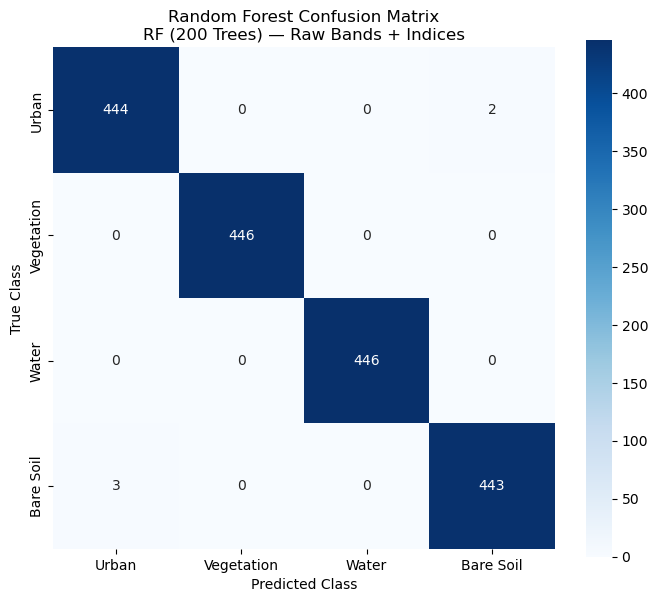

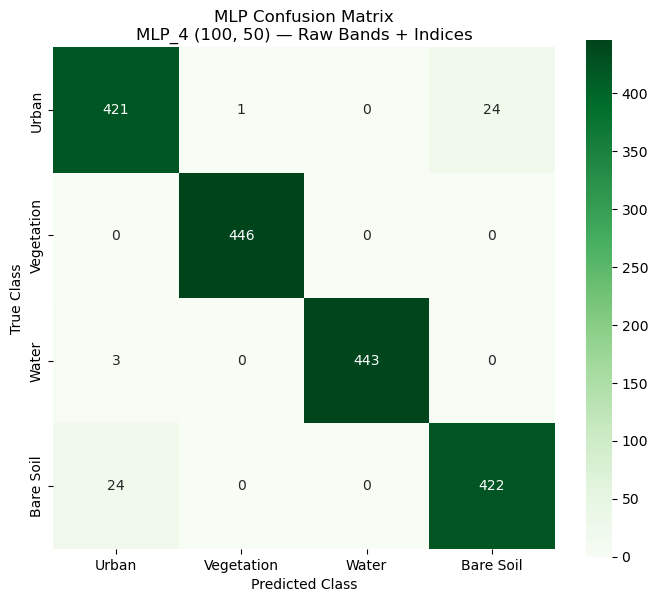


Confusion matrices created successfully.

Saved figures:
Random Forest:
C:\Users\Hp\Desktop\submissiongeo_final\Results\rf_confusion_matrix.png

MLP:
C:\Users\Hp\Desktop\submissiongeo_final\Results\mlp_confusion_matrix.png

Confusion matrices: SAVED


In [38]:
# ============================================================
# STEP 22 — PLOT AND SAVE CONFUSION MATRICES
# DYNAMICALLY USES THE CONFIGURATIONS SELECTED IN STEP 21
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 70)
print("STEP 22 — CONFUSION MATRICES")
print("=" * 70)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "PROJECT_DIR",
    "CLASS_MAP",
    "rf_confusion",
    "mlp_confusion",
    "rf_final",
    "rf_feature_set",
    "mlp_configuration_name",
    "mlp_hidden_layers",
    "mlp_feature_set",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        + "\n".join(missing_variables)
        + "\n\nRun Step 21 before Step 22."
    )


# ============================================================
# 2. CREATE RESULTS DIRECTORY
# ============================================================

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "Results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# 3. CLASS LABELS
# ============================================================

class_ids = sorted(
    CLASS_MAP.keys()
)

class_labels = [
    CLASS_MAP[class_id]
    for class_id in class_ids
]


# ============================================================
# 4. VALIDATE CONFUSION MATRICES
# ============================================================

expected_shape = (
    len(class_labels),
    len(class_labels)
)

if rf_confusion.shape != expected_shape:

    raise RuntimeError(
        "Random Forest confusion matrix has "
        "unexpected dimensions."
    )

if mlp_confusion.shape != expected_shape:

    raise RuntimeError(
        "MLP confusion matrix has "
        "unexpected dimensions."
    )


# ============================================================
# 5. DYNAMIC DISPLAY LABELS
# ============================================================

def format_feature_set(feature_set_name):

    feature_set_name = str(
        feature_set_name
    ).strip()

    display_names = {
        "Raw bands":
            "Raw Bands",

        "Raw bands + indices":
            "Raw Bands + Indices",
    }

    return display_names.get(
        feature_set_name,
        feature_set_name
    )


rf_feature_label = format_feature_set(
    rf_feature_set
)

mlp_feature_label = format_feature_set(
    mlp_feature_set
)


# Read the ACTUAL fitted RF configuration from Step 21.
rf_tree_count = int(
    rf_final.get_params().get(
        "n_estimators",
        200
    )
)


# Read the ACTUAL selected MLP architecture from Step 21.
mlp_layers_label = str(
    tuple(
        mlp_hidden_layers
    )
)


print(
    "\nConfigurations used for confusion matrices:"
)

print(
    f"Random Forest : {rf_tree_count} trees | "
    f"{rf_feature_set}"
)

print(
    f"MLP           : {mlp_configuration_name} "
    f"{mlp_layers_label} | {mlp_feature_set}"
)


# ============================================================
# 6. RANDOM FOREST CONFUSION MATRIX
# ============================================================

fig1, ax1 = plt.subplots(
    figsize=(7, 6)
)

sns.heatmap(
    rf_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=True,
    square=True,
    ax=ax1
)

ax1.set_title(
    "Random Forest Confusion Matrix\n"
    f"RF ({rf_tree_count} Trees) — "
    f"{rf_feature_label}"
)

ax1.set_xlabel(
    "Predicted Class"
)

ax1.set_ylabel(
    "True Class"
)

fig1.tight_layout()


rf_cm_path = os.path.join(
    RESULTS_DIR,
    "rf_confusion_matrix.png"
)

fig1.savefig(
    rf_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. MLP CONFUSION MATRIX
# ============================================================

fig2, ax2 = plt.subplots(
    figsize=(7, 6)
)

sns.heatmap(
    mlp_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=True,
    square=True,
    ax=ax2
)

ax2.set_title(
    "MLP Confusion Matrix\n"
    f"{mlp_configuration_name} "
    f"{mlp_layers_label} — "
    f"{mlp_feature_label}"
)

ax2.set_xlabel(
    "Predicted Class"
)

ax2.set_ylabel(
    "True Class"
)

fig2.tight_layout()


mlp_cm_path = os.path.join(
    RESULTS_DIR,
    "mlp_confusion_matrix.png"
)

fig2.savefig(
    mlp_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. FINAL OUTPUT
# ============================================================

print(
    "\nConfusion matrices created successfully."
)

print(
    "\nSaved figures:"
)

print(
    "Random Forest:"
)

print(
    rf_cm_path
)

print(
    "\nMLP:"
)

print(
    mlp_cm_path
)

print(
    "\n" + "=" * 70
)

print(
    "Confusion matrices: SAVED"
)

print(
    "=" * 70
)

## Step 23 — Full-Scene Classification with the Best-Performing Model

Retrain the best-performing classifier selected from the independent hold-out evaluation using its corresponding feature set, then classify all valid Sentinel-2 pixels in batches while preserving NoData and the original raster geometry.

In [39]:
# ============================================================
# STEP 23 — FINAL BEST-MODEL FULL-SCENE CLASSIFICATION
#
# - Reads the winning classifier from STEP 21
# - Reads the winning feature set automatically
# - Supports Random Forest OR MLP
# - Supports Raw bands OR Raw bands + indices
# - Retrains the selected model on the complete balanced
#   labelled dataset before production mapping
# - Predicts the complete Sentinel-2 scene in chunks
# - Saves a georeferenced GeoTIFF
# ============================================================

import ast
import gc
import numpy as np
import pandas as pd
import rasterio

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


print("=" * 75)
print("STEP 23 — FINAL BEST-MODEL FULL-SCENE CLASSIFICATION")
print("=" * 75)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

RESULTS_DIR = (
    Path(PROJECT_DIR)
    /
    "Results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FINAL_TIF = (
    RESULTS_DIR
    /
    "landcover_classification_best_model.tif"
)


AREA_CSV = (
    RESULTS_DIR
    /
    "landcover_area_summary.csv"
)


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "bands_stack",
    "X_raw_balanced",
    "X_all_balanced",
    "y_balanced",
    "CLASS_MAP",
    "B2_PATH",
    "RANDOM_STATE",
    "best_final_model",
    "best_mlp_summary",
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        +
        "\n".join(
            missing_variables
        )
        +
        "\n\nRun the previous preparation, "
        "cross-validation and final evaluation steps first."
    )


# ============================================================
# 3. READ WINNING MODEL FROM STEP 21
# ============================================================

SELECTED_MODEL = str(
    best_final_model[
        "Model"
    ]
).strip()


SELECTED_FEATURE_SET = str(
    best_final_model[
        "Feature Set"
    ]
).strip()


SELECTED_MACRO_F1 = float(
    best_final_model[
        "Macro F1"
    ]
)


SELECTED_ACCURACY = float(
    best_final_model[
        "Accuracy"
    ]
)


print(
    "\nModel selected from STEP 21:"
)

print(
    f"Model       : {SELECTED_MODEL}"
)

print(
    f"Feature set : {SELECTED_FEATURE_SET}"
)

print(
    f"Hold-out F1 : {SELECTED_MACRO_F1:.4f}"
)

print(
    f"Accuracy    : {SELECTED_ACCURACY:.4f}"
)


# ============================================================
# 4. VALIDATE MODEL NAME
# ============================================================

allowed_models = {
    "Random Forest",
    "MLP",
}


if SELECTED_MODEL not in allowed_models:

    raise RuntimeError(
        "Unexpected winning model from STEP 21:\n"
        f"{SELECTED_MODEL}"
    )


# ============================================================
# 5. VALIDATE FEATURE SET
# ============================================================

allowed_feature_sets = {
    "Raw bands",
    "Raw bands + indices",
}


if SELECTED_FEATURE_SET not in allowed_feature_sets:

    raise RuntimeError(
        "Unexpected winning feature set from STEP 21:\n"
        f"{SELECTED_FEATURE_SET}"
    )


# ============================================================
# 6. CHECK FULL-SCENE STACK
# ============================================================

if bands_stack.ndim != 3:

    raise RuntimeError(
        "bands_stack must be three-dimensional.\n"
        f"Current shape: {bands_stack.shape}"
    )


rows, cols, n_bands = (
    bands_stack.shape
)


if n_bands != 6:

    raise RuntimeError(
        "Expected six Sentinel-2 bands "
        "(B2, B3, B4, B8, B11, B12), "
        f"but found {n_bands}."
    )


print(
    "\nFull raster shape:"
)

print(
    bands_stack.shape
)


total_pixels = (
    rows
    *
    cols
)


print(
    f"\nTotal raster pixels: "
    f"{total_pixels:,}"
)


# ============================================================
# 7. FULL-SCENE VALID MASK
#
# Same definition used during data preparation:
# - all six bands finite
# - pixel is not zero in all six bands
# ============================================================

finite_mask_full = np.all(
    np.isfinite(
        bands_stack
    ),
    axis=-1
)


nonzero_mask_full = np.any(
    bands_stack != 0,
    axis=-1
)


valid_mask_full = (
    finite_mask_full
    &
    nonzero_mask_full
)


valid_pixels = int(
    np.count_nonzero(
        valid_mask_full
    )
)


invalid_pixels = (
    total_pixels
    -
    valid_pixels
)


valid_fraction = (
    valid_pixels
    /
    total_pixels
)


print(
    "\nValid-pixel check:"
)

print(
    f"Total pixels   : {total_pixels:,}"
)

print(
    f"Valid pixels   : {valid_pixels:,}"
)

print(
    f"Invalid pixels : {invalid_pixels:,}"
)

print(
    f"Valid fraction : {valid_fraction:.2%}"
)


if valid_pixels == 0:

    raise RuntimeError(
        "No valid Sentinel-2 pixels were found "
        "for full-scene classification."
    )


# ============================================================
# 8. SELECT COMPLETE BALANCED TRAINING DATA
#
# The feature representation MUST match the feature set
# selected during model evaluation.
# ============================================================

if SELECTED_FEATURE_SET == "Raw bands":

    X_final_training = (
        X_raw_balanced
    )

    expected_features = 6


elif SELECTED_FEATURE_SET == "Raw bands + indices":

    X_final_training = (
        X_all_balanced
    )

    expected_features = 9


y_final_training = (
    y_balanced
)


if (
    X_final_training.shape[0]
    !=
    y_final_training.shape[0]
):

    raise RuntimeError(
        "Final feature and label sample counts "
        "do not match."
    )


if (
    X_final_training.shape[1]
    !=
    expected_features
):

    raise RuntimeError(
        "Unexpected feature count in final "
        "training dataset.\n"
        f"Expected: {expected_features}\n"
        f"Found   : {X_final_training.shape[1]}"
    )


print(
    "\nFinal production-training dataset:"
)

print(
    f"X shape : {X_final_training.shape}"
)

print(
    f"y shape : {y_final_training.shape}"
)


# ============================================================
# 9. DISPLAY TRAINING BALANCE
# ============================================================

unique_classes, class_counts = (
    np.unique(
        y_final_training,
        return_counts=True
    )
)


print(
    "\nTraining samples per class:"
)


for class_id, count in zip(
    unique_classes,
    class_counts
):

    class_id = int(
        class_id
    )

    print(
        f"{class_id} - "
        f"{CLASS_MAP[class_id]:<10}: "
        f"{int(count):,}"
    )


# ============================================================
# 10. BUILD SELECTED PRODUCTION MODEL
# ============================================================

if SELECTED_MODEL == "Random Forest":

    print(
        "\nBuilding final Random Forest..."
    )

    final_map_model = (
        RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )


    FINAL_CONFIGURATION = (
        "Random Forest — 200 trees"
    )


# ------------------------------------------------------------
# MLP
# ------------------------------------------------------------

elif SELECTED_MODEL == "MLP":

    mlp_hidden_raw = (
        best_mlp_summary[
            "Hidden Layers"
        ]
    )


    if isinstance(
        mlp_hidden_raw,
        str
    ):

        mlp_hidden_layers = (
            ast.literal_eval(
                mlp_hidden_raw
            )
        )

    else:

        mlp_hidden_layers = tuple(
            mlp_hidden_raw
        )


    if isinstance(
        mlp_hidden_layers,
        int
    ):

        mlp_hidden_layers = (
            mlp_hidden_layers,
        )


    mlp_activation = str(
        best_mlp_summary[
            "Activation"
        ]
    ).lower()


    mlp_learning_rate = float(
        best_mlp_summary[
            "Learning Rate"
        ]
    )


    print(
        "\nBuilding final MLP..."
    )

    print(
        "Hidden layers :",
        mlp_hidden_layers
    )

    print(
        "Activation    :",
        mlp_activation
    )

    print(
        "Learning rate :",
        mlp_learning_rate
    )


    final_map_model = Pipeline(
        [

            (
                "scaler",

                StandardScaler()
            ),

            (
                "mlp",

                MLPClassifier(

                    hidden_layer_sizes=
                        mlp_hidden_layers,

                    activation=
                        mlp_activation,

                    learning_rate_init=
                        mlp_learning_rate,

                    max_iter=300,

                    early_stopping=True,

                    validation_fraction=0.10,

                    n_iter_no_change=15,

                    random_state=
                        RANDOM_STATE,
                )
            ),
        ]
    )


    FINAL_CONFIGURATION = (
        f"MLP — {mlp_hidden_layers} — "
        f"{mlp_activation} — "
        f"LR={mlp_learning_rate}"
    )


# ============================================================
# 11. TRAIN SELECTED MODEL ON COMPLETE BALANCED DATA
# ============================================================

print(
    "\nTraining selected production model..."
)

print(
    f"Model       : {SELECTED_MODEL}"
)

print(
    f"Feature set : {SELECTED_FEATURE_SET}"
)


final_map_model.fit(
    X_final_training,
    y_final_training
)


print(
    "Production model trained successfully."
)


# ============================================================
# 12. INITIALIZE FINAL CLASSIFICATION
#
# 0 = NoData
# 1–4 = land-cover classes
# ============================================================

full_map = np.zeros(
    (
        rows,
        cols
    ),
    dtype=np.uint8
)


valid_flat_indices = (
    np.flatnonzero(
        valid_mask_full.ravel()
    )
)


n_valid = len(
    valid_flat_indices
)


flat_stack = bands_stack.reshape(
    -1,
    6
)


full_map_flat = (
    full_map.ravel()
)


# ============================================================
# 13. CHUNKED FULL-SCENE PREDICTION
# ============================================================

CHUNK_SIZE = 1_000_000


print(
    "\nStarting full-scene prediction..."
)

print(
    f"Pixels to classify : {n_valid:,}"
)

print(
    f"Chunk size         : {CHUNK_SIZE:,}"
)


for start in range(
    0,
    n_valid,
    CHUNK_SIZE
):

    end = min(
        start
        +
        CHUNK_SIZE,
        n_valid
    )


    idx = (
        valid_flat_indices[
            start:end
        ]
    )


    # ========================================================
    # 14. RAW SIX-BAND CHUNK
    # ========================================================

    raw_chunk = (
        flat_stack[
            idx
        ]
        .astype(
            np.float32,
            copy=False
        )
    )


    # ========================================================
    # 15. BUILD FEATURE CHUNK
    #
    # Dynamically matches the feature set selected in STEP 21.
    # ========================================================

    if SELECTED_FEATURE_SET == "Raw bands":

        feature_chunk = (
            raw_chunk
        )


    else:

        b3 = raw_chunk[
            :,
            1
        ]

        b4 = raw_chunk[
            :,
            2
        ]

        b8 = raw_chunk[
            :,
            3
        ]

        b11 = raw_chunk[
            :,
            4
        ]


        epsilon = 1e-10


        ndvi = (
            b8
            -
            b4
        ) / (
            b8
            +
            b4
            +
            epsilon
        )


        ndwi = (
            b3
            -
            b8
        ) / (
            b3
            +
            b8
            +
            epsilon
        )


        ndbi = (
            b11
            -
            b8
        ) / (
            b11
            +
            b8
            +
            epsilon
        )


        feature_chunk = np.column_stack(
            [
                raw_chunk,
                ndvi,
                ndwi,
                ndbi,
            ]
        ).astype(
            np.float32,
            copy=False
        )


    # ========================================================
    # 16. FEATURE CONSISTENCY CHECK
    # ========================================================

    if (
        feature_chunk.shape[1]
        !=
        expected_features
    ):

        raise RuntimeError(
            "Feature mismatch during full-scene "
            "classification.\n"
            f"Expected: {expected_features}\n"
            f"Found   : {feature_chunk.shape[1]}"
        )


    if not np.all(
        np.isfinite(
            feature_chunk
        )
    ):

        raise RuntimeError(
            "Non-finite feature values were detected "
            "during full-scene classification."
        )


    # ========================================================
    # 17. PREDICT CURRENT CHUNK
    # ========================================================

    chunk_prediction = (
        final_map_model.predict(
            feature_chunk
        )
    )


    full_map_flat[
        idx
    ] = (
        chunk_prediction.astype(
            np.uint8
        )
    )


    print(
        f"Classified "
        f"{end:,} / {n_valid:,} pixels "
        f"({100 * end / n_valid:.1f}%)"
    )


# ============================================================
# 18. RETURN TO 2-D RASTER
# ============================================================

full_map = (
    full_map_flat.reshape(
        rows,
        cols
    )
)


# ============================================================
# 19. VALIDATE FINAL CLASSIFICATION
# ============================================================

predicted_values, predicted_counts = (
    np.unique(
        full_map,
        return_counts=True
    )
)


print(
    "\nFinal map class values:"
)


for value, count in zip(
    predicted_values,
    predicted_counts
):

    value = int(
        value
    )

    count = int(
        count
    )


    if value == 0:

        class_name = (
            "NoData"
        )

    else:

        class_name = (
            CLASS_MAP.get(
                value,
                str(value)
            )
        )


    print(
        f"{value} - "
        f"{class_name:<10}: "
        f"{count:,} pixels"
    )


allowed_values = {
    0,
    *CLASS_MAP.keys()
}


unexpected_values = (
    set(
        predicted_values.tolist()
    )
    -
    allowed_values
)


if unexpected_values:

    raise RuntimeError(
        "Unexpected classification values detected:\n"
        +
        str(
            sorted(
                unexpected_values
            )
        )
    )


classified_pixels = int(
    np.count_nonzero(
        full_map > 0
    )
)


if classified_pixels != valid_pixels:

    raise RuntimeError(
        "The number of classified pixels does not "
        "match the number of valid Sentinel-2 pixels.\n"
        f"Classified: {classified_pixels:,}\n"
        f"Expected  : {valid_pixels:,}"
    )


# ============================================================
# 20. REFERENCE RASTER
# ============================================================

reference_path = Path(
    B2_PATH
)


if not reference_path.exists():

    raise FileNotFoundError(
        "Reference B2 raster was not found:\n"
        f"{reference_path}"
    )


print(
    "\nReference raster:"
)

print(
    reference_path
)


# ============================================================
# 21. SAVE GEOREFERENCED CLASSIFICATION
# ============================================================

with rasterio.open(
    reference_path
) as src:

    profile = (
        src.profile.copy()
    )


    if (
        src.height != rows
        or
        src.width != cols
    ):

        raise RuntimeError(
            "Reference raster dimensions do not "
            "match the final classification.\n"
            f"Reference      : "
            f"{src.height} × {src.width}\n"
            f"Classification : "
            f"{rows} × {cols}"
        )


profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0,
    compress="lzw",
)


with rasterio.open(
    FINAL_TIF,
    "w",
    **profile
) as dst:

    dst.write(
        full_map,
        1
    )


print(
    "\nGeoTIFF saved successfully:"
)

print(
    FINAL_TIF
)


# ============================================================
# 22. VERIFY SAVED GEOTIFF
# ============================================================

with rasterio.open(
    FINAL_TIF
) as check:

    saved_map = (
        check.read(
            1
        )
    )


    print(
        "\nSaved GeoTIFF verification:"
    )

    print(
        f"Shape      : {saved_map.shape}"
    )

    print(
        f"CRS        : {check.crs}"
    )

    print(
        f"Resolution : {check.res}"
    )

    print(
        f"NoData     : {check.nodata}"
    )


saved_valid = (
    (saved_map >= 1)
    &
    (saved_map <= 4)
)


saved_classified_pixels = int(
    np.count_nonzero(
        saved_valid
    )
)


print(
    f"\nSaved classified pixels : "
    f"{saved_classified_pixels:,}"
)

print(
    f"Expected classified pixels: "
    f"{valid_pixels:,}"
)


if (
    saved_classified_pixels
    !=
    valid_pixels
):

    raise RuntimeError(
        "Saved GeoTIFF classified-pixel count "
        "does not match the valid-scene pixel count."
    )


# ============================================================
# 23. AREA SUMMARY
# ============================================================

with rasterio.open(
    FINAL_TIF
) as src:

    pixel_width = abs(
        src.transform.a
    )

    pixel_height = abs(
        src.transform.e
    )


pixel_area_m2 = (
    pixel_width
    *
    pixel_height
)


pixel_area_km2 = (
    pixel_area_m2
    /
    1_000_000
)


area_records = []


for class_id in sorted(
    CLASS_MAP.keys()
):

    count = int(
        np.count_nonzero(
            full_map
            ==
            class_id
        )
    )


    area_km2 = (
        count
        *
        pixel_area_km2
    )


    percentage = (
        100
        *
        count
        /
        valid_pixels
    )


    area_records.append(
        {

            "Class ID":
                class_id,

            "Class":
                CLASS_MAP[
                    class_id
                ],

            "Pixel Count":
                count,

            "Area km2":
                area_km2,

            "Percentage":
                percentage,
        }
    )


area_summary = pd.DataFrame(
    area_records
)


area_summary.to_csv(
    AREA_CSV,
    index=False
)


print(
    "\nLand-cover area summary:"
)


display(
    area_summary.style.format(
        {

            "Pixel Count":
                "{:,}",

            "Area km2":
                "{:.3f}",

            "Percentage":
                "{:.2f}%",
        }
    ).hide(
        axis="index"
    )
)


print(
    "\nArea summary saved:"
)

print(
    AREA_CSV
)


# ============================================================
# 24. AREA CHECK
# ============================================================

summary_pixel_total = int(
    area_summary[
        "Pixel Count"
    ].sum()
)


if summary_pixel_total != valid_pixels:

    raise RuntimeError(
        "Area-summary pixel total does not match "
        "the valid classified-pixel count."
    )


# ============================================================
# 25. SAVE FINAL MODEL METADATA
# ============================================================

MODEL_INFO_CSV = (
    RESULTS_DIR
    /
    "final_map_model_info.csv"
)


model_info = pd.DataFrame(
    [
        {

            "Selected Model":
                SELECTED_MODEL,

            "Configuration":
                FINAL_CONFIGURATION,

            "Feature Set":
                SELECTED_FEATURE_SET,

            "Hold-out Macro F1":
                SELECTED_MACRO_F1,

            "Hold-out Accuracy":
                SELECTED_ACCURACY,

            "Training Samples":
                len(
                    y_final_training
                ),

            "Scene Pixels Classified":
                valid_pixels,
        }
    ]
)


model_info.to_csv(
    MODEL_INFO_CSV,
    index=False
)


print(
    "\nFinal map model information saved:"
)

print(
    MODEL_INFO_CSV
)


# ============================================================
# 26. CLEAN MEMORY
# ============================================================

del flat_stack
del full_map_flat

gc.collect()


# ============================================================
# 27. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "STEP 23 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 75
)


print(
    "\nSelected production model:"
)

print(
    f"Model         : {SELECTED_MODEL}"
)

print(
    f"Configuration : {FINAL_CONFIGURATION}"
)

print(
    f"Feature set   : {SELECTED_FEATURE_SET}"
)


print(
    "\nFinal classified GeoTIFF:"
)

print(
    FINAL_TIF
)


print(
    "\nArea summary:"
)

print(
    AREA_CSV
)


print(
    "\nModel information:"
)

print(
    MODEL_INFO_CSV
)


print(
    f"\nClassified pixels: "
    f"{valid_pixels:,} / {total_pixels:,}"
)


print(
    "\nThe final land-cover map was generated "
    "using the better-performing model selected "
    "during the independent hold-out evaluation."
)

print(
    "=" * 75
)

STEP 23 — FINAL BEST-MODEL FULL-SCENE CLASSIFICATION

Model selected from STEP 21:
Model       : Random Forest
Feature set : Raw bands + indices
Hold-out F1 : 0.9972
Accuracy    : 0.9972

Full raster shape:
(10980, 10980, 6)

Total raster pixels: 120,560,400

Valid-pixel check:
Total pixels   : 120,560,400
Valid pixels   : 120,560,400
Invalid pixels : 0
Valid fraction : 100.00%

Final production-training dataset:
X shape : (8920, 9)
y shape : (8920,)

Training samples per class:
1 - Urban     : 2,230
2 - Vegetation: 2,230
3 - Water     : 2,230
4 - Bare Soil : 2,230

Building final Random Forest...

Training selected production model...
Model       : Random Forest
Feature set : Raw bands + indices
Production model trained successfully.

Starting full-scene prediction...
Pixels to classify : 120,560,400
Chunk size         : 1,000,000
Classified 1,000,000 / 120,560,400 pixels (0.8%)
Classified 2,000,000 / 120,560,400 pixels (1.7%)
Classified 3,000,000 / 120,560,400 pixels (2.5%)
Classifie

Class ID,Class,Pixel Count,Area km2,Percentage
1,Urban,"26,692,487",2669.249,22.14%
2,Vegetation,"82,688,766",8268.877,68.59%
3,Water,"3,286,667",328.667,2.73%
4,Bare Soil,"7,892,480",789.248,6.55%



Area summary saved:
C:\Users\Hp\Desktop\submissiongeo_final\Results\landcover_area_summary.csv

Final map model information saved:
C:\Users\Hp\Desktop\submissiongeo_final\Results\final_map_model_info.csv

STEP 23 COMPLETED SUCCESSFULLY

Selected production model:
Model         : Random Forest
Configuration : Random Forest — 200 trees
Feature set   : Raw bands + indices

Final classified GeoTIFF:
C:\Users\Hp\Desktop\submissiongeo_final\Results\landcover_classification_best_model.tif

Area summary:
C:\Users\Hp\Desktop\submissiongeo_final\Results\landcover_area_summary.csv

Model information:
C:\Users\Hp\Desktop\submissiongeo_final\Results\final_map_model_info.csv

Classified pixels: 120,560,400 / 120,560,400

The final land-cover map was generated using the better-performing model selected during the independent hold-out evaluation.


## Step 23B — Optional Cartographic Post-processing (Sieve Filter)

This step creates a cleaner **display-only** land-cover map by removing very small isolated regions. The original classification raster remains unchanged and is used for all accuracy assessment, confusion matrices, and quantitative area statistics.



ORIGINAL classification:
C:\Users\Hp\Desktop\submissiongeo_final\Results\landcover_classification_best_model.tif

Raster shape: (10980, 10980)
Original values: {1: 26692487, 2: 82688766, 3: 3286667, 4: 7892480}

Applying Sieve filter: < 8 pixels, connectivity=8

Changed pixels: 1,492,682
Valid classified pixels: 120,560,400
Percentage changed: 1.238%

Filtered DISPLAY raster saved:
C:\Users\Hp\Desktop\submissiongeo_final\Results\RF_landcover_sieved_display.tif


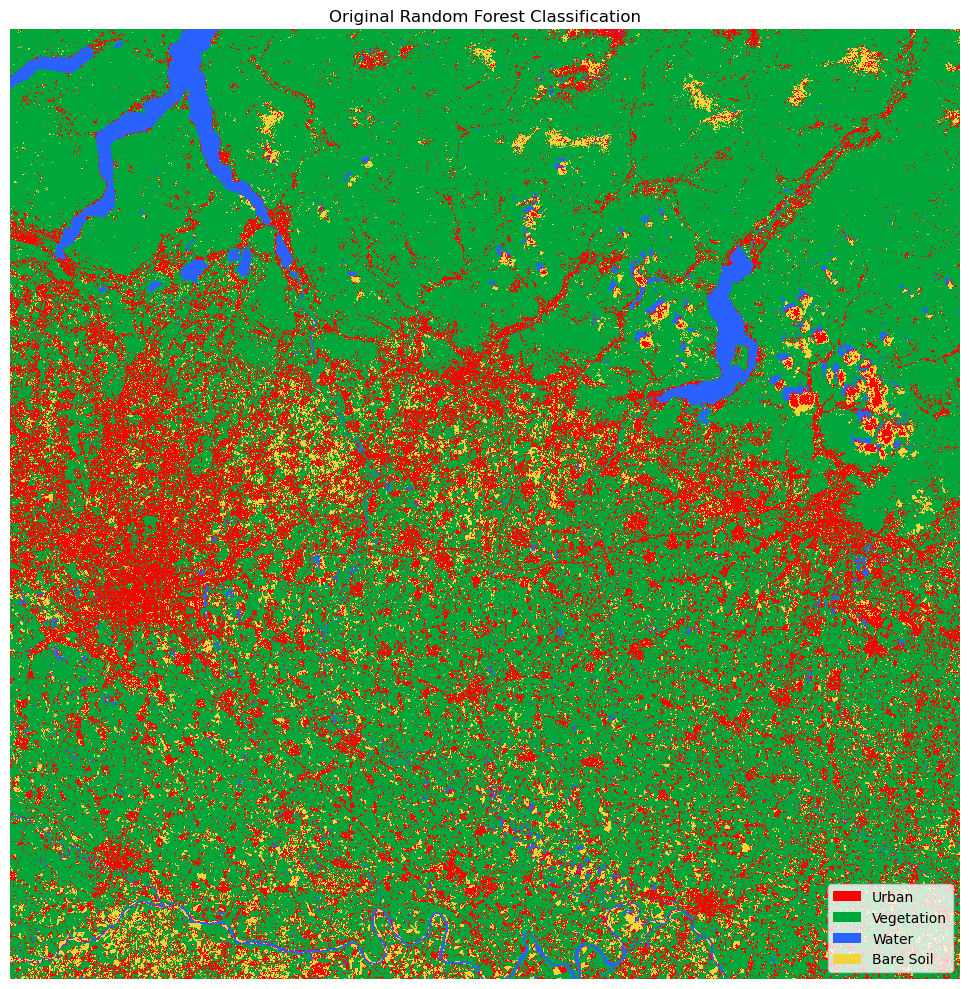

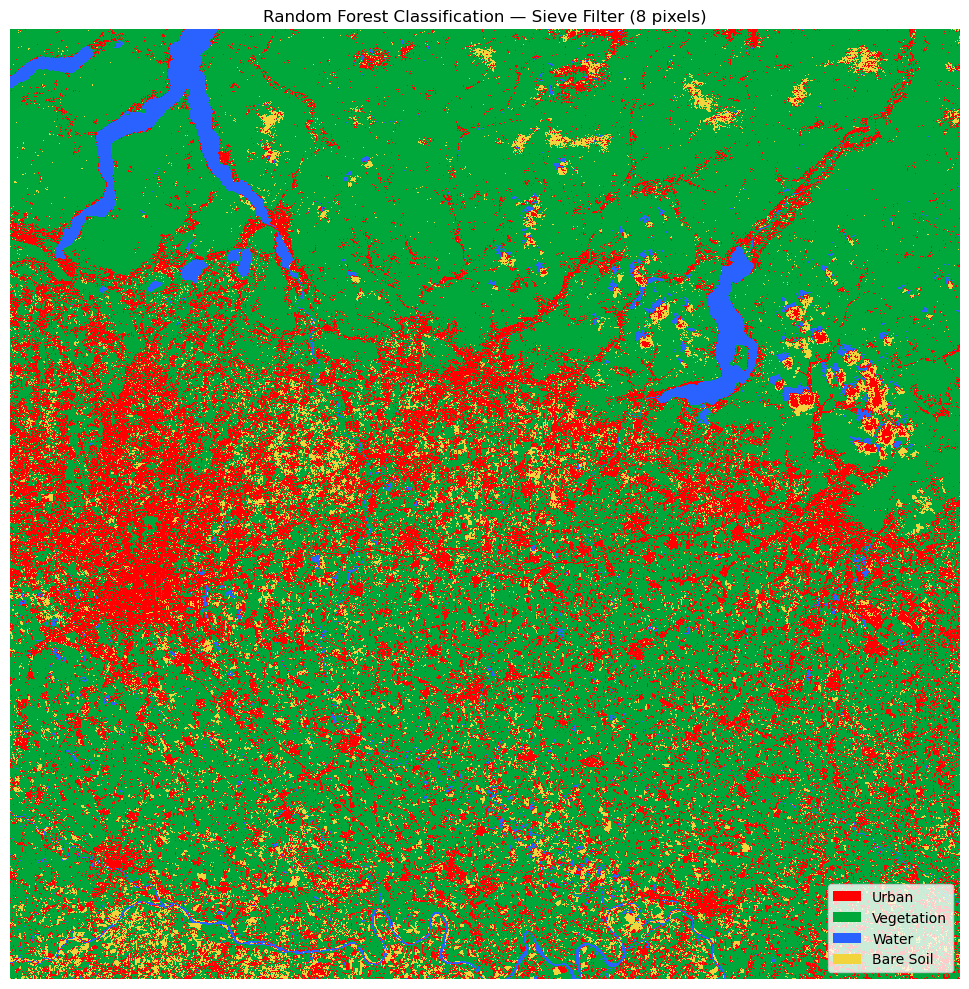


POST-PROCESSING COMPLETE

IMPORTANT:
Original raster was NOT modified.
Use the ORIGINAL classification for confusion matrix and accuracy metrics.
Use RF_landcover_sieved_display.tif / PNG only for cartographic presentation.

Sieve changed only 1.238% of valid classified pixels.


In [40]:
# ============================================================
# POST-PROCESSING — SIEVE FILTER
# DISPLAY / CARTOGRAPHIC VERSION ONLY
#
# IMPORTANT:
# - The original classification remains unchanged.
# - Accuracy assessment must use the ORIGINAL raster.
# - This filtered raster is only for the final map / report.
# ============================================================

from pathlib import Path

import numpy as np
import rasterio
from rasterio.features import sieve

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# ============================================================
# 1. SETTINGS
# ============================================================

SIEVE_SIZE = 8          # remove isolated regions < 8 pixels
CONNECTIVITY = 8        # consider diagonal neighbours too

RESULTS_DIR = Path(PROJECT_DIR) / "Results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. FIND THE ORIGINAL RF CLASSIFICATION
# ============================================================

possible_variable_names = [
    "RF_CLASSIFIED_PATH",
    "RF_CLASSIFIED_TIF",
    "RF_CLASSIFICATION_PATH",
    "CLASSIFIED_RF_PATH",
    "CLASSIFIED_TIF",
    "CLASSIFIED_RASTER_PATH",
]


raw_classification_path = None


for variable_name in possible_variable_names:

    if variable_name in globals():

        possible_path = Path(
            globals()[variable_name]
        )

        if possible_path.exists():

            raw_classification_path = possible_path

            print(
                f"Using classification from variable "
                f"{variable_name}:"
            )

            print(
                raw_classification_path
            )

            break


# ------------------------------------------------------------
# If no known variable is available, search Results/
# ------------------------------------------------------------

if raw_classification_path is None:

    tif_candidates = [

        path

        for path in RESULTS_DIR.glob("*.tif")

        if (
            "class" in path.name.lower()
            and
            "sieve" not in path.name.lower()
            and
            "filtered" not in path.name.lower()
            and
            "smooth" not in path.name.lower()
        )
    ]


    rf_candidates = [

        path

        for path in tif_candidates

        if "rf" in path.name.lower()
    ]


    if len(rf_candidates) == 1:

        raw_classification_path = rf_candidates[0]

    elif len(tif_candidates) == 1:

        raw_classification_path = tif_candidates[0]

    else:

        print("\nClassification candidates found:")

        for path in tif_candidates:
            print(" -", path)

        raise RuntimeError(
            "\nCould not identify the RF classification "
            "automatically.\n"
            "Set raw_classification_path manually to the "
            "original Random Forest classified GeoTIFF."
        )


print(
    "\nORIGINAL classification:"
)

print(
    raw_classification_path
)


# ============================================================
# 3. READ ORIGINAL CLASSIFICATION
# ============================================================

with rasterio.open(
    raw_classification_path
) as src:

    raw_classification = src.read(1)

    profile = src.profile.copy()

    nodata_value = src.nodata


print(
    "\nRaster shape:",
    raw_classification.shape
)


unique_values, counts = np.unique(
    raw_classification,
    return_counts=True
)


print(
    "Original values:",
    dict(
        zip(
            unique_values.tolist(),
            counts.tolist()
        )
    )
)


# ============================================================
# 4. CREATE VALID-DATA MASK
# ============================================================

if nodata_value is not None:

    valid_mask = (
        raw_classification
        !=
        nodata_value
    )

else:

    # Classes are 1–4 in this project.
    # Zero is treated as background / NoData.
    valid_mask = (
        raw_classification > 0
    )


# ============================================================
# 5. APPLY SIEVE
# ============================================================

print(
    f"\nApplying Sieve filter: "
    f"< {SIEVE_SIZE} pixels, "
    f"connectivity={CONNECTIVITY}"
)


filtered_classification = sieve(

    raw_classification,

    size=SIEVE_SIZE,

    mask=valid_mask,

    connectivity=CONNECTIVITY,
)


# Preserve NoData exactly.
filtered_classification[
    ~valid_mask
] = raw_classification[
    ~valid_mask
]


# ============================================================
# 6. CALCULATE HOW MUCH CHANGED
# ============================================================

changed_mask = (
    valid_mask
    &
    (
        filtered_classification
        !=
        raw_classification
    )
)


changed_pixels = int(
    np.count_nonzero(
        changed_mask
    )
)


valid_pixels = int(
    np.count_nonzero(
        valid_mask
    )
)


changed_percentage = (

    changed_pixels
    /
    valid_pixels
    *
    100

    if valid_pixels > 0
    else 0.0
)


print(
    "\nChanged pixels:",
    f"{changed_pixels:,}"
)


print(
    "Valid classified pixels:",
    f"{valid_pixels:,}"
)


print(
    "Percentage changed:",
    f"{changed_percentage:.3f}%"
)


# ============================================================
# 7. SAVE FILTERED DISPLAY RASTER
# ============================================================

filtered_tif = (
    RESULTS_DIR
    /
    "RF_landcover_sieved_display.tif"
)


profile.update(
    compress="deflate",
)


with rasterio.open(
    filtered_tif,
    "w",
    **profile,
) as dst:

    dst.write(
        filtered_classification,
        1
    )


print(
    "\nFiltered DISPLAY raster saved:"
)

print(
    filtered_tif
)


# ============================================================
# 8. CREATE BEFORE / AFTER COMPARISON
# ============================================================

# Project classes:
# 1 = Urban
# 2 = Vegetation
# 3 = Water
# 4 = Bare Soil

class_colors = [
    "#ff0000",   # Urban
    "#00a83b",   # Vegetation
    "#2962ff",   # Water
    "#f2d43d",   # Bare Soil
]


class_cmap = ListedColormap(
    class_colors
)


# Convert classes 1–4 to display indices 0–3.
raw_display = np.ma.masked_where(
    ~valid_mask,
    raw_classification - 1
)


filtered_display = np.ma.masked_where(
    ~valid_mask,
    filtered_classification - 1
)


legend_items = [

    Patch(
        facecolor="#ff0000",
        label="Urban"
    ),

    Patch(
        facecolor="#00a83b",
        label="Vegetation"
    ),

    Patch(
        facecolor="#2962ff",
        label="Water"
    ),

    Patch(
        facecolor="#f2d43d",
        label="Bare Soil"
    ),
]


# ------------------------------------------------------------
# Original
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 10)
)

plt.imshow(
    raw_display,
    cmap=class_cmap,
    vmin=0,
    vmax=3,
    interpolation="nearest",
)

plt.title(
    "Original Random Forest Classification"
)

plt.axis(
    "off"
)

plt.legend(
    handles=legend_items,
    loc="lower right",
    frameon=True,
)

plt.tight_layout()

original_png = (
    RESULTS_DIR
    /
    "RF_landcover_original.png"
)

plt.savefig(
    original_png,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Filtered
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 10)
)

plt.imshow(
    filtered_display,
    cmap=class_cmap,
    vmin=0,
    vmax=3,
    interpolation="nearest",
)

plt.title(
    f"Random Forest Classification — "
    f"Sieve Filter ({SIEVE_SIZE} pixels)"
)

plt.axis(
    "off"
)

plt.legend(
    handles=legend_items,
    loc="lower right",
    frameon=True,
)

plt.tight_layout()

filtered_png = (
    RESULTS_DIR
    /
    "RF_landcover_sieved_display.png"
)

plt.savefig(
    filtered_png,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 9. FINAL MESSAGE
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "POST-PROCESSING COMPLETE"
)

print(
    "=" * 70
)

print(
    "\nIMPORTANT:"
)

print(
    "Original raster was NOT modified."
)

print(
    "Use the ORIGINAL classification for "
    "confusion matrix and accuracy metrics."
)

print(
    "Use RF_landcover_sieved_display.tif / PNG "
    "only for cartographic presentation."
)

print(
    f"\nSieve changed only "
    f"{changed_percentage:.3f}% "
    "of valid classified pixels."
)

## Step 24 — Create Final Model Comparison Table
Summarize held-out accuracy, macro F1, cross-validation accuracy, and runtime for the selected models.


In [42]:
# ============================================================
# STEP 24 — CREATE FINAL MODEL COMPARISON TABLE
# CONSISTENT WITH STEP 21 AND STEP 23
# ============================================================

from pathlib import Path
import pandas as pd


print("=" * 75)
print("STEP 24 — FINAL MODEL COMPARISON")
print("=" * 75)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "final_results_df",
    "best_final_model",
    "SELECTED_MODEL",
    "SELECTED_FEATURE_SET",
    "PROJECT_DIR",
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        +
        "\n".join(
            missing_variables
        )
        +
        "\n\nRun STEP 21 and STEP 23 before STEP 24."
    )


# ============================================================
# 2. COPY FINAL RESULTS FROM STEP 21
#
# STEP 21 already contains:
# - CV-selected best RF
# - CV-selected best MLP
# - independent hold-out performance
#
# Therefore STEP 24 should summarize those results rather
# than independently selecting configurations again.
# ============================================================

comparison_source = (
    final_results_df
    .copy()
)


# ============================================================
# 3. RENAME COLUMNS FOR FINAL REPORTING
# ============================================================

rename_map = {

    "Feature Set":
        "Best Feature Set",

    "CV Mean F1":
        "Mean CV F1",

    "CV Std F1":
        "Std CV F1",

    "Accuracy":
        "Test Accuracy",

    "Macro Precision":
        "Test Macro Precision",

    "Macro Recall":
        "Test Macro Recall",

    "Macro F1":
        "Test Macro F1",

    "Cohen Kappa":
        "Test Cohen Kappa",

    "Training + Prediction Time (s)":
        "Final Training + Prediction Time (s)",
}


final_comparison_df = (
    comparison_source
    .rename(
        columns=rename_map
    )
)


# ============================================================
# 4. ADD CV ACCURACY AND CV TIME
#
# These values come from the original CV result tables.
# ============================================================

cv_accuracy_values = []
cv_accuracy_std_values = []
cv_time_values = []


for _, row in final_comparison_df.iterrows():

    model_name = str(
        row[
            "Model"
        ]
    )


    configuration_name = str(
        row[
            "Configuration"
        ]
    )


    feature_set = str(
        row[
            "Best Feature Set"
        ]
    )


    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    if model_name == "Random Forest":

        matching_rows = (
            rf_results_df[
                rf_results_df[
                    "Feature Set"
                ]
                ==
                feature_set
            ]
        )


        if len(
            matching_rows
        ) == 0:

            raise RuntimeError(
                "Could not match the selected Random Forest "
                "configuration to rf_results_df."
            )


        best_match = (
            matching_rows
            .sort_values(
                by=[
                    "Mean CV F1",
                    "Mean CV Accuracy",
                ],
                ascending=[
                    False,
                    False,
                ],
            )
            .iloc[0]
        )


    # --------------------------------------------------------
    # MLP
    # --------------------------------------------------------

    elif model_name == "MLP":

        matching_rows = (
            mlp_results_df[
                (
                    mlp_results_df[
                        "Model"
                    ]
                    ==
                    configuration_name
                )
                &
                (
                    mlp_results_df[
                        "Feature Set"
                    ]
                    ==
                    feature_set
                )
            ]
        )


        if len(
            matching_rows
        ) == 0:

            raise RuntimeError(
                "Could not match the selected MLP "
                "configuration to mlp_results_df."
            )


        best_match = (
            matching_rows
            .sort_values(
                by=[
                    "Mean CV F1",
                    "Mean CV Accuracy",
                ],
                ascending=[
                    False,
                    False,
                ],
            )
            .iloc[0]
        )


    else:

        raise RuntimeError(
            "Unexpected model in final_results_df:\n"
            f"{model_name}"
        )


    cv_accuracy_values.append(
        float(
            best_match[
                "Mean CV Accuracy"
            ]
        )
    )


    cv_accuracy_std_values.append(
        float(
            best_match[
                "Std CV Accuracy"
            ]
        )
    )


    cv_time_values.append(
        float(
            best_match[
                "CV Time (s)"
            ]
        )
    )


final_comparison_df[
    "Mean CV Accuracy"
] = cv_accuracy_values


final_comparison_df[
    "Std CV Accuracy"
] = cv_accuracy_std_values


final_comparison_df[
    "CV Time (s)"
] = cv_time_values


# ============================================================
# 5. ORDER COLUMNS
# ============================================================

ordered_columns = [

    "Model",

    "Configuration",

    "Best Feature Set",

    "Mean CV Accuracy",

    "Std CV Accuracy",

    "Mean CV F1",

    "Std CV F1",

    "Test Accuracy",

    "Test Macro Precision",

    "Test Macro Recall",

    "Test Macro F1",

    "Test Cohen Kappa",

    "CV Time (s)",

    "Final Training + Prediction Time (s)",
]


final_comparison_df = (
    final_comparison_df[
        ordered_columns
    ]
)


# ============================================================
# 6. FINAL RANKING
#
# The independent hold-out test determines the final rank.
# ============================================================

final_comparison_df = (
    final_comparison_df
    .sort_values(
        by=[
            "Test Macro F1",
            "Test Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)


final_comparison_df.insert(
    0,
    "Rank",
    range(
        1,
        len(
            final_comparison_df
        )
        +
        1
    ),
)


# ============================================================
# 7. VALIDATE METRICS
# ============================================================

required_metric_columns = [

    "Mean CV Accuracy",

    "Std CV Accuracy",

    "Mean CV F1",

    "Std CV F1",

    "Test Accuracy",

    "Test Macro Precision",

    "Test Macro Recall",

    "Test Macro F1",

    "Test Cohen Kappa",

    "CV Time (s)",

    "Final Training + Prediction Time (s)",
]


if (
    final_comparison_df[
        required_metric_columns
    ]
    .isna()
    .any()
    .any()
):

    raise RuntimeError(
        "Missing values were detected in the "
        "final model comparison table."
    )


# ============================================================
# 8. IDENTIFY FINAL BEST MODEL
# ============================================================

best_model_row = (
    final_comparison_df
    .iloc[0]
)


FINAL_BEST_MODEL = str(
    best_model_row[
        "Model"
    ]
)


FINAL_BEST_FEATURE_SET = str(
    best_model_row[
        "Best Feature Set"
    ]
)


# ============================================================
# 9. CONSISTENCY CHECK WITH STEP 23
#
# The model ranked first here MUST match the model used
# to generate the final classified map in STEP 23.
# ============================================================

if (
    FINAL_BEST_MODEL
    !=
    SELECTED_MODEL
):

    raise RuntimeError(
        "Final model inconsistency detected.\n"
        f"STEP 24 best model : {FINAL_BEST_MODEL}\n"
        f"STEP 23 map model  : {SELECTED_MODEL}"
    )


if (
    FINAL_BEST_FEATURE_SET
    !=
    SELECTED_FEATURE_SET
):

    raise RuntimeError(
        "Final feature-set inconsistency detected.\n"
        f"STEP 24 best feature set : "
        f"{FINAL_BEST_FEATURE_SET}\n"
        f"STEP 23 map feature set  : "
        f"{SELECTED_FEATURE_SET}"
    )


# ============================================================
# 10. DISPLAY FINAL COMPARISON
# ============================================================

print(
    "\nFinal model comparison:"
)


display(

    final_comparison_df
    .style
    .format(
        {

            "Mean CV Accuracy":
                "{:.4f}",

            "Std CV Accuracy":
                "{:.4f}",

            "Mean CV F1":
                "{:.4f}",

            "Std CV F1":
                "{:.4f}",

            "Test Accuracy":
                "{:.4f}",

            "Test Macro Precision":
                "{:.4f}",

            "Test Macro Recall":
                "{:.4f}",

            "Test Macro F1":
                "{:.4f}",

            "Test Cohen Kappa":
                "{:.4f}",

            "CV Time (s)":
                "{:.2f}",

            "Final Training + Prediction Time (s)":
                "{:.2f}",
        }
    )
    .hide(
        axis="index"
    )
)


# ============================================================
# 11. PRINT FINAL WINNER
# ============================================================

print(
    "\nBest final model:"
)

print(
    f"Model         : "
    f"{FINAL_BEST_MODEL}"
)

print(
    f"Configuration : "
    f"{best_model_row['Configuration']}"
)

print(
    f"Feature set   : "
    f"{FINAL_BEST_FEATURE_SET}"
)

print(
    f"CV F1         : "
    f"{best_model_row['Mean CV F1']:.4f} "
    f"± "
    f"{best_model_row['Std CV F1']:.4f}"
)

print(
    f"Test F1       : "
    f"{best_model_row['Test Macro F1']:.4f}"
)

print(
    f"Test Accuracy : "
    f"{best_model_row['Test Accuracy']:.4f}"
)

print(
    f"Kappa         : "
    f"{best_model_row['Test Cohen Kappa']:.4f}"
)


# ============================================================
# 12. EXPORT RESULTS
# ============================================================

FINAL_COMPARISON_PATH = (
    Path(PROJECT_DIR)
    /
    "Results"
    /
    "final_model_comparison.csv"
)


FINAL_COMPARISON_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)


final_comparison_df.to_csv(
    FINAL_COMPARISON_PATH,
    index=False
)


print(
    "\nFinal comparison saved to:"
)

print(
    FINAL_COMPARISON_PATH
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "Final model comparison: COMPLETED AND EXPORTED"
)

print(
    "STEP 23 / STEP 24 model consistency: PASSED"
)

print(
    "=" * 75
)

STEP 24 — FINAL MODEL COMPARISON

Final model comparison:


Rank,Model,Configuration,Best Feature Set,Mean CV Accuracy,Std CV Accuracy,Mean CV F1,Std CV F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Cohen Kappa,CV Time (s),Final Training + Prediction Time (s)
1,Random Forest,RF_200_trees,Raw bands + indices,0.9969,0.0008,0.9969,0.0008,0.9972,0.9972,0.9972,0.9972,0.9963,20.53,1.23
2,MLP,MLP_4,Raw bands + indices,0.9950,0.0010,0.9950,0.0010,0.9709,0.9709,0.9709,0.9709,0.9611,11.45,2.60



Best final model:
Model         : Random Forest
Configuration : RF_200_trees
Feature set   : Raw bands + indices
CV F1         : 0.9969 ± 0.0008
Test F1       : 0.9972
Test Accuracy : 0.9972
Kappa         : 0.9963

Final comparison saved to:
C:\Users\Hp\Desktop\submissiongeo_final\Results\final_model_comparison.csv

Final model comparison: COMPLETED AND EXPORTED
STEP 23 / STEP 24 model consistency: PASSED


## Step 25 — Plot Model-Comparison Figures
Create and save the final RF-versus-MLP and feature-engineering comparison figures.


STEP 25 — MODEL-COMPARISON FIGURES


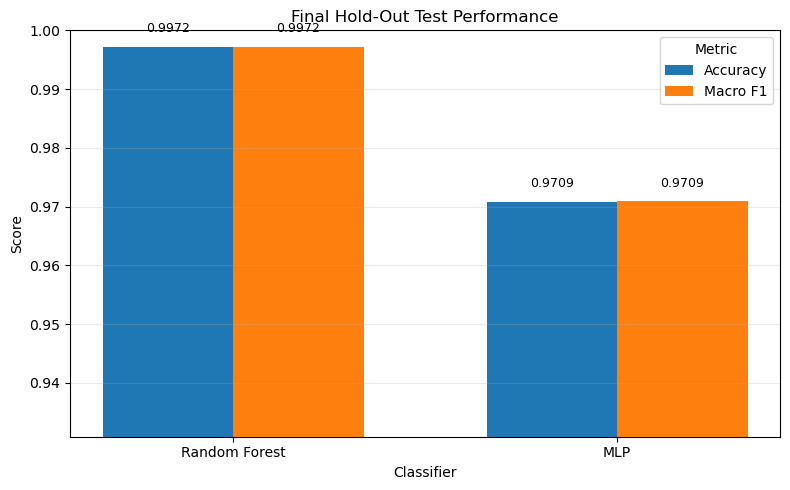


CV-selected MLP used for feature-engineering comparison:
MLP_4

Feature-engineering comparison:


,Model,Feature Set,Mean CV F1
0,Random Forest,Raw bands,0.996918
1,Random Forest,Raw bands + indices,0.996918
2,MLP_4,Raw bands + indices,0.994957
3,MLP_4,Raw bands,0.991309


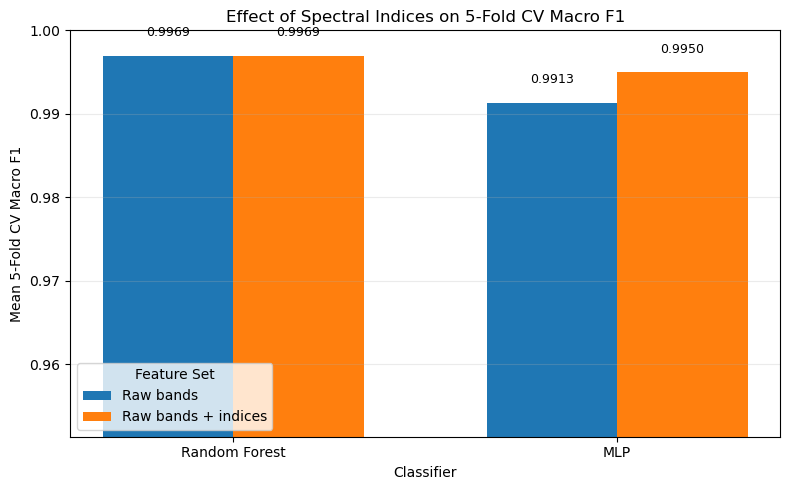


Effect of spectral indices:


Model,Raw Bands Mean CV F1,Raw Bands + Indices Mean CV F1,F1 Difference
Random Forest,0.9969,0.9969,+0.0000
MLP,0.9913,0.9950,+0.0036



Feature-engineering interpretation:
- Random Forest: indices improved mean CV Macro F1 by +0.0000.
- MLP: indices improved mean CV Macro F1 by +0.0036.

Figures saved successfully:
C:\Users\Hp\Desktop\submissiongeo_final\Results\final_test_performance_rf_vs_mlp.png
C:\Users\Hp\Desktop\submissiongeo_final\Results\spectral_indices_f1_comparison.png

Feature-comparison tables saved:
C:\Users\Hp\Desktop\submissiongeo_final\Results\feature_engineering_comparison.csv
C:\Users\Hp\Desktop\submissiongeo_final\Results\feature_engineering_summary.csv

STEP 25 COMPLETED SUCCESSFULLY


In [43]:
# ============================================================
# STEP 25 — PLOT MODEL-COMPARISON FIGURES
# CONSISTENT WITH FINAL CV / HOLD-OUT MODEL SELECTION
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 75)
print("STEP 25 — MODEL-COMPARISON FIGURES")
print("=" * 75)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "PROJECT_DIR",
    "final_comparison_df",
    "rf_results_df",
    "mlp_results_df",
    "best_mlp_summary",
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        +
        "\n".join(
            missing_variables
        )
        +
        "\n\nRun the previous model-selection "
        "and evaluation steps first."
    )


# ============================================================
# 2. RESULTS DIRECTORY
# ============================================================

RESULTS_DIR = (
    Path(PROJECT_DIR)
    /
    "Results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. FIGURE 1 — FINAL HOLD-OUT TEST PERFORMANCE
#
# Compare the CV-selected best RF and best MLP using:
# - independent hold-out Accuracy
# - independent hold-out Macro F1
# ============================================================

test_plot_df = (
    final_comparison_df[
        [
            "Model",
            "Configuration",
            "Best Feature Set",
            "Test Accuracy",
            "Test Macro F1",
        ]
    ]
    .copy()
)


models = (
    test_plot_df[
        "Model"
    ]
    .tolist()
)


test_accuracies = (
    test_plot_df[
        "Test Accuracy"
    ]
    .astype(float)
    .to_numpy()
)


test_f1_scores = (
    test_plot_df[
        "Test Macro F1"
    ]
    .astype(float)
    .to_numpy()
)


x = np.arange(
    len(models)
)


bar_width = 0.34


fig1, ax1 = plt.subplots(
    figsize=(8, 5)
)


bars_accuracy = ax1.bar(
    x - bar_width / 2,
    test_accuracies,
    bar_width,
    label="Accuracy",
)


bars_f1 = ax1.bar(
    x + bar_width / 2,
    test_f1_scores,
    bar_width,
    label="Macro F1",
)


all_test_scores = np.concatenate(
    [
        test_accuracies,
        test_f1_scores,
    ]
)


test_y_min = max(
    0.0,
    float(
        all_test_scores.min()
    )
    -
    0.04
)


test_y_max = min(
    1.0,
    float(
        all_test_scores.max()
    )
    +
    0.04
)


ax1.set_ylim(
    test_y_min,
    test_y_max
)


ax1.set_title(
    "Final Hold-Out Test Performance"
)


ax1.set_ylabel(
    "Score"
)


ax1.set_xlabel(
    "Classifier"
)


ax1.set_xticks(
    x
)


ax1.set_xticklabels(
    models
)


ax1.legend(
    title="Metric"
)


ax1.grid(
    axis="y",
    alpha=0.25
)


for bars in [
    bars_accuracy,
    bars_f1,
]:

    for bar in bars:

        value = (
            bar.get_height()
        )

        ax1.text(
            bar.get_x()
            +
            bar.get_width() / 2,
            value + 0.002,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


fig1.tight_layout()


test_performance_path = (
    RESULTS_DIR
    /
    "final_test_performance_rf_vs_mlp.png"
)


fig1.savefig(
    test_performance_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 4. IDENTIFY CV-SELECTED MLP ARCHITECTURE
#
# Use the same MLP selected earlier — do not independently
# choose another architecture here.
# ============================================================

best_mlp_model = str(
    best_mlp_summary[
        "Configuration"
    ]
)


print(
    "\nCV-selected MLP used for feature-engineering comparison:"
)

print(
    best_mlp_model
)


# ============================================================
# 5. RANDOM FOREST FEATURE-ENGINEERING RESULTS
# ============================================================

rf_plot_df = (
    rf_results_df[
        [
            "Model",
            "Feature Set",
            "Mean CV F1",
        ]
    ]
    .copy()
)


# ============================================================
# 6. SELECTED MLP FEATURE-ENGINEERING RESULTS
# ============================================================

mlp_plot_df = (
    mlp_results_df[
        mlp_results_df[
            "Model"
        ]
        ==
        best_mlp_model
    ]
    [
        [
            "Model",
            "Feature Set",
            "Mean CV F1",
        ]
    ]
    .copy()
)


if len(
    mlp_plot_df
) == 0:

    raise RuntimeError(
        "The CV-selected MLP configuration "
        "could not be found in mlp_results_df."
    )


# ============================================================
# 7. COMBINE RF + SELECTED MLP
# ============================================================

feature_comparison_df = pd.concat(
    [
        rf_plot_df,
        mlp_plot_df,
    ],
    ignore_index=True,
)


print(
    "\nFeature-engineering comparison:"
)


display(
    feature_comparison_df
)


# ============================================================
# 8. PREPARE GROUPED-BAR DATA
# ============================================================

classifier_order = [
    "Random Forest",
    best_mlp_model,
]


display_names = [
    "Random Forest",
    "MLP",
]


raw_scores = []

index_scores = []


for model_name in classifier_order:

    model_rows = (
        feature_comparison_df[
            feature_comparison_df[
                "Model"
            ]
            ==
            model_name
        ]
    )


    raw_row = (
        model_rows[
            model_rows[
                "Feature Set"
            ]
            ==
            "Raw bands"
        ]
    )


    index_row = (
        model_rows[
            model_rows[
                "Feature Set"
            ]
            ==
            "Raw bands + indices"
        ]
    )


    if (
        len(raw_row) == 0
        or
        len(index_row) == 0
    ):

        raise RuntimeError(
            f"Missing raw/index feature-set "
            f"comparison for {model_name}."
        )


    raw_scores.append(
        float(
            raw_row[
                "Mean CV F1"
            ].iloc[0]
        )
    )


    index_scores.append(
        float(
            index_row[
                "Mean CV F1"
            ].iloc[0]
        )
    )


raw_scores = np.array(
    raw_scores
)


index_scores = np.array(
    index_scores
)


# ============================================================
# 9. FIGURE 2 — EFFECT OF SPECTRAL INDICES
# ============================================================

x = np.arange(
    len(
        classifier_order
    )
)


bar_width = 0.34


fig2, ax2 = plt.subplots(
    figsize=(8, 5)
)


bars_raw = ax2.bar(
    x - bar_width / 2,
    raw_scores,
    bar_width,
    label="Raw bands",
)


bars_indices = ax2.bar(
    x + bar_width / 2,
    index_scores,
    bar_width,
    label="Raw bands + indices",
)


all_cv_scores = np.concatenate(
    [
        raw_scores,
        index_scores,
    ]
)


cv_y_min = max(
    0.0,
    float(
        all_cv_scores.min()
    )
    -
    0.04
)


cv_y_max = min(
    1.0,
    float(
        all_cv_scores.max()
    )
    +
    0.04
)


ax2.set_ylim(
    cv_y_min,
    cv_y_max
)


ax2.set_title(
    "Effect of Spectral Indices on 5-Fold CV Macro F1"
)


ax2.set_ylabel(
    "Mean 5-Fold CV Macro F1"
)


ax2.set_xlabel(
    "Classifier"
)


ax2.set_xticks(
    x
)


ax2.set_xticklabels(
    display_names
)


ax2.legend(
    title="Feature Set"
)


ax2.grid(
    axis="y",
    alpha=0.25
)


for bars in [
    bars_raw,
    bars_indices,
]:

    for bar in bars:

        value = (
            bar.get_height()
        )

        ax2.text(
            bar.get_x()
            +
            bar.get_width() / 2,
            value + 0.002,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


fig2.tight_layout()


feature_plot_path = (
    RESULTS_DIR
    /
    "spectral_indices_f1_comparison.png"
)


fig2.savefig(
    feature_plot_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 10. FEATURE-ENGINEERING SUMMARY TABLE
# ============================================================

feature_summary_records = []


for model_name, display_name in zip(
    classifier_order,
    display_names,
):

    raw_score = float(
        feature_comparison_df[
            (
                feature_comparison_df[
                    "Model"
                ]
                ==
                model_name
            )
            &
            (
                feature_comparison_df[
                    "Feature Set"
                ]
                ==
                "Raw bands"
            )
        ][
            "Mean CV F1"
        ].iloc[0]
    )


    indices_score = float(
        feature_comparison_df[
            (
                feature_comparison_df[
                    "Model"
                ]
                ==
                model_name
            )
            &
            (
                feature_comparison_df[
                    "Feature Set"
                ]
                ==
                "Raw bands + indices"
            )
        ][
            "Mean CV F1"
        ].iloc[0]
    )


    feature_summary_records.append(
        {

            "Model":
                display_name,

            "Raw Bands Mean CV F1":
                raw_score,

            "Raw Bands + Indices Mean CV F1":
                indices_score,

            "F1 Difference":
                indices_score
                -
                raw_score,
        }
    )


feature_summary_df = pd.DataFrame(
    feature_summary_records
)


print(
    "\nEffect of spectral indices:"
)


display(

    feature_summary_df
    .style
    .format(
        {

            "Raw Bands Mean CV F1":
                "{:.4f}",

            "Raw Bands + Indices Mean CV F1":
                "{:.4f}",

            "F1 Difference":
                "{:+.4f}",
        }
    )
    .hide(
        axis="index"
    )
)


# ============================================================
# 11. INTERPRET FEATURE-ENGINEERING EFFECT
# ============================================================

print(
    "\nFeature-engineering interpretation:"
)


for _, row in feature_summary_df.iterrows():

    difference = float(
        row[
            "F1 Difference"
        ]
    )


    if difference > 0:

        effect_text = (
            "improved"
        )

    elif difference < 0:

        effect_text = (
            "slightly reduced"
        )

    else:

        effect_text = (
            "did not change"
        )


    print(
        f"- {row['Model']}: "
        f"indices {effect_text} mean CV Macro F1 "
        f"by {difference:+.4f}."
    )


# ============================================================
# 12. SAVE FEATURE-COMPARISON TABLES
# ============================================================

feature_table_path = (
    RESULTS_DIR
    /
    "feature_engineering_comparison.csv"
)


feature_summary_path = (
    RESULTS_DIR
    /
    "feature_engineering_summary.csv"
)


feature_comparison_df.to_csv(
    feature_table_path,
    index=False,
)


feature_summary_df.to_csv(
    feature_summary_path,
    index=False,
)


# ============================================================
# 13. FINAL OUTPUT
# ============================================================

print(
    "\nFigures saved successfully:"
)

print(
    test_performance_path
)

print(
    feature_plot_path
)


print(
    "\nFeature-comparison tables saved:"
)

print(
    feature_table_path
)

print(
    feature_summary_path
)


print(
    "\n" + "=" * 75
)

print(
    "STEP 25 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 75
)

## Step 26 — Display and Save Final Land-Cover Map
Create the final four-class map as a square figure without raster distortion and save it to the Results folder.


STEP 26 — FINAL LAND-COVER MAP

Classification raster:
C:\Users\Hp\Desktop\submissiongeo_final\Results\landcover_classification_best_model.tif

Selected production model:
Model       : Random Forest
Feature set : Raw bands + indices

Raster information:
Shape      : (10980, 10980)
CRS        : EPSG:32632
Resolution : (10.0, 10.0)
NoData     : 0.0

Raster class values:
--------------------------------------------------
1 - Urban     : 26,692,487 pixels
2 - Vegetation: 82,688,766 pixels
3 - Water     : 3,286,667 pixels
4 - Bare Soil : 7,892,480 pixels

Class-value validation: PASSED

Classification coverage:
--------------------------------------------------
Total raster pixels : 120,560,400
Classified pixels   : 120,560,400
Coverage            : 100.00%


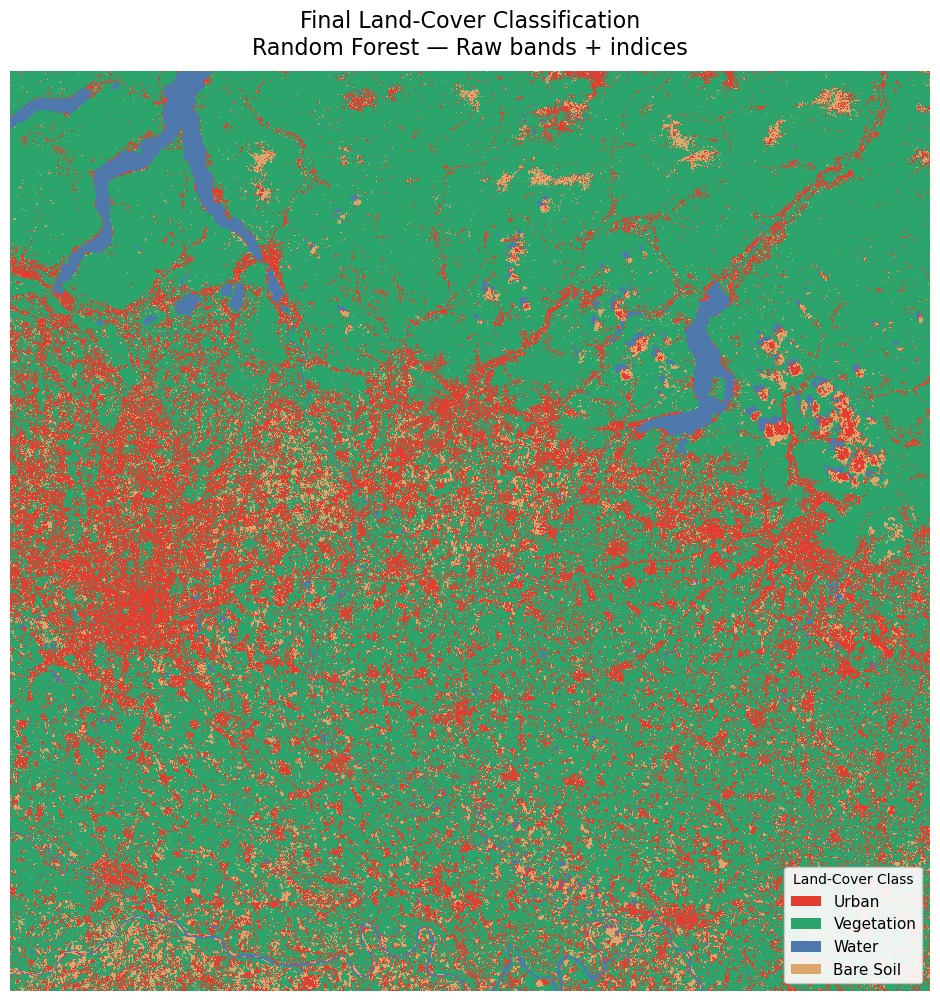


STEP 26 COMPLETED SUCCESSFULLY

Final map:
C:\Users\Hp\Desktop\submissiongeo_final\Results\landcover_map.png

Map source:
C:\Users\Hp\Desktop\submissiongeo_final\Results\landcover_classification_best_model.tif

Model used:
Random Forest

Feature set:
Raw bands + indices

Classified coverage: 100.00%
Raster geometry preserved : YES
Display stretching         : NO
Interpolation              : NEAREST
Output resolution          : 300 DPI


In [47]:
# ============================================================
# STEP 26 — FINAL LAND-COVER MAP
# DYNAMIC BEST-MODEL VERSION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import rasterio

from pathlib import Path
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


print("=" * 75)
print("STEP 26 — FINAL LAND-COVER MAP")
print("=" * 75)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "PROJECT_DIR",
    "CLASS_MAP",
    "SELECTED_MODEL",
    "SELECTED_FEATURE_SET",
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        +
        "\n".join(
            missing_variables
        )
        +
        "\n\nRun STEP 23 before STEP 26."
    )


# ============================================================
# 2. RESULTS DIRECTORY
# ============================================================

RESULTS_DIR = (
    Path(PROJECT_DIR)
    /
    "Results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FINAL_MAP_PATH = (
    RESULTS_DIR
    /
    "landcover_map.png"
)


# ============================================================
# 3. LOCATE FINAL BEST-MODEL CLASSIFICATION
#
# STEP 23 produces this generic output regardless of whether
# Random Forest or MLP wins.
# ============================================================

classification_path = (
    RESULTS_DIR
    /
    "landcover_classification_best_model.tif"
)


if not classification_path.exists():

    raise FileNotFoundError(
        "Final best-model classification was not found:\n"
        f"{classification_path}\n\n"
        "Run STEP 23 first."
    )


print(
    "\nClassification raster:"
)

print(
    classification_path
)


print(
    "\nSelected production model:"
)

print(
    f"Model       : {SELECTED_MODEL}"
)

print(
    f"Feature set : {SELECTED_FEATURE_SET}"
)


# ============================================================
# 4. READ CLASSIFICATION
# ============================================================

with rasterio.open(
    classification_path
) as src:

    classification = src.read(
        1
    )

    raster_crs = src.crs
    raster_resolution = src.res
    raster_nodata = src.nodata

    raster_width = src.width
    raster_height = src.height


print(
    "\nRaster information:"
)

print(
    f"Shape      : {classification.shape}"
)

print(
    f"CRS        : {raster_crs}"
)

print(
    f"Resolution : {raster_resolution}"
)

print(
    f"NoData     : {raster_nodata}"
)


# ============================================================
# 5. CLASS DEFINITIONS
# ============================================================

class_ids = sorted(
    CLASS_MAP.keys()
)


class_names = [
    CLASS_MAP[
        class_id
    ]
    for class_id
    in class_ids
]


# Fixed cartographic colours for the four classes

class_colors = [

    "#e43d30",   # Urban

    "#2ca56c",   # Vegetation

    "#4f79ad",   # Water

    "#dca66c",   # Bare Soil
]


if len(
    class_colors
) != len(
    class_ids
):

    raise RuntimeError(
        "The number of class colours does not match "
        "the number of land-cover classes."
    )


# ============================================================
# 6. VALIDATE CLASS VALUES
# ============================================================

unique_values, counts = np.unique(
    classification,
    return_counts=True
)


print(
    "\nRaster class values:"
)

print(
    "-" * 50
)


for value, count in zip(
    unique_values,
    counts
):

    value = int(
        value
    )

    count = int(
        count
    )


    if value == 0:

        class_name = (
            "NoData"
        )

    else:

        class_name = (
            CLASS_MAP.get(
                value,
                str(value)
            )
        )


    print(
        f"{value} - "
        f"{class_name:<10}: "
        f"{count:,} pixels"
    )


allowed_values = {
    0,
    *class_ids
}


invalid_values = (
    set(
        unique_values.tolist()
    )
    -
    allowed_values
)


if invalid_values:

    raise RuntimeError(
        "Invalid classification values detected:\n"
        +
        str(
            sorted(
                invalid_values
            )
        )
    )


print(
    "\nClass-value validation: PASSED"
)


# ============================================================
# 7. CLASSIFICATION COVERAGE
# ============================================================

valid_classified_mask = np.isin(
    classification,
    class_ids
)


classified_pixels = int(
    np.count_nonzero(
        valid_classified_mask
    )
)


total_pixels = int(
    classification.size
)


classified_percentage = (
    100
    *
    classified_pixels
    /
    total_pixels
)


print(
    "\nClassification coverage:"
)

print(
    "-" * 50
)

print(
    f"Total raster pixels : "
    f"{total_pixels:,}"
)

print(
    f"Classified pixels   : "
    f"{classified_pixels:,}"
)

print(
    f"Coverage            : "
    f"{classified_percentage:.2f}%"
)


# ============================================================
# 8. CREATE DISPLAY MAP
#
# Only genuine NoData pixels are masked.
# Land-cover values remain unchanged.
# ============================================================

display_map = np.ma.masked_where(
    classification == 0,
    classification
)


# ============================================================
# 9. CREATE DISCRETE CLASS COLORMAP
# ============================================================

class_cmap = ListedColormap(
    class_colors
)


class_cmap.set_bad(
    color="white"
)


# ============================================================
# 10. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        10,
        10
    )
)


# ============================================================
# 11. DISPLAY CLASSIFICATION
#
# Raster geometry is preserved.
# ============================================================

ax.imshow(

    display_map,

    cmap=class_cmap,

    vmin=min(
        class_ids
    ),

    vmax=max(
        class_ids
    ),

    interpolation="nearest",
)


# ============================================================
# 12. DYNAMIC TITLE
# ============================================================

ax.set_title(
    "Final Land-Cover Classification\n"
    f"{SELECTED_MODEL} — {SELECTED_FEATURE_SET}",
    fontsize=16,
    pad=12
)


# ============================================================
# 13. REMOVE AXES
# ============================================================

ax.axis(
    "off"
)


# ============================================================
# 14. LEGEND
# ============================================================

legend_elements = [

    Patch(
        facecolor=color,
        edgecolor="none",
        label=class_name
    )

    for color, class_name
    in zip(
        class_colors,
        class_names
    )
]


ax.legend(

    handles=legend_elements,

    loc="lower right",

    fontsize=11,

    frameon=True,

    framealpha=0.90,

    title="Land-Cover Class",
)


# ============================================================
# 15. FIGURE LAYOUT
# ============================================================

fig.subplots_adjust(
    left=0.01,
    right=0.99,
    bottom=0.01,
    top=0.93
)


# ============================================================
# 16. SAVE FINAL MAP
# ============================================================

fig.savefig(

    FINAL_MAP_PATH,

    dpi=300,

    facecolor="white",

    bbox_inches="tight",
)


plt.show()


plt.close(
    fig
)


# ============================================================
# 17. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "STEP 26 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 75
)


print(
    "\nFinal map:"
)

print(
    FINAL_MAP_PATH
)


print(
    "\nMap source:"
)

print(
    classification_path
)


print(
    "\nModel used:"
)

print(
    SELECTED_MODEL
)


print(
    "\nFeature set:"
)

print(
    SELECTED_FEATURE_SET
)


print(
    f"\nClassified coverage: "
    f"{classified_percentage:.2f}%"
)


print(
    "Raster geometry preserved : YES"
)

print(
    "Display stretching         : NO"
)

print(
    "Interpolation              : NEAREST"
)

print(
    "Output resolution          : 300 DPI"
)

print(
    "=" * 75
)

## Step 27 — Organize and Save All Results
Collect final outputs in the Results folder without failing when an optional output was not produced.


In [48]:
# ============================================================
# STEP 27 — ORGANIZE AND VERIFY ALL RESULTS
# ============================================================

from pathlib import Path
import shutil


print("=" * 75)
print("STEP 27 — ORGANIZE AND VERIFY ALL RESULTS")
print("=" * 75)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "PROJECT_DIR",
    "SELECTED_MODEL",
    "SELECTED_FEATURE_SET",
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n"
        +
        "\n".join(
            missing_variables
        )
        +
        "\n\nRun the complete workflow through STEP 26 first."
    )


# ============================================================
# 2. RESULTS DIRECTORY
# ============================================================

RESULTS_DIR = (
    Path(PROJECT_DIR)
    /
    "Results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\nResults directory:"
)

print(
    RESULTS_DIR
)


print(
    "\nFinal selected production model:"
)

print(
    f"Model       : {SELECTED_MODEL}"
)

print(
    f"Feature set : {SELECTED_FEATURE_SET}"
)


# ============================================================
# 3. EXPECTED FINAL OUTPUTS
# ============================================================

expected_outputs = [

    # --------------------------------------------------------
    # Training-data quality
    # --------------------------------------------------------

    "training_polygon_quality.csv",


    # --------------------------------------------------------
    # Cross-validation and model comparison
    # --------------------------------------------------------

    "cross_validation_results.csv",

    "final_model_comparison.csv",

    "feature_engineering_comparison.csv",

    "feature_engineering_summary.csv",


    # --------------------------------------------------------
    # Confusion matrices
    # --------------------------------------------------------

    "rf_confusion_matrix.png",

    "mlp_confusion_matrix.png",


    # --------------------------------------------------------
    # Model-comparison figures
    # --------------------------------------------------------

    "final_test_performance_rf_vs_mlp.png",

    "spectral_indices_f1_comparison.png",


    # --------------------------------------------------------
    # Final land-cover products
    # --------------------------------------------------------

    "landcover_classification_best_model.tif",

    "landcover_area_summary.csv",

    "landcover_map.png",

    "final_map_model_info.csv",
]


# ============================================================
# 4. TRACK FILE STATUS
# ============================================================

copied = []

already_present = []

missing = []


# ============================================================
# 5. ORGANIZE OUTPUT FILES
#
# Most final steps already save directly into Results.
# If an older step produced a file in PROJECT_DIR instead,
# it is copied into Results automatically.
# ============================================================

for file_name in expected_outputs:

    source = (
        Path(PROJECT_DIR)
        /
        file_name
    )

    destination = (
        RESULTS_DIR
        /
        file_name
    )


    if destination.exists():

        already_present.append(
            file_name
        )


    elif source.exists():

        shutil.copy2(
            source,
            destination
        )

        copied.append(
            file_name
        )


    else:

        missing.append(
            file_name
        )


# ============================================================
# 6. REPORT COPIED FILES
# ============================================================

print(
    f"\nCopied into Results: "
    f"{len(copied)}"
)


if copied:

    for name in copied:

        print(
            f"  + {name}"
        )

else:

    print(
        "  None — no files required relocation."
    )


# ============================================================
# 7. REPORT FILES ALREADY PRESENT
# ============================================================

print(
    f"\nAlready in Results: "
    f"{len(already_present)}"
)


if already_present:

    for name in already_present:

        print(
            f"  = {name}"
        )

else:

    print(
        "  None"
    )


# ============================================================
# 8. REPORT MISSING OUTPUTS
# ============================================================

print(
    f"\nNot produced in this run: "
    f"{len(missing)}"
)


if missing:

    for name in missing:

        print(
            f"  - {name}"
        )

else:

    print(
        "  None"
    )


# ============================================================
# 9. FINAL RESULTS INVENTORY
# ============================================================

final_files = sorted(
    [
        path
        for path
        in RESULTS_DIR.iterdir()
        if path.is_file()
    ]
)


print(
    "\n" + "=" * 75
)

print(
    "FINAL RESULTS INVENTORY"
)

print(
    "=" * 75
)


if final_files:

    for path in final_files:

        file_size_mb = (
            path.stat().st_size
            /
            (
                1024
                *
                1024
            )
        )


        print(
            f"{path.name:<50} "
            f"{file_size_mb:>8.2f} MB"
        )

else:

    print(
        "No files found in Results."
    )


# ============================================================
# 10. ESSENTIAL DELIVERABLE CHECK
# ============================================================

essential_outputs = [

    "cross_validation_results.csv",

    "final_model_comparison.csv",

    "rf_confusion_matrix.png",

    "mlp_confusion_matrix.png",

    "landcover_classification_best_model.tif",

    "landcover_area_summary.csv",

    "landcover_map.png",

    "final_map_model_info.csv",
]


missing_essential = [

    file_name

    for file_name
    in essential_outputs

    if not (
        RESULTS_DIR
        /
        file_name
    ).exists()
]


print(
    "\n" + "=" * 75
)

print(
    "ESSENTIAL DELIVERABLE CHECK"
)

print(
    "=" * 75
)


if not missing_essential:

    print(
        "\nAll essential final outputs are available."
    )


else:

    print(
        "\nWARNING: The following essential "
        "outputs are missing:"
    )


    for name in missing_essential:

        print(
            f"  - {name}"
        )


# ============================================================
# 11. FINAL MODEL CONSISTENCY CHECK
#
# Verify that the metadata generated in STEP 23 exists.
# This confirms that the final map can be traced back to
# the model selected during the held-out evaluation.
# ============================================================

model_info_path = (
    RESULTS_DIR
    /
    "final_map_model_info.csv"
)


if model_info_path.exists():

    print(
        "\nFinal map model metadata: AVAILABLE"
    )

    print(
        model_info_path
    )

else:

    print(
        "\nWARNING: Final map model metadata "
        "was not found."
    )


# ============================================================
# 12. FINAL PIPELINE SUMMARY
# ============================================================

print(
    "\nFinal pipeline summary:"
)

print(
    f"- Winning classifier : {SELECTED_MODEL}"
)

print(
    f"- Winning feature set: {SELECTED_FEATURE_SET}"
)

print(
    "- Final map file     : "
    "landcover_classification_best_model.tif"
)

print(
    "- Final figure       : landcover_map.png"
)

print(
    "- Area summary       : landcover_area_summary.csv"
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "STEP 27 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 75
)


print(
    "\nFinal results package:"
)

print(
    RESULTS_DIR
)


if not missing_essential:

    print(
        "\nFinal results package status: COMPLETE"
    )

else:

    print(
        "\nFinal results package status: INCOMPLETE"
    )


print(
    "=" * 75
)


STEP 27 — ORGANIZE AND VERIFY ALL RESULTS

Results directory:
C:\Users\Hp\Desktop\submissiongeo_final\Results

Final selected production model:
Model       : Random Forest
Feature set : Raw bands + indices

Copied into Results: 0
  None — no files required relocation.

Already in Results: 12
  = cross_validation_results.csv
  = final_model_comparison.csv
  = feature_engineering_comparison.csv
  = feature_engineering_summary.csv
  = rf_confusion_matrix.png
  = mlp_confusion_matrix.png
  = final_test_performance_rf_vs_mlp.png
  = spectral_indices_f1_comparison.png
  = landcover_classification_best_model.tif
  = landcover_area_summary.csv
  = landcover_map.png
  = final_map_model_info.csv

Not produced in this run: 1
  - training_polygon_quality.csv

FINAL RESULTS INVENTORY
cross_validation_results.csv                           0.00 MB
feature_engineering_comparison.csv                     0.00 MB
feature_engineering_summary.csv                        0.00 MB
final_map_model_info.csv     